
# TSLA Liquidity Zone Analysis

This notebook performs a **liquidity zone analysis** on TSLA across two timeframes:

| Timeframe | Interval | Source | Date Range |
|---|---|---|---|
| HTF (High Timeframe) | Daily OHLCV (30-trading day rolling window)| Yahoo Finance (yfinance) | 2021-01-04 → 2024-09-30 |
| LTF (Low Timeframe) | Hourly OHLCV (5-trading day rolling window)| Twelve Data | 2021-01-04 → 2024-09-30 |

> **Note:** Yahoo Finance only retains ~730 days of hourly data, so the LTF series is loaded from a local file. Daily data covers the full requested range.


## Part 1 — Setup & Data Loading

Configure the ticker and date range, download **daily** OHLCV data from Yahoo Finance, and read **hourly** data from the local CSV. Both datasets are saved to `data/raw/` with date-stamped filenames, then reloaded and verified.

Volume feature config constants (`VOL_ROLL_WINDOW`, `VOL_SPIKE_THRESHOLD`, `USE_VOL_FILTER`) and the `USE_MIDAS` flag are declared here so they are available to all subsequent parts.

The final cell of Part 1 loads the **MIDAS order-level dataset** (`data/MIDAS data (TSLA).xlsx`), providing institutional microstructure metrics that will be attached to zone tables for analysis.


In [246]:
# ---------------------------------------------------------------------------
# Imports & parameters
# ---------------------------------------------------------------------------
import yfinance as yf
import pandas as pd
from datetime import date, timedelta
from pathlib import Path
from dataclasses import dataclass
from typing import List, Optional, Tuple, Dict
import os
import numpy as np

TICKER     = "TSLA"
START_DATE = date(2021, 1, 4)
END_DATE   = date(2024, 9, 30)

# Output directory (created automatically if missing)
OUT_DIR = Path("data/raw")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Ticker     : {TICKER}")
print(f"Start date : {START_DATE}")
print(f"End date   : {END_DATE}")
print(f"Output dir : {OUT_DIR.resolve()}")

Ticker     : TSLA
Start date : 2021-01-04
End date   : 2024-09-30
Output dir : /Users/kamanlee_1/Desktop/RMSC6007_Liquidity-Zones/data/raw


In [247]:
# ===========================================================================
# Zone Data Structure (Mutable Class)
# ===========================================================================

class Zone:
    """
    Mutable zone object storing liquidity level state and lifecycle metrics.
    Uses __slots__ for memory efficiency and performance.
    Includes decay factor for automatic zone expiration after HTF_LOOKBACK_DAYS.
    """
    __slots__ = [
        'top', 'bottom', 'height', 'touches',
        'first_idx', 'last_idx', 
        'first_time', 'last_time',
        'total_volume', 'avg_volume', 'avg_absorption',
        'zone_type', 
        'pattern_strength', 'volume_confirmation', 'institutional_score', 'composite_score',
        'is_double_top', 'is_double_bottom',
        'formation_volume_ratio',
        'zone_id', 'origin_vol', 'market_vol_baseline', 'state',
        'volume_node_score', 'strength', 'any_double', 'zone_side',
        'zone_age_bars', 'zone_lifecycle_phase', 'decay_factor', 'is_expired'
    ]
    
    def __init__(self, top, bottom, touches, first_idx, last_idx, first_time, last_time,
                 total_volume, avg_volume, zone_type, pattern_strength=0.0,
                 volume_confirmation=0.0, institutional_score=0.0, composite_score=0.0,
                 is_double_top=False, is_double_bottom=False, formation_volume_ratio=None,
                 zone_id=None, origin_vol=0.0, market_vol_baseline=0.0, state='active',
                 decay_factor=1.0, is_expired=False):
        """Initialize Zone with all attributes, including decay factor for time-based expiration."""
        self.top = top
        self.bottom = bottom
        self.height = abs(top - bottom)  # Price range of zone
        self.touches = touches
        self.first_idx = first_idx
        self.last_idx = last_idx
        self.first_time = first_time
        self.last_time = last_time
        self.total_volume = total_volume
        self.avg_volume = avg_volume
        self.zone_type = zone_type
        self.pattern_strength = pattern_strength
        self.volume_confirmation = volume_confirmation
        self.institutional_score = institutional_score
        self.composite_score = composite_score
        self.is_double_top = is_double_top
        self.is_double_bottom = is_double_bottom
        self.formation_volume_ratio = formation_volume_ratio
        self.zone_id = zone_id
        self.origin_vol = origin_vol
        self.market_vol_baseline = market_vol_baseline
        self.state = state
        
        # Dynamic attributes (set later during processing)
        self.avg_absorption = 0.0
        self.volume_node_score = 0.0
        self.strength = 0.0
        self.any_double = False
        self.zone_side = 'neutral'
        self.zone_age_bars = 0
        self.zone_lifecycle_phase = 'established'
        self.decay_factor = decay_factor  # Time-based decay: 1.0 (fresh) -> 0.0 (expired)
        self.is_expired = is_expired      # True if zone age > HTF_LOOKBACK_DAYS
    
    def calculate_decay(self, current_time, lookback_days=30):
        """Calculate decay factor based on zone age. Returns 1.0 (fresh) to 0.0 (expired)."""
        days_old = (current_time - self.first_time).days
        if days_old >= lookback_days:
            self.is_expired = True
            self.decay_factor = 0.0
        elif days_old > 0:
            # Linear decay: 1.0 at day 0, 0.0 at day lookback_days
            self.decay_factor = max(0.0, 1.0 - (days_old / lookback_days))
        else:
            self.decay_factor = 1.0
        return self.decay_factor
    
    def to_dict(self):
        """Convert Zone to dictionary for DataFrame storage."""
        return {slot: getattr(self, slot) for slot in self.__slots__}
    
    def __repr__(self):
        return f"Zone(top={self.top}, bottom={self.bottom}, height={self.height}, touches={self.touches}, zone_id={self.zone_id})"


In [248]:

# ---------------------------------------------------------------------------
# Volume feature config
# ---------------------------------------------------------------------------
VOL_ROLL_WINDOW     = 30    # rolling window for average volume; smooths single-bar noise to give a reliable activity baseline
VOL_SPIKE_THRESHOLD = 1.5   # vol_ratio >= threshold marks a spike; bars above this likely reflect institutional participation
USE_VOL_FILTER      = True  # when True, only sweeps with elevated volume are flagged, filtering low-conviction breakouts
VOL_PROFILE_BIN_DAILY  = 1.0   # $1 USD bin width for daily POC — coarser bin fits the multi-year price range
VOL_PROFILE_BIN_HOURLY = 0.5   # $0.50 USD bin width for hourly POC — finer bin for intraday price levels

# ---------------------------------------------------------------------------
# MIDAS order-level data config
# ---------------------------------------------------------------------------
USE_MIDAS = True  # when True, enrich zones and sweeps with MIDAS institutional microstructure features;
                  # enables side-by-side comparison of analysis with and without order-level data

# ---------------------------------------------------------------------------
# Multi-day liquidity sweep detection config
# ---------------------------------------------------------------------------
# HTF (High Timeframe): Daily data — structural liquidity zone identification (20-day rolling lookback)
# LTF (Low Timeframe): Hourly data — sweep detection on multi-day zones (30-hour rolling window)
#
# Layer 1: Price-based patterns detection      
# Layer 2: Volume-related features   
# Layer 3: Microstructure metrics from MIDAS

MIN_ABSORPTION_SCORE = 0.0   # Layer 2: minimum absorption_score for HTF (daily) zone pivots;
                              # set to 0.0 to disable absorption filter for structural zones

# HTF (Daily) — Liquidity Zone Identification (structural context)
# Detects 30+ day liquidity levels that persist across multiple trading sessions
HTF_ABSORPTION_SCORE = 0.0    # No absorption filter for daily zones (structural context)
HTF_PIVOT_WINDOW = 3          # 3 bars each side for daily pivot detection
HTF_VOL_MULT = 1.0            # Standard volume multiplier for daily zones
HTF_MIN_TOUCHES = 1           # Minimum touches for zone confirmation on daily
HTF_LOOKBACK_DAYS = 20        # 20-day rolling lookback for zone identification (multi-day structure)

# LTF (Hourly) — Multi-day Sweep Detection
# Detects sweeps on hourly data against daily liquidity zones (35-hour rolling window)
# Rationale: 35 hours ≈ 5 trading days; multi-day institutional sweep mechanics typically resolve within 1-5 days
LTF_ABSORPTION_SCORE = 0.3    # Absorption score threshold for hourly sweeps
LTF_PIVOT_WINDOW = 5          # 5 bars each side for hourly pivot detection
LTF_VOL_MULT = 1.2            # Volume multiplier for hourly sweeps
LTF_MIN_TOUCHES = 2           # Minimum touches for hourly zone confirmation
LTF_LOOKBACK_DAYS = 5         # 5-day rolling window for multi-day sweep detection

# Volume analysis config for sweep detection
VOL_ZSCORE_WINDOW = 30        # 30-hour window for volume z-score baseline (institutional spike detection)
VOL_PROFILE_BIN_LTF = 0.5     # $0.50 USD bin width for hourly POC — finer bin for intraday price levels
RSI_PERIOD = 30               # RSI(30) over 30-hour window for momentum confirmation
MOMENTUM_PERIOD = 30          # Rate of change window (hours)

MIDAS_CONFIRM_FIELD  = "hidden_rate_avg"  # Layer 3: MIDAS zone column used for institutional enrichment filtering;
                                          # options: "hidden_rate_avg"      (dark-pool execution fraction)
                                          #          "cancel_to_trade_avg"  (algo probing / spoofing intensity)
                                          #          "fill_rate_avg"        (inverse: low fill = iceberg/spoof)

MIDAS_CONFIRM_PCT    = 50    # Layer 3: percentile threshold for the MIDAS institutional filter (0–100):
                              #   50 = keep zones above median institutional activity (moderate filter)
                              #   75 = keep only top quartile (strict — fewer, higher-conviction zones)


print(f"Vol window : {VOL_ROLL_WINDOW}  |  Spike threshold : {VOL_SPIKE_THRESHOLD}  |  Vol filter : {USE_VOL_FILTER}")
print(f"POC bins   : daily=${VOL_PROFILE_BIN_DAILY}  |  hourly=${VOL_PROFILE_BIN_HOURLY}")
print(f"MIDAS data : {'enabled' if USE_MIDAS else 'disabled'}")
print(f"\nHTF (Daily) config  : pivot_window={HTF_PIVOT_WINDOW}  |  absorption={HTF_ABSORPTION_SCORE}  |  lookback={HTF_LOOKBACK_DAYS} days")
print(f"LTF (Hourly) config : pivot_window={LTF_PIVOT_WINDOW}  |  absorption={LTF_ABSORPTION_SCORE}  |  lookback={LTF_LOOKBACK_DAYS} days")
print(f"MIDAS filter: {MIDAS_CONFIRM_FIELD} at {MIDAS_CONFIRM_PCT}th percentile")

Vol window : 30  |  Spike threshold : 1.5  |  Vol filter : True
POC bins   : daily=$1.0  |  hourly=$0.5
MIDAS data : enabled

HTF (Daily) config  : pivot_window=3  |  absorption=0.0  |  lookback=20 days
LTF (Hourly) config : pivot_window=5  |  absorption=0.3  |  lookback=5 days
MIDAS filter: hidden_rate_avg at 50th percentile


In [249]:
# ---------------------------------------------------------------------------
# Download daily data (HTF)
# ---------------------------------------------------------------------------
print("Downloading daily (HTF) data...")

df_daily = yf.download(
    tickers=TICKER,
    start=START_DATE.isoformat(),
    end=(END_DATE + timedelta(days=1)).isoformat(),
    interval="1d",
    auto_adjust=True,
    progress=False,
    multi_level_index=False,
)

df_daily.index.name = "Datetime"
print(f"Daily rows : {len(df_daily)}")
print(f"Date range : {df_daily.index[0].date()} -> {df_daily.index[-1].date()}")
df_daily.tail(3)


Daily rows : 941
Date range : 2021-01-04 -> 2024-09-30


,Close,High,Low,Open,Volume
Datetime,,,,,
2024-09-26,254.220001,261.750000,251.529999,260.600006,67142200
2024-09-27,260.459991,260.700012,254.119995,257.380005,70988100
2024-09-30,261.630005,264.859985,255.770004,259.040009,80705700


In [250]:
# ---------------------------------------------------------------------------
# Read hourly data (LTF) from local CSV
# ---------------------------------------------------------------------------
CSV_PATH = Path("data/TSLA_hourly_2021-01-04_2024-09-30_with_vol.csv")

print(f"Reading hourly (LTF) data from {CSV_PATH.resolve()} ...")

df_hourly = pd.read_csv(CSV_PATH, index_col=0, parse_dates=False)
df_hourly.index = pd.to_datetime(df_hourly.index, format='mixed', dayfirst=True)
df_hourly.index.name = "Datetime"
df_hourly.sort_index(inplace=True)

# Filter to the same date range as df_daily
df_hourly = df_hourly.loc[START_DATE.isoformat() : END_DATE.isoformat()]

if df_hourly.empty:
    raise RuntimeError(f"df_hourly is empty. Check that {CSV_PATH} exists and covers {START_DATE} – {END_DATE}.")

print(f"\nHourly rows : {len(df_hourly)}")
print(f"Date range  : {df_hourly.index.min()} -> {df_hourly.index.max()}")
df_hourly.head(5)


Reading hourly (LTF) data from /Users/kamanlee_1/Desktop/RMSC6007_Liquidity-Zones/data/TSLA_hourly_2021-01-04_2024-09-30_with_vol.csv ...

Hourly rows : 6577
Date range  : 2021-01-04 09:30:00 -> 2024-09-30 15:30:00


,Open,High,Low,Close,% Change,Volume
Datetime,,,,,,
2021-01-04 09:30:00,239.68,247.91,239.06,246.72,2.94%,48538308
2021-01-04 10:30:00,246.67,248.16,242.75,245.21,-0.59%,25522500
2021-01-04 11:30:00,245.11,245.25,239.35,241.28,-1.56%,21004254
2021-01-04 12:30:00,241.25,244.00,239.97,243.73,1.03%,13451874
2021-01-04 13:30:00,243.70,245.50,242.09,242.49,-0.50%,11721450


In [251]:
# ---------------------------------------------------------------------------
# Save to CSV
# ---------------------------------------------------------------------------
# Use actual date ranges from the downloaded data (especially important for hourly)
daily_start  = df_daily.index.min().date()
daily_end    = df_daily.index.max().date()
hourly_start = df_hourly.index.min().date()
hourly_end   = df_hourly.index.max().date()

daily_path  = OUT_DIR / f"{TICKER}_daily_{daily_start}_{daily_end}.csv"
hourly_path = OUT_DIR / f"{TICKER}_hourly_{hourly_start}_{hourly_end}.csv"

df_daily.to_csv(daily_path)
df_hourly.to_csv(hourly_path)

print(f"Saved daily  -> {daily_path}")
print(f"Saved hourly -> {hourly_path}")


Saved daily  -> data/raw/TSLA_daily_2021-01-04_2024-09-30.csv
Saved hourly -> data/raw/TSLA_hourly_2021-01-04_2024-09-30.csv


In [252]:
# ---------------------------------------------------------------------------
# Sanity check — reload and display shapes
# ---------------------------------------------------------------------------
reload_daily  = pd.read_csv(daily_path,  index_col="Datetime", parse_dates=True)
reload_hourly = pd.read_csv(hourly_path, index_col="Datetime", parse_dates=True)

print("=" * 45)
print(f"Daily  CSV shape  : {reload_daily.shape}")
print(f"Hourly CSV shape  : {reload_hourly.shape}")
print("=" * 45)
print("Daily columns : ",  reload_daily.columns.tolist())
print("Hourly columns: ",  reload_hourly.columns.tolist())
print("Daily head:")
print(reload_daily.head(3))
print("Hourly head:")
print(reload_hourly.head(3))


Daily  CSV shape  : (941, 5)
Hourly CSV shape  : (6577, 6)
Daily columns :  ['Close', 'High', 'Low', 'Open', 'Volume']
Hourly columns:  ['Open', 'High', 'Low', 'Close', '% Change', 'Volume']
Daily head:
                 Close        High         Low        Open     Volume
Datetime                                                             
2021-01-04  243.256668  248.163330  239.063339  239.820007  145914600
2021-01-05  245.036667  246.946671  239.733337  241.220001   96735600
2021-01-06  251.993332  258.000000  249.699997  252.830002  134100000
Hourly head:
                       Open    High     Low   Close % Change    Volume
Datetime                                                              
2021-01-04 09:30:00  239.68  247.91  239.06  246.72    2.94%  48538308
2021-01-04 10:30:00  246.67  248.16  242.75  245.21   -0.59%  25522500
2021-01-04 11:30:00  245.11  245.25  239.35  241.28   -1.56%  21004254


In [253]:

# ---------------------------------------------------------------------------
# Load MIDAS Order-Level Data
# ---------------------------------------------------------------------------
# MIDAS provides daily institutional microstructure metrics
# Highest signal for liquidity zone and sweep quality:
#     Cancel_to_Trade      : cancel-to-trade ratio — spikes signal algo probing / spoofing near a price level
#     Hidden_Rate          : dark-pool execution rate (trade count); indicates stealth institutional positioning
#     Hidden_Volume        : dark-pool volume fraction; volume-weighted complement to Hidden_Rate
#     Trade_to_Order_Volume: order fill rate proxy — persistently low values near zones suggest iceberg / spoof orders
#   Supplementary retail-vs-institutional split:
#     Oddlot_Rate          : odd-lot trade rate — high = retail fragmentation (institutions likely on the other side)
#     Oddlot_Volume        : odd-lot volume fraction

MIDAS_PATH  = Path("data/MIDAS data (TSLA).xlsx")
MIDAS_SHEET = "geoo0rz0bbjsayud"
MIDAS_COLS  = [
    "Cancel_to_Trade", "Hidden_Rate", "Hidden_Volume",
    "Trade_to_Order_Volume", "Oddlot_Rate", "Oddlot_Volume",
]

midas_df = None  # Initialize to None (will be populated only if USE_MIDAS is True and file loads successfully)

if USE_MIDAS:
    try:
        # Try to load MIDAS data
        midas_df = pd.read_excel(MIDAS_PATH, sheet_name=MIDAS_SHEET, parse_dates=["date"])
        midas_df["date"] = pd.to_datetime(midas_df["date"])
        midas_df = midas_df.set_index("date")[MIDAS_COLS].sort_index()
        midas_df.index = midas_df.index.normalize()   # strip any time-of-day component
        
        print(f"✓ MIDAS data loaded successfully")
        print(f"  Rows       : {len(midas_df)}")
        print(f"  Date range : {midas_df.index.min().date()} -> {midas_df.index.max().date()}")
        print(f"  Columns    : {midas_df.columns.tolist()}")
        print(midas_df.describe().round(3))
        
    except FileNotFoundError as e:
        print(f"⚠ WARNING: MIDAS file not found: {MIDAS_PATH}")
        print(f"  Error: {e}")
        print(f"  Falling back to non-MIDAS analysis (zones and sweeps will be detected without institutional microstructure)")
        midas_df = None
        USE_MIDAS = False
        
    except KeyError as e:
        print(f"⚠ WARNING: MIDAS sheet '{MIDAS_SHEET}' or columns not found")
        print(f"  Error: {e}")
        print(f"  Falling back to non-MIDAS analysis")
        midas_df = None
        USE_MIDAS = False
        
    except Exception as e:
        print(f"⚠ WARNING: Unexpected error loading MIDAS data: {type(e).__name__}: {e}")
        print(f"  Falling back to non-MIDAS analysis")
        midas_df = None
        USE_MIDAS = False
else:
    print("USE_MIDAS = False — MIDAS data not loaded.")


✓ MIDAS data loaded successfully
  Rows       : 941
  Date range : 2021-01-04 -> 2024-09-30
  Columns    : ['Cancel_to_Trade', 'Hidden_Rate', 'Hidden_Volume', 'Trade_to_Order_Volume', 'Oddlot_Rate', 'Oddlot_Volume']
       Cancel_to_Trade  Hidden_Rate  Hidden_Volume  Trade_to_Order_Volume  \
count          941.000      941.000        941.000                941.000   
mean            18.853       30.190         25.196                  3.608   
std              6.782        8.664          6.648                  1.441   
min              5.700       12.183         10.479                  1.115   
25%             13.630       21.986         19.441                  2.498   
50%             18.270       31.953         25.270                  3.318   
75%             22.839       38.154         30.926                  4.519   
max             46.722       45.673         44.220                 10.498   

       Oddlot_Rate  Oddlot_Volume  
count      941.000        941.000  
mean        82.085

## Part 2 — Data Processing & Exploratory Data Analysis (EDA)

Before proceeding with zone identification, we perform sanity checks and visual EDA to understand:
- **Data integrity:** missing values, duplicates, data types, volume filling strategies
- **Time series structure:** continuity, gaps, frequency of data points
- **Distribution characteristics:** price ranges, volume patterns, volatility trends
- **Seasonal patterns:** decomposition of price and volume time series
- **Baseline statistics:** mean, median, volatility across both timeframes


In [254]:
# ---------------------------------------------------------------------------
# Sanity Check: Missing Values, Duplicates, Data Types
# ---------------------------------------------------------------------------
print("="*70)
print("SANITY CHECK — DAILY (HTF) DATA")
print("="*70)

# Basic info
print(f"Shape: {reload_daily.shape}")
print(f"Date range: {reload_daily.index.min()} to {reload_daily.index.max()}")
print(f"Frequency: {(reload_daily.index[1] - reload_daily.index[0]).days} day(s)")

# Missing values
print(f"\nMissing values (counts):")
missing_daily = reload_daily.isnull().sum()
print(missing_daily[missing_daily > 0] if missing_daily.sum() > 0 else "  None")

# Duplicates (by index)
dup_daily = reload_daily.index.duplicated().sum()
print(f"Duplicate timestamps: {dup_daily}")

# Data types
print(f"\nData types:")
print(reload_daily.dtypes)

# Numeric summary
print(f"\nNumeric summary:")
print(reload_daily.describe().round(2))

print("\n" + "="*70)
print("SANITY CHECK — HOURLY (LTF) DATA")
print("="*70)

# Basic info
print(f"Shape: {reload_hourly.shape}")
print(f"Date range: {reload_hourly.index.min()} to {reload_hourly.index.max()}")
print(f"Frequency (approx): {(reload_hourly.index[1] - reload_hourly.index[0]).total_seconds() / 3600:.1f} hour(s)")

# Missing values
print(f"\nMissing values (counts):")
missing_hourly = reload_hourly.isnull().sum()
print(missing_hourly[missing_hourly > 0] if missing_hourly.sum() > 0 else "  None")

# Duplicates (by index)
dup_hourly = reload_hourly.index.duplicated().sum()
print(f"Duplicate timestamps: {dup_hourly}")

# Data types
reload_hourly['Volume'] = reload_hourly['Volume'].astype(float)
print(f"\nData types:")
print(reload_hourly.dtypes)

# Numeric summary
print(f"\nNumeric summary:")
print(reload_hourly.describe().round(2))

# Check for negative or zero volumes
print(f"\n---")
print(f"Daily rows with zero/negative volume: {(reload_daily['Volume'] <= 0).sum()}")
print(f"Hourly rows with zero/negative volume: {(reload_hourly['Volume'] <= 0).sum()}")

# Alignment check
print(f"\nAlignment check:")
daily_trading_days = set(reload_daily.index.date)
hourly_trading_days = set(reload_hourly.index.date)
missing_in_hourly = daily_trading_days - hourly_trading_days
print(f"  Daily dates not in hourly: {len(missing_in_hourly)} day(s)")
if missing_in_hourly and len(missing_in_hourly) <= 5:
    print(f"    {sorted(missing_in_hourly)}")


SANITY CHECK — DAILY (HTF) DATA
Shape: (941, 5)
Date range: 2021-01-04 00:00:00 to 2024-09-30 00:00:00
Frequency: 1 day(s)

Missing values (counts):
  None
Duplicate timestamps: 0

Data types:
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

Numeric summary:
        Close    High     Low    Open        Volume
count  941.00  941.00  941.00  941.00  9.410000e+02
mean   237.46  242.79  232.06  237.60  1.008086e+08
std     54.69   56.12   53.31   54.89  4.023200e+07
min    108.10  111.75  101.81  103.00  2.940180e+07
25%    197.41  201.78  192.20  197.32  7.114590e+07
50%    233.94  238.47  228.18  233.87  9.391650e+07
75%    266.68  273.17  261.20  267.48  1.208318e+08
max    409.97  414.50  405.67  411.47  3.065906e+08

SANITY CHECK — HOURLY (LTF) DATA
Shape: (6577, 6)
Date range: 2021-01-04 09:30:00 to 2024-09-30 15:30:00
Frequency (approx): 1.0 hour(s)

Missing values (counts):
  None
Duplicate timestamps: 0

Data types:
Open     

In [255]:
# ---------------------------------------------------------------------------
# Check and Fill Missing/Zero Hourly Volume
# ---------------------------------------------------------------------------
print("\n" + "="*70)
print("VOLUME SANITY CHECK — MISSING AND ZERO VALUES")
print("="*70)

# Check daily volume
print(f"\nDaily volume:")
print(f"  Missing values: {reload_daily['Volume'].isna().sum()}")
print(f"  Zero values: {(reload_daily['Volume'] == 0).sum()}")
print(f"  Total valid: {(reload_daily['Volume'] > 0).sum()}")

# Check hourly volume
print(f"\nHourly volume:")
print(f"  Missing values: {reload_hourly['Volume'].isna().sum()}")
print(f"  Zero values: {(reload_hourly['Volume'] == 0).sum()}")
print(f"  Total valid: {(reload_hourly['Volume'] > 0).sum()}")

# Identify zero-volume hours
missing_zero_mask = (reload_hourly['Volume'].isna()) | (reload_hourly['Volume'] == 0)
if missing_zero_mask.sum() > 0:
    print(f"\n→ Found {missing_zero_mask.sum()} bars with missing or zero hourly volume")
    print("  Analyzing mixed-volume days...\n")
    
    # Add date column for grouping
    reload_hourly['date'] = reload_hourly.index.normalize()
    
    fill_count = 0
    fill_sources = {'same_day_avg': 0, 'daily_divided': 0, 'global_avg': 0}
    
    # Process each date
    for date_val in reload_hourly['date'].unique():
        day_mask = reload_hourly['date'] == date_val
        day_data = reload_hourly.loc[day_mask].copy()
        
        # Find valid vs zero hours on this day
        valid_hours = day_data[day_data['Volume'] > 0]
        zero_hours = day_data[day_data['Volume'] == 0]
        
        if len(zero_hours) == 0:
            continue  # no zero values on this day
        
        if len(valid_hours) > 0:
            # Strategy 1: Use average of valid hours on the same day
            avg_vol_same_day = valid_hours['Volume'].mean()
            for ts in zero_hours.index:
                reload_hourly.at[ts, 'Volume'] = avg_vol_same_day
                fill_count += 1
                fill_sources['same_day_avg'] += 1
        else:
            # Strategy 2: All hours are zero on this day, use daily volume
            if date_val in reload_daily.index.normalize():
                daily_idx = reload_daily.index[reload_daily.index.normalize() == date_val]
                if len(daily_idx) > 0:
                    daily_vol = reload_daily.loc[daily_idx[0], 'Volume']
                    # Estimate hours with trading activity
                    # Use 6.5 as typical, but adjust based on market conditions
                    hourly_fill_vol = daily_vol / 6.5
                    for ts in zero_hours.index:
                        reload_hourly.at[ts, 'Volume'] = hourly_fill_vol
                        fill_count += 1
                        fill_sources['daily_divided'] += 1
                else:
                    # Fallback to global hourly average
                    global_avg = reload_hourly.loc[reload_hourly['Volume'] > 0, 'Volume'].mean()
                    for ts in zero_hours.index:
                        reload_hourly.at[ts, 'Volume'] = global_avg
                        fill_count += 1
                        fill_sources['global_avg'] += 1
            else:
                # Fallback to global hourly average
                global_avg = reload_hourly.loc[reload_hourly['Volume'] > 0, 'Volume'].mean()
                for ts in zero_hours.index:
                    reload_hourly.at[ts, 'Volume'] = global_avg
                    fill_count += 1
                    fill_sources['global_avg'] += 1
    
    print(f"✓ Filled {fill_count} bars")
    print(f"  - {fill_sources['same_day_avg']} from same-day average of valid hours")
    print(f"  - {fill_sources['daily_divided']} from daily volume ÷ 6.5 hours")
    print(f"  - {fill_sources['global_avg']} from global hourly average")
    print(f"  New hourly volume range: {reload_hourly['Volume'].min():.0f} - {reload_hourly['Volume'].max():.0f}")
    
    # Remove helper column
    reload_hourly = reload_hourly.drop('date', axis=1)
else:
    print(f"\n✓ No missing or zero values found in hourly volume")



VOLUME SANITY CHECK — MISSING AND ZERO VALUES

Daily volume:
  Missing values: 0
  Zero values: 0
  Total valid: 941

Hourly volume:
  Missing values: 0
  Zero values: 264
  Total valid: 6313

→ Found 264 bars with missing or zero hourly volume
  Analyzing mixed-volume days...

✓ Filled 264 bars
  - 138 from same-day average of valid hours
  - 126 from daily volume ÷ 6.5 hours
  - 0 from global hourly average
  New hourly volume range: 17826 - 137473011


In [256]:
# Verification: compare daily vs hourly volume totals
print("\n" + "="*70)
print("VERIFICATION: Daily vs Hourly Volume After Filling")
print("="*70)

# Calculate total volume per day for both timeframes
daily_totals = reload_daily.groupby(reload_daily.index.normalize())['Volume'].sum()
hourly_totals = reload_hourly.groupby(reload_hourly.index.normalize())['Volume'].sum()

# Align indices
common_dates = daily_totals.index.intersection(hourly_totals.index)

# Compare totals
comparison = pd.DataFrame({
    'Daily_Volume': daily_totals.loc[common_dates],
    'Hourly_Volume': hourly_totals.loc[common_dates],
}, index=common_dates)

comparison['Ratio (Hourly/Daily)'] = comparison['Hourly_Volume'] / comparison['Daily_Volume'].replace(0, np.nan)

print(f"\nComparison statistics (first 10 days):")
print(comparison.head(10).round(0))

print(f"\nAverage Hourly/Daily ratio: {comparison['Ratio (Hourly/Daily)'].mean():.4f}")
print(f"  (should be close to 1.0 if filling is accurate)")

print(f"\n✓ Hourly volume filling complete!")



VERIFICATION: Daily vs Hourly Volume After Filling

Comparison statistics (first 10 days):
            Daily_Volume  Hourly_Volume  Ratio (Hourly/Daily)
Datetime                                                     
2021-01-04     145914600    138854073.0                   1.0
2021-01-05      96735600     87119124.0                   1.0
2021-01-06     134100000    129531942.0                   1.0
2021-01-07     154496700    145369788.0                   1.0
2021-01-08     225166500    219834303.0                   1.0
2021-01-11     177904800    172612128.0                   1.0
2021-01-12     138812100    132122601.0                   1.0
2021-01-13      99937500     94706133.0                   1.0
2021-01-14      93798900     91119210.0                   1.0
2021-01-15     116332800    111465387.0                   1.0

Average Hourly/Daily ratio: 0.9343
  (should be close to 1.0 if filling is accurate)

✓ Hourly volume filling complete!


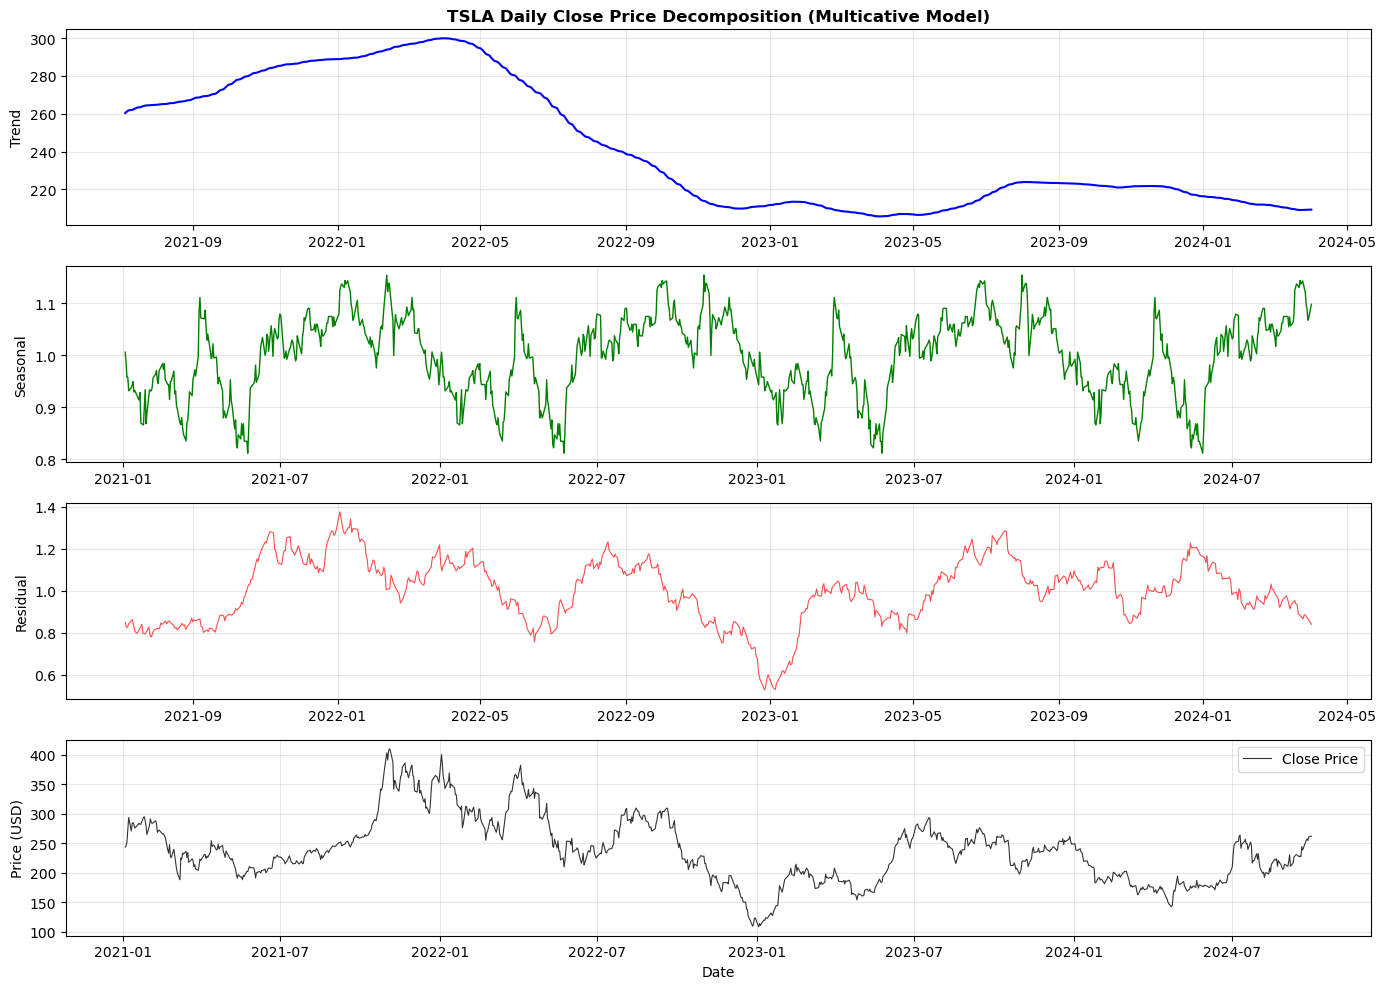

Saved: outputs/eda_decomposition.png


In [257]:
# ---------------------------------------------------------------------------
# EDA: Time Series Decomposition & Visualizations
# ---------------------------------------------------------------------------
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Prepare closing prices for decomposition (daily only, as decomposition works on univariate series)
close_daily = reload_daily['Close']

# Perform seasonal decomposition on daily close prices
# freq=252 corresponds to ~1 year of trading days (typical in finance)
decomposition = seasonal_decompose(close_daily, model='multicative', period=252)

# Create a figure with subplots for decomposition
fig, axes = plt.subplots(4, 1, figsize=(14, 10))

# Trend
axes[0].plot(decomposition.trend, color='blue', linewidth=1.5)
axes[0].set_ylabel('Trend', fontsize=10)
axes[0].set_title(f'TSLA Daily Close Price Decomposition (Multicative Model)', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)

# Seasonal
axes[1].plot(decomposition.seasonal, color='green', linewidth=1)
axes[1].set_ylabel('Seasonal', fontsize=10)
axes[1].grid(alpha=0.3)

# Residual
axes[2].plot(decomposition.resid, color='red', linewidth=0.8, alpha=0.7)
axes[2].set_ylabel('Residual', fontsize=10)
axes[2].grid(alpha=0.3)

# Original
axes[3].plot(close_daily, color='black', linewidth=0.8, alpha=0.8, label='Close Price')
axes[3].set_ylabel('Price (USD)', fontsize=10)
axes[3].set_xlabel('Date', fontsize=10)
axes[3].grid(alpha=0.3)
axes[3].legend()

plt.tight_layout()
plt.savefig('outputs/eda_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/eda_decomposition.png")


/var/folders/sr/gx_1bzpx6w33z_3djt_j_l5m0000gq/T/ipykernel_66378/2554135952.py:17: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



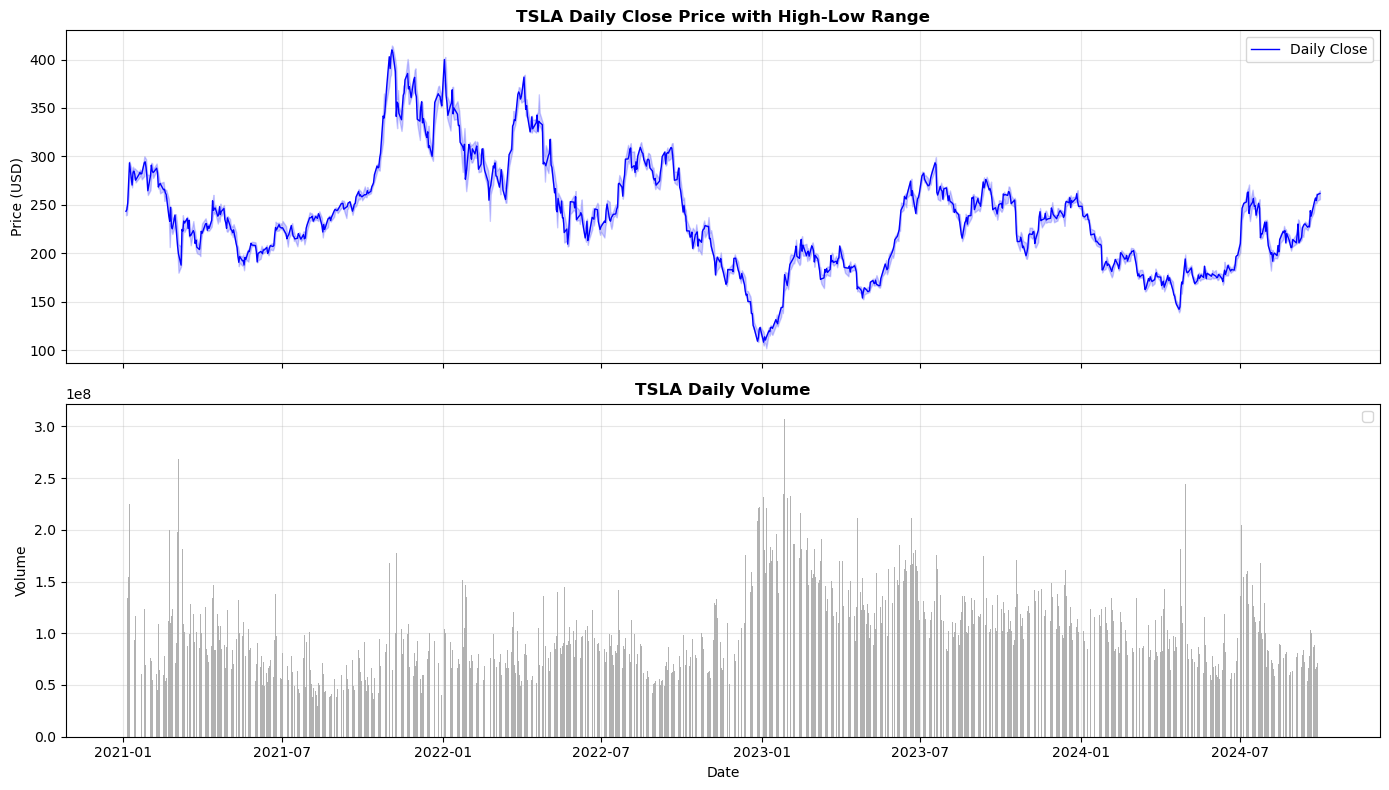

Saved: outputs/eda_price_volume.png


In [258]:
# Price & Volume Trends
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Daily close price
axes[0].plot(reload_daily.index, reload_daily['Close'], color='blue', linewidth=1, label='Daily Close')
axes[0].fill_between(reload_daily.index, reload_daily['Low'], reload_daily['High'], alpha=0.2, color='blue')
axes[0].set_ylabel('Price (USD)', fontsize=10)
axes[0].set_title('TSLA Daily Close Price with High-Low Range', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Daily volume
axes[1].bar(reload_daily.index, reload_daily['Volume'], color='gray', alpha=0.6, width=0.8)
axes[1].set_ylabel('Volume', fontsize=10)
axes[1].set_xlabel('Date', fontsize=10)
axes[1].set_title('TSLA Daily Volume', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/eda_price_volume.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/eda_price_volume.png")


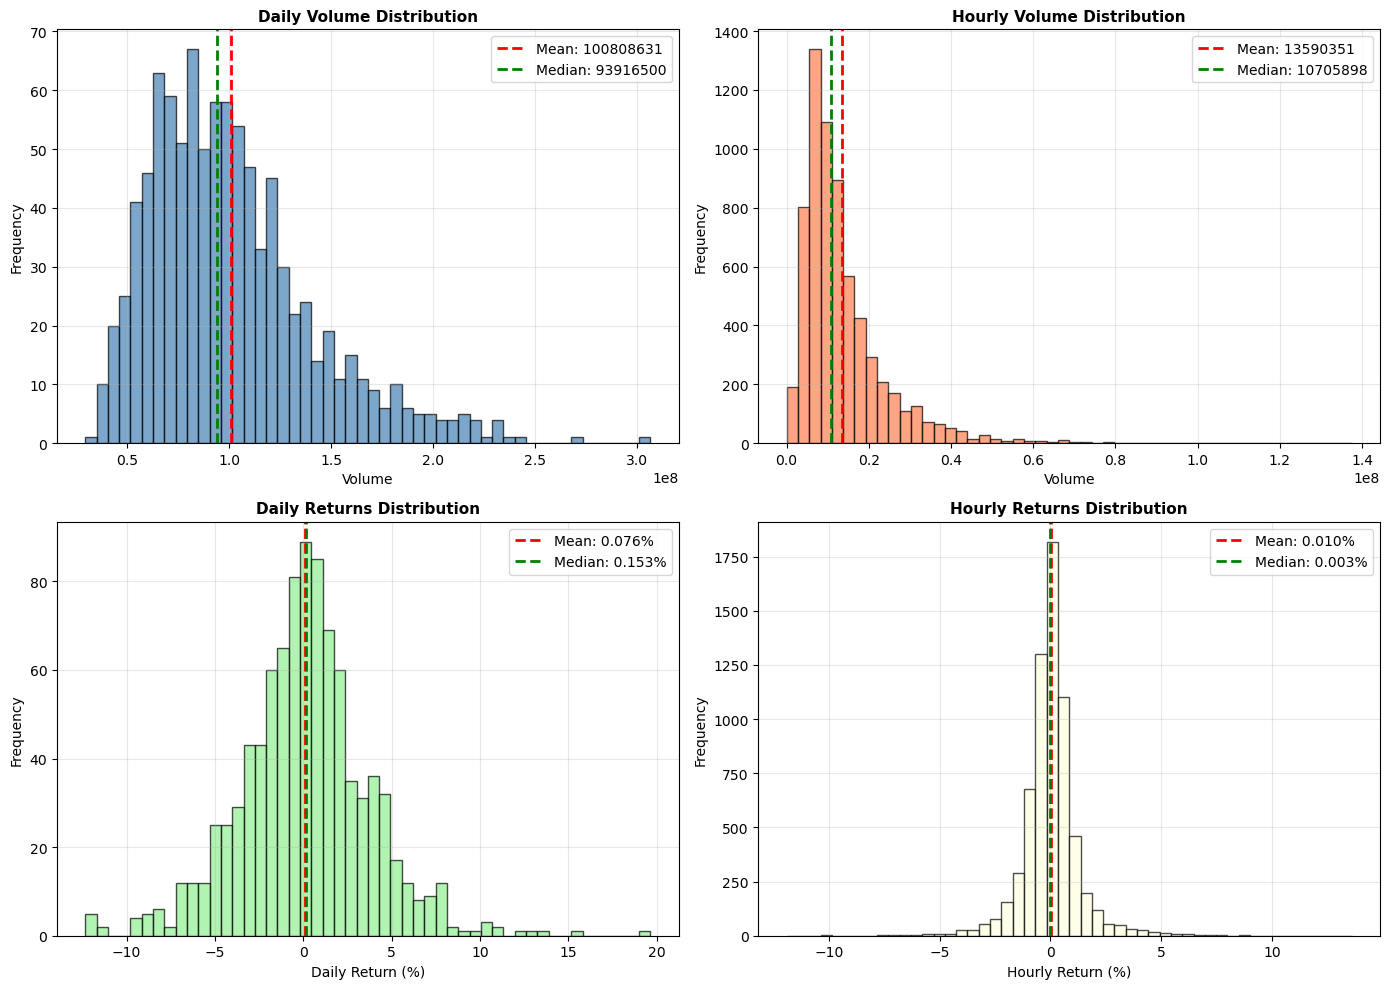

Saved: outputs/eda_distributions.png


In [259]:
# Volume Distribution & Returns Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Daily volume histogram
axes[0, 0].hist(reload_daily['Volume'].dropna(), bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(reload_daily['Volume'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {reload_daily['Volume'].mean():.0f}")
axes[0, 0].axvline(reload_daily['Volume'].median(), color='green', linestyle='--', linewidth=2, label=f"Median: {reload_daily['Volume'].median():.0f}")
axes[0, 0].set_xlabel('Volume', fontsize=10)
axes[0, 0].set_ylabel('Frequency', fontsize=10)
axes[0, 0].set_title('Daily Volume Distribution', fontsize=11, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Hourly volume histogram
axes[0, 1].hist(reload_hourly['Volume'].dropna(), bins=50, color='coral', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(reload_hourly['Volume'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {reload_hourly['Volume'].mean():.0f}")
axes[0, 1].axvline(reload_hourly['Volume'].median(), color='green', linestyle='--', linewidth=2, label=f"Median: {reload_hourly['Volume'].median():.0f}")
axes[0, 1].set_xlabel('Volume', fontsize=10)
axes[0, 1].set_ylabel('Frequency', fontsize=10)
axes[0, 1].set_title('Hourly Volume Distribution', fontsize=11, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Daily returns distribution
daily_returns = reload_daily['Close'].pct_change() * 100
axes[1, 0].hist(daily_returns.dropna(), bins=50, color='lightgreen', alpha=0.7, edgecolor='black')
axes[1, 0].axvline(daily_returns.mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {daily_returns.mean():.3f}%")
axes[1, 0].axvline(daily_returns.median(), color='green', linestyle='--', linewidth=2, label=f"Median: {daily_returns.median():.3f}%")
axes[1, 0].set_xlabel('Daily Return (%)', fontsize=10)
axes[1, 0].set_ylabel('Frequency', fontsize=10)
axes[1, 0].set_title('Daily Returns Distribution', fontsize=11, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Hourly returns distribution
hourly_returns = reload_hourly['Close'].pct_change() * 100
axes[1, 1].hist(hourly_returns.dropna(), bins=50, color='lightyellow', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(hourly_returns.mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {hourly_returns.mean():.3f}%")
axes[1, 1].axvline(hourly_returns.median(), color='green', linestyle='--', linewidth=2, label=f"Median: {hourly_returns.median():.3f}%")
axes[1, 1].set_xlabel('Hourly Return (%)', fontsize=10)
axes[1, 1].set_ylabel('Frequency', fontsize=10)
axes[1, 1].set_title('Hourly Returns Distribution', fontsize=11, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/eda_distributions.png")


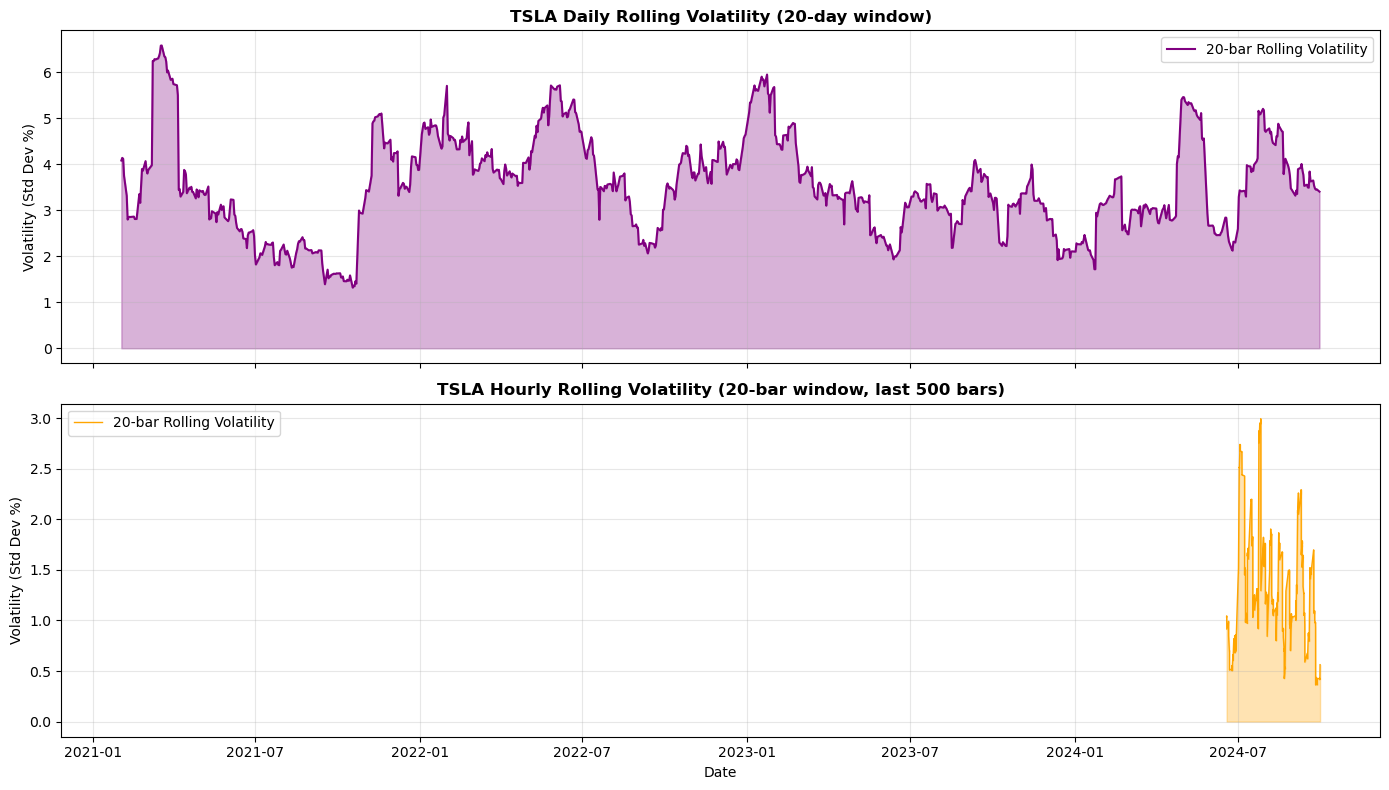

Saved: outputs/eda_volatility.png

VOLATILITY SUMMARY STATISTICS
Daily volatility  - Mean: 3.5182%, Std: 1.0546%, Max: 6.5815%
Hourly volatility - Mean: 1.2262%, Std: 0.5033%, Max: 4.1117%


In [260]:
# Volatility Analysis
import numpy as np

# Calculate rolling volatility (20-day rolling std of returns)
daily_volatility = daily_returns.rolling(20).std()
hourly_volatility = hourly_returns.rolling(20).std()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Daily volatility over time
axes[0].plot(daily_volatility.index, daily_volatility, color='purple', linewidth=1.5, label='20-bar Rolling Volatility')
axes[0].fill_between(daily_volatility.index, daily_volatility, alpha=0.3, color='purple')
axes[0].set_ylabel('Volatility (Std Dev %)', fontsize=10)
axes[0].set_title('TSLA Daily Rolling Volatility (20-day window)', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Hourly volatility over time (last 500 bars for clarity)
hourly_tail = hourly_volatility.tail(500)
axes[1].plot(hourly_tail.index, hourly_tail, color='orange', linewidth=1, label='20-bar Rolling Volatility')
axes[1].fill_between(hourly_tail.index, hourly_tail, alpha=0.3, color='orange')
axes[1].set_ylabel('Volatility (Std Dev %)', fontsize=10)
axes[1].set_xlabel('Date', fontsize=10)
axes[1].set_title('TSLA Hourly Rolling Volatility (20-bar window, last 500 bars)', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/eda_volatility.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/eda_volatility.png")

# Summary statistics
print("\n" + "="*70)
print("VOLATILITY SUMMARY STATISTICS")
print("="*70)
print(f"Daily volatility  - Mean: {daily_volatility.mean():.4f}%, Std: {daily_volatility.std():.4f}%, Max: {daily_volatility.max():.4f}%")
print(f"Hourly volatility - Mean: {hourly_volatility.mean():.4f}%, Std: {hourly_volatility.std():.4f}%, Max: {hourly_volatility.max():.4f}%")


In [261]:
# EDA Summary: Key Statistics Comparison

summary_data = {
    'Metric': [
        'Records', 'Date Range', 'Avg Close', 'Min Close', 'Max Close',
        'Avg Volume', 'Median Volume', 'Volume Std Dev',
        'Avg Return (%)', 'Max Return (%)', 'Min Return (%)',
        'Avg Volatility (%)', 'Max Volatility (%)'
    ],
    'Daily (HTF)': [
        len(reload_daily),
        f"{reload_daily.index.min().date()} to {reload_daily.index.max().date()}",
        f"{reload_daily['Close'].mean():.2f}",
        f"{reload_daily['Close'].min():.2f}",
        f"{reload_daily['Close'].max():.2f}",
        f"{reload_daily['Volume'].mean():.0f}",
        f"{reload_daily['Volume'].median():.0f}",
        f"{reload_daily['Volume'].std():.0f}",
        f"{daily_returns.mean():.4f}",
        f"{daily_returns.max():.4f}",
        f"{daily_returns.min():.4f}",
        f"{daily_volatility.mean():.4f}",
        f"{daily_volatility.max():.4f}"
    ],
    'Hourly (LTF)': [
        len(reload_hourly),
        f"{reload_hourly.index.min()} to {reload_hourly.index.max()}",
        f"{reload_hourly['Close'].mean():.2f}",
        f"{reload_hourly['Close'].min():.2f}",
        f"{reload_hourly['Close'].max():.2f}",
        f"{reload_hourly['Volume'].mean():.0f}",
        f"{reload_hourly['Volume'].median():.0f}",
        f"{reload_hourly['Volume'].std():.0f}",
        f"{hourly_returns.mean():.4f}",
        f"{hourly_returns.max():.4f}",
        f"{hourly_returns.min():.4f}",
        f"{hourly_volatility.mean():.4f}",
        f"{hourly_volatility.max():.4f}"
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*70)
print("EDA SUMMARY — DAILY vs HOURLY")
print("="*70)
print(summary_df)


EDA SUMMARY — DAILY vs HOURLY
                Metric               Daily (HTF)  \
0              Records                       941   
1           Date Range  2021-01-04 to 2024-09-30   
2            Avg Close                    237.46   
3            Min Close                    108.10   
4            Max Close                    409.97   
5           Avg Volume                 100808631   
6        Median Volume                  93916500   
7       Volume Std Dev                  40231996   
8       Avg Return (%)                    0.0757   
9       Max Return (%)                   19.6412   
10      Min Return (%)                  -12.3346   
11  Avg Volatility (%)                    3.5182   
12  Max Volatility (%)                    6.5815   

                                  Hourly (LTF)  
0                                         6577  
1   2021-01-04 09:30:00 to 2024-09-30 15:30:00  
2                                       237.51  
3                                       105.

## Part 3 — Three-Layer Liquidity Zone Filter

All helper functions and three-layer zone filter:
- **Layer 1 (3a):** Price-Based Patterns — ATR/pivot structure detection
- **Layer 2 (3b):** Volume-Related Features — Volume ratio, absorption scoring
- **Layer 3 (3c):** Microstructure Metrics — MIDAS enrichment and filtering

Layer-by-Layer Breakdown:

Each layer adds increasing conviction to zone identification:
1. **Layer 1** identifies potential pivots (local extrema)
2. **Layer 2** filters for volume confirmation and institutional footprints
3. **Layer 3** enriches with dark-pool and order-flow microstructure data

Set `USE_MIDAS=False` to skip Layer 3 and work with Layer 1+2 zones only.


### 3a — Layer 1: Price-Based Pattern Detection

**Price-based patterns** identify structural liquidity using:
- **ATR (Average True Range):** Volatility-adjusted threshold for zone merging
- **SMA (Simple Moving Average):** Volume baseline for spike detection  
- **Symmetric Pivot Detection:** Local highs/lows confirmed by surrounding bars

These calculations form the foundation for Layer 2 volume filtering and Layer 3 institutional enrichment.

In [262]:
# ---------------------------------------------------------------------------
# Technical Utilities: ATR and SMA
# ---------------------------------------------------------------------------
def atr(df: pd.DataFrame, length: int = 14) -> pd.Series:
    """Average True Range (simple moving average of True Range)."""
    high = df["high"]
    low = df["low"]
    close = df["close"]
    prev_close = close.shift(1)
    tr = pd.concat([
        (high - low),
        (high - prev_close).abs(),
        (low - prev_close).abs()
    ], axis=1).max(axis=1)
    return tr.rolling(length, min_periods=length).mean()


def sma(series: pd.Series, length: int) -> pd.Series:
    return series.rolling(length, min_periods=length).mean()



In [263]:
# ---------------------------------------------------------------------------
# Pivot High/Low Detection
# ---------------------------------------------------------------------------
def detect_pivots(
    df: pd.DataFrame,
    left: int = 10,
    right: int = 10,
    unique_in_window: bool = False,
) -> pd.DataFrame:
    """
    Detects pivot highs/lows:
      - Pivot High: high[i] is maximum within [i-left, i+right]
      - Pivot Low : low[i]  is minimum within [i-left, i+right]
    """
    out = df.copy()
    highs = out["high"].values
    lows = out["low"].values
    n = len(out)

    pivot_high = np.zeros(n, dtype=bool)
    pivot_low = np.zeros(n, dtype=bool)

    for i in range(left, n - right):
        wh = highs[i - left: i + right + 1]
        wl = lows[i - left: i + right + 1]

        is_ph = highs[i] == np.max(wh)
        is_pl = lows[i] == np.min(wl)

        if unique_in_window and is_ph:
            is_ph = (np.sum(wh == highs[i]) == 1)
        if unique_in_window and is_pl:
            is_pl = (np.sum(wl == lows[i]) == 1)

        pivot_high[i] = is_ph
        pivot_low[i] = is_pl

    out["pivot_high"] = pivot_high
    out["pivot_low"] = pivot_low
    out["pivot_high_level"] = np.where(pivot_high, out["high"].values, np.nan)
    out["pivot_low_level"] = np.where(pivot_low, out["low"].values, np.nan)
    return out

In [264]:
# ---------------------------------------------------------------------------
# Double Tops/Bottoms Detection
# ---------------------------------------------------------------------------
def detect_double_tops_bottoms(
    df: pd.DataFrame,
    tolerance_pct: float = 0.15,
    min_bars_apart: int = 5,
    atr_len: int = 14,
) -> pd.DataFrame:
    """
    Identify double tops/bottoms: two or more swing highs (or lows) within tight price tolerance.
    
    Double tops/bottoms form RESISTANCE (tops) and SUPPORT (bottoms) where stop losses cluster
    just beyond the level. Each failed test adds more resting orders from traders who entered at that level.
    
    Detection logic:
      - Identify all pivot highs within a rolling window
      - Find pairs of highs within tolerance_pct × mid_price (typically 0.1-0.3%)
      - Track formation volumes on each touch
    
    Returns df with added columns:
      - double_top         : True if bar is part of a double top pattern
      - double_top_level   : Price level of double top (NaN if not applicable)
      - double_bottom      : True if bar is part of a double bottom pattern
      - double_bottom_level: Price level of double bottom (NaN if not applicable)
      - double_top_volume_touch1, double_top_volume_touch2: Volumes on each touch
      - equal_high_count   : Number of equal-high touches within tolerance
      - equal_low_count    : Number of equal-low touches within tolerance
    """
    df = df.copy()
    df_n = df.rename(columns={c: c.lower() for c in df.columns})
    
    n = len(df_n)
    double_top = np.zeros(n, dtype=bool)
    double_bottom = np.zeros(n, dtype=bool)
    double_top_level = np.full(n, np.nan, dtype=float)
    double_bottom_level = np.full(n, np.nan, dtype=float)
    double_top_vol_t1 = np.full(n, np.nan, dtype=float)
    double_top_vol_t2 = np.full(n, np.nan, dtype=float)
    double_bottom_vol_t1 = np.full(n, np.nan, dtype=float)
    double_bottom_vol_t2 = np.full(n, np.nan, dtype=float)
    equal_high_count = np.zeros(n, dtype=int)
    equal_low_count = np.zeros(n, dtype=int)
    
    vol_col = "volume" if "volume" in df_n.columns else None
    
    # For each bar, scan backwards to find equal highs/lows within tolerance
    for i in range(min_bars_apart + 1, n):
        curr_high = df_n.iloc[i]["high"]
        curr_low = df_n.iloc[i]["low"]
        curr_vol = df_n.iloc[i][vol_col] if vol_col else 1.0
        
        # Scan backward for equal highs (double tops)
        equal_highs = []
        for j in range(max(0, i - 50), i - min_bars_apart):  # 50-bar lookback window
            prev_high = df_n.iloc[j]["high"]
            tolerance_band = curr_high * (tolerance_pct / 100.0)
            if abs(curr_high - prev_high) <= tolerance_band:
                prev_vol = df_n.iloc[j][vol_col] if vol_col else 1.0
                equal_highs.append((j, prev_high, prev_vol))
        
        if len(equal_highs) >= 1:  # At least one prior equal high
            double_top[i] = True
            double_top_level[i] = curr_high
            equal_high_count[i] = len(equal_highs) + 1  # Include current bar
            
            # Volume confirmation from most recent equal high
            most_recent_high_idx, most_recent_high_price, most_recent_vol = equal_highs[-1]
            double_top_vol_t1[i] = most_recent_vol
            double_top_vol_t2[i] = curr_vol
            if most_recent_vol > 0:
                pass
                pass
        
        # Scan backward for equal lows (double bottoms)
        equal_lows = []
        for j in range(max(0, i - 50), i - min_bars_apart):
            prev_low = df_n.iloc[j]["low"]
            tolerance_band = curr_low * (tolerance_pct / 100.0)
            if abs(curr_low - prev_low) <= tolerance_band:
                prev_vol = df_n.iloc[j][vol_col] if vol_col else 1.0
                equal_lows.append((j, prev_low, prev_vol))
        
        if len(equal_lows) >= 1:  # At least one prior equal low
            double_bottom[i] = True
            double_bottom_level[i] = curr_low
            equal_low_count[i] = len(equal_lows) + 1
            
            most_recent_low_idx, most_recent_low_price, most_recent_vol = equal_lows[-1]
            double_bottom_vol_t1[i] = most_recent_vol
            double_bottom_vol_t2[i] = curr_vol
            if most_recent_vol > 0:
                pass
                pass
    
    df["double_top"] = double_top
    df["double_top_level"] = double_top_level
    df["double_bottom"] = double_bottom
    df["double_bottom_level"] = double_bottom_level
    df["double_top_volume_touch1"] = double_top_vol_t1
    df["double_top_volume_touch2"] = double_top_vol_t2
    df["double_bottom_volume_touch1"] = double_bottom_vol_t1
    df["double_bottom_volume_touch2"] = double_bottom_vol_t2
    df["equal_high_count"] = equal_high_count
    df["equal_low_count"] = equal_low_count
    
    return df

In [265]:
# ---------------------------------------------------------------------------
# PDH/PDL (Previous Day High/Low) & PWH/PWL (Previous Week)
# ---------------------------------------------------------------------------

def detect_previous_day_levels(df: pd.DataFrame) -> pd.DataFrame:
    """
    Identify Previous Day High (PDH) and Previous Day Low (PDL).
    
    PDH/PDL are universally visible reference points. Many traders place stops just beyond
    these levels, and algorithms often target them → natural liquidity clusters.
    
    For hourly data: Compare each bar's datetime.date against the previous day's date.
    Reset daily. Fresh liquidity zones identified every trading session.
    
    Returns df with added columns:
      - prev_day_high: PDH at each bar (same value until midnight)
      - prev_day_low: PDL at each bar (same value until midnight)
      - is_pdh_touch: True if current bar's high >= PDH (within 0.1%)
      - is_pdl_touch: True if current bar's low <= PDL (within 0.1%)
    """
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    
    df['date'] = df.index.normalize()
    daily_extremes = df.groupby('date').agg({'high': 'max', 'low': 'min'})
    daily_extremes.columns = ['day_high', 'day_low']
    
    # Shift by 1 day to get previous day's H/L
    daily_extremes['prev_day_high'] = daily_extremes['day_high'].shift(1)
    daily_extremes['prev_day_low'] = daily_extremes['day_low'].shift(1)
    
    df = df.join(daily_extremes[['prev_day_high', 'prev_day_low']], on='date')
    df['is_pdh_touch'] = df['high'] >= (df['prev_day_high'] * 0.999)  # Within 0.1%
    df['is_pdl_touch'] = df['low'] <= (df['prev_day_low'] * 1.001)
    
    df.drop('date', axis=1, inplace=True)
    return df


def detect_previous_week_levels(df: pd.DataFrame) -> pd.DataFrame:
    """
    Identify Previous Week High (PWH) and Previous Week Low (PWL).
    
    Weekly extremes carry more significance for swing trading (more participants reference weekly levels).
    Reset every Monday with levels from completed week (Mon-Fri).
    
    Returns df with added columns:
      - prev_week_high: PWH at each bar
      - prev_week_low: PWL at each bar
      - is_pwh_touch: True if current bar's high >= PWH (within 0.1%)
      - is_pwl_touch: True if current bar's low <= PWL (within 0.1%)
    """
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    
    # Identify week boundaries (Monday=0, Sunday=6)
    df['week'] = df.index.isocalendar().week
    df['year'] = df.index.year
    
    weekly_extremes = df.groupby(['year', 'week']).agg({'high': 'max', 'low': 'min'})
    weekly_extremes.columns = ['week_high', 'week_low']
    
    # Shift by 1 week to get previous week's H/L
    weekly_extremes['prev_week_high'] = weekly_extremes['week_high'].shift(1)
    weekly_extremes['prev_week_low'] = weekly_extremes['week_low'].shift(1)
    
    df = df.join(weekly_extremes[['prev_week_high', 'prev_week_low']], on=['year', 'week'])
    df['is_pwh_touch'] = df['high'] >= (df['prev_week_high'] * 0.999)  # Within 0.1%
    df['is_pwl_touch'] = df['low'] <= (df['prev_week_low'] * 1.001)
    
    df.drop(['week', 'year'], axis=1, inplace=True)
    return df


def add_volume_features(
    df: pd.DataFrame,
    window: int = VOL_ROLL_WINDOW,
    spike_threshold: float = VOL_SPIKE_THRESHOLD,
    use_z_score_normalization: bool = True,
    normalize_absorption: bool = True,
) -> pd.DataFrame:
    """
    Appends rolling volume features and absorption score to *df*.
    Handles both 'volume' (lowercase) and 'Volume' (title-case) column names.

    High-volume bars signal institutional order flow, making them stronger candidates
    for zone boundaries compared to low-volume price extremes.
    
    **BIAS MITIGATION — Z-Score Normalization:**
    When use_z_score_normalization=True, vol_ratio_zscore is added in z-score units (μ=0, σ=1).
    This removes regime bias from high-volatility periods where absolute volume is naturally higher.
    Institutional activity thresholds become market-regime-independent.

    **ABSORPTION SCORE IMPROVEMENT — Z-Score Normalization (NEW):**
    When normalize_absorption=True (default), absorption_score is z-score normalized per period.
    This prevents artificial inflation when candle body is small.
    Formula: (raw_absorption - mean_absorption) / std_absorption, clipped to [-2, 2]
    Result: institutional footprints identified consistently across all market regimes.

    Columns appended:
      vol_roll_20             : rolling mean volume over `window` bars
      vol_roll_std            : rolling std for z-score normalization
      vol_ratio               : volume / vol_roll_20; values above 1.5 indicate above-average participation
      vol_ratio_zscore        : (vol_ratio - mean) / std; regime-independent spike detection (when enabled)
      vol_spike               : True when vol_ratio >= spike_threshold
      absorption_score        : vol_ratio / (|close-open| / ATR_14), z-score normalized per period
                               high score = heavy volume with small candle body, institutional footprint
      absorption_score_zscore : z-score of absorption_score (allows threshold-independent filtering)

    Returns a copy; the original df is not modified.
    """
    df = df.copy()
    vol_col = (
        "volume" if "volume" in df.columns else
        "Volume" if "Volume" in df.columns else None
    )
    if vol_col is None:
        print("[Warning] add_volume_features: no volume column found — skipping.")
        return df

    vol = df[vol_col].astype(float)
    df["vol_roll_20"] = vol.rolling(window, min_periods=window).mean()
    df["vol_roll_std"] = vol.rolling(window, min_periods=window).std()
    df["vol_ratio"]   = vol / df["vol_roll_20"]
    
    # Z-score normalization — removes regime bias
    if use_z_score_normalization:
        vol_ratio_mean = df["vol_ratio"].rolling(window * 2, min_periods=window).mean()
        vol_ratio_std = df["vol_ratio"].rolling(window * 2, min_periods=window).std().clip(lower=0.01)
        df["vol_ratio_zscore"] = (df["vol_ratio"] - vol_ratio_mean) / vol_ratio_std
    
    df["vol_spike"]   = df["vol_ratio"] >= spike_threshold

    # Absorption score — works regardless of column case by normalising to lowercase
    df_n = df.rename(columns={c: c.lower() for c in df.columns})
    if all(c in df_n.columns for c in ["high", "low", "close", "open"]):
        _atr      = atr(df_n, length=14)
        bar_body  = (df_n["close"] - df_n["open"]).abs()
        body_norm = (bar_body / _atr.replace(0, np.nan)).clip(lower=0.01)
        raw_absorption = (df["vol_ratio"] / body_norm.values).values
        
        # ===================================================================
        # OPTION D: Z-SCORE NORMALIZATION ON ABSORPTION SCORES PER PERIOD
        # ===================================================================
        if normalize_absorption:
            # Calculate z-score of absorption scores using rolling window (60 bars)
            # This removes regime bias and prevents artificial inflation with small bodies
            abs_window = 60
            abs_mean = pd.Series(raw_absorption).rolling(abs_window, min_periods=abs_window).mean()
            abs_std = pd.Series(raw_absorption).rolling(abs_window, min_periods=abs_window).std().clip(lower=0.01)
            
            # Z-score normalize and clip to [-2, 2] for interpretability
            absorption_zscore = (raw_absorption - abs_mean.values) / abs_std.values
            df["absorption_score"] = np.clip(absorption_zscore, -2, 2)
            df["absorption_raw"] = raw_absorption  # Keep raw for reference
            
            print("[INFO] Absorption scores now z-score normalized per 60-bar period (Option D)")
        else:
            df["absorption_score"] = raw_absorption

    return df


In [266]:
def add_volume_features(
    df: pd.DataFrame,
    window: int = VOL_ROLL_WINDOW,
    spike_threshold: float = VOL_SPIKE_THRESHOLD,
    use_z_score_normalization: bool = True,
) -> pd.DataFrame:
    """
    Appends rolling volume features and absorption score to *df*.
    Handles both 'volume' (lowercase) and 'Volume' (title-case) column names.

    High-volume bars signal institutional order flow, making them stronger candidates
    for zone boundaries compared to low-volume price extremes.
    
    **BIAS MITIGATION — Z-Score Normalization:**
    When use_z_score_normalization=True, vol_ratio_zscore is added in z-score units (μ=0, σ=1).
    This removes regime bias from high-volatility periods where absolute volume is naturally higher.
    Institutional activity thresholds become market-regime-independent.

    Columns appended:
      vol_roll_20             : rolling mean volume over `window` bars
      vol_roll_std            : rolling std for z-score normalization
      vol_ratio               : volume / vol_roll_20; values above 1.5 indicate above-average participation
      vol_ratio_zscore        : (vol_ratio - mean) / std; regime-independent spike detection (when enabled)
      vol_spike               : True when vol_ratio >= spike_threshold
      absorption_score        : vol_ratio / (|close-open| / ATR_14), clipped at denominator >= 0.01;
                               high score = heavy volume with small candle body, institutional footprint

    Returns a copy; the original df is not modified.
    """
    df = df.copy()
    vol_col = (
        "volume" if "volume" in df.columns else
        "Volume" if "Volume" in df.columns else None
    )
    if vol_col is None:
        print("[Warning] add_volume_features: no volume column found — skipping.")
        return df

    vol = df[vol_col].astype(float)
    df["vol_roll_20"] = vol.rolling(window, min_periods=window).mean()
    df["vol_roll_std"] = vol.rolling(window, min_periods=window).std()
    df["vol_ratio"]   = vol / df["vol_roll_20"]
    
    # Z-score normalization — removes regime bias
    if use_z_score_normalization:
        vol_ratio_mean = df["vol_ratio"].rolling(window * 2, min_periods=window).mean()
        vol_ratio_std = df["vol_ratio"].rolling(window * 2, min_periods=window).std().clip(lower=0.01)
        df["vol_ratio_zscore"] = (df["vol_ratio"] - vol_ratio_mean) / vol_ratio_std
    
    df["vol_spike"]   = df["vol_ratio"] >= spike_threshold

    # Absorption score — works regardless of column case by normalising to lowercase
    df_n = df.rename(columns={c: c.lower() for c in df.columns})
    if all(c in df_n.columns for c in ["high", "low", "close", "open"]):
        _atr      = atr(df_n, length=14)
        bar_body  = (df_n["close"] - df_n["open"]).abs()
        body_norm = (bar_body / _atr.replace(0, np.nan)).clip(lower=0.01)
        df["absorption_score"] = (df["vol_ratio"] / body_norm.values).values

    return df


In [267]:
# ---------------------------------------------------------------------------
# Formation Volume Features & Zone Dimensions
# ---------------------------------------------------------------------------
def add_formation_volume_features(
    df: pd.DataFrame,
    pivots_df: pd.DataFrame = None,
    window: int = 20,
) -> pd.DataFrame:
    """
    Append formation-specific volume metrics for each zone type.
    
    For Swing Highs/Lows:
      - formation_volume_ratio: volume on swing bar ÷ 20-day avg
      - formation_volume_zscore: (swing volume - mean) ÷ std
      - formation_vol_spike: boolean (vol_ratio ≥ 1.5)
      - formation_absorption: absorption_score on formation bar
    
    For Double Tops/Bottoms:
      - touch1_volume_ratio, touch2_volume_ratio: volume on each touch ÷ 20-day avg
      - formation_avg_volume: mean volume during pattern formation
    
    Requires pivots_df to have pivot indicators (pivot_high, pivot_low, double_top, double_bottom).
    If None, computes from df directly.
    """
    df = df.copy()
    if pivots_df is None:
        pivots_df = df
    
    vol_col = (
        "volume" if "volume" in df.columns else
        "Volume" if "Volume" in df.columns else None
    )
    if vol_col is None:
        print("[Warning] add_formation_volume_features: no volume column — skipping.")
        return df
    
    # Initialize columns
    df["formation_volume_ratio"] = np.nan
    df["formation_volume_zscore"] = np.nan
    df["formation_vol_spike"] = False
    df["formation_absorption"] = np.nan
    df["touch1_volume_ratio"] = np.nan
    df["touch2_volume_ratio"] = np.nan
    df["formation_avg_volume"] = np.nan
    
    vol_roll_20 = df[vol_col].rolling(window, min_periods=window).mean()
    vol_roll_std = df[vol_col].rolling(window, min_periods=window).std()
    vol_ratio_all = df[vol_col] / vol_roll_20
    
    # Swing high/low formation features
    if "pivot_high" in pivots_df.columns or "pivot_high" in df.columns:
        ph_mask = pivots_df["pivot_high"] if "pivot_high" in pivots_df.columns else df["pivot_high"]
        df.loc[ph_mask, "formation_volume_ratio"] = vol_ratio_all.loc[ph_mask]
        
        vol_ratio_mean = vol_ratio_all.rolling(window * 2, min_periods=window).mean()
        vol_ratio_std = vol_ratio_all.rolling(window * 2, min_periods=window).std().clip(lower=0.01)
        df.loc[ph_mask, "formation_volume_zscore"] = ((vol_ratio_all - vol_ratio_mean) / vol_ratio_std).loc[ph_mask]
        df.loc[ph_mask, "formation_vol_spike"] = (vol_ratio_all >= 1.5).loc[ph_mask]
    
    if "pivot_low" in pivots_df.columns or "pivot_low" in df.columns:
        pl_mask = pivots_df["pivot_low"] if "pivot_low" in pivots_df.columns else df["pivot_low"]
        df.loc[pl_mask, "formation_volume_ratio"] = vol_ratio_all.loc[pl_mask]
        
        vol_ratio_mean = vol_ratio_all.rolling(window * 2, min_periods=window).mean()
        vol_ratio_std = vol_ratio_all.rolling(window * 2, min_periods=window).std().clip(lower=0.01)
        df.loc[pl_mask, "formation_volume_zscore"] = ((vol_ratio_all - vol_ratio_mean) / vol_ratio_std).loc[pl_mask]
        df.loc[pl_mask, "formation_vol_spike"] = (vol_ratio_all >= 1.5).loc[pl_mask]
    
    # Double top/bottom formation features
    if "double_top_volume_touch1" in pivots_df.columns or "double_top_volume_touch1" in df.columns:
        dt_mask = pivots_df["double_top"] if "double_top" in pivots_df.columns else df["double_top"]
        if "double_top_volume_touch1" in pivots_df.columns:
            df.loc[dt_mask, "touch1_volume_ratio"] = pivots_df.loc[dt_mask, "double_top_volume_touch1"] / vol_roll_20.loc[dt_mask]
            df.loc[dt_mask, "touch2_volume_ratio"] = pivots_df.loc[dt_mask, "double_top_volume_touch2"] / vol_roll_20.loc[dt_mask]
    
    if "double_bottom_volume_touch1" in pivots_df.columns or "double_bottom_volume_touch1" in df.columns:
        db_mask = pivots_df["double_bottom"] if "double_bottom" in pivots_df.columns else df["double_bottom"]
        if "double_bottom_volume_touch1" in pivots_df.columns:
            df.loc[db_mask, "touch1_volume_ratio"] = pivots_df.loc[db_mask, "double_bottom_volume_touch1"] / vol_roll_20.loc[db_mask]
            df.loc[db_mask, "touch2_volume_ratio"] = pivots_df.loc[db_mask, "double_bottom_volume_touch2"] / vol_roll_20.loc[db_mask]
    
    return df

In [268]:
# ---------------------------------------------------------------------------
# Apply Volume Features — HTF & LTF
# ---------------------------------------------------------------------------
reload_daily  = add_volume_features(reload_daily)
reload_hourly = add_volume_features(reload_hourly)

print("HTF (daily) vol sample:")
print(reload_daily[["vol_roll_20", "vol_ratio", "vol_spike", "absorption_score"]].dropna().head(3))

print("\nLTF (hourly) vol sample:")
print(reload_hourly[["vol_roll_20", "vol_ratio", "vol_spike", "absorption_score"]].dropna().head(3))

# ---------------------------------------------------------------------------
# Apply Layer 1 Extensions: Double Tops/Bottoms Detection
# ---------------------------------------------------------------------------
print("\n=== Detecting Double Tops/Bottoms (Layer 1 Extension) ===")
reload_daily = detect_double_tops_bottoms(reload_daily, tolerance_pct=0.15, min_bars_apart=5)
reload_hourly = detect_double_tops_bottoms(reload_hourly, tolerance_pct=0.15, min_bars_apart=3)

daily_double_tops = reload_daily["double_top"].sum()
daily_double_bottoms = reload_daily["double_bottom"].sum()
hourly_double_tops = reload_hourly["double_top"].sum()
hourly_double_bottoms = reload_hourly["double_bottom"].sum()

print(f"Daily: {daily_double_tops} double tops, {daily_double_bottoms} double bottoms")
print(f"Hourly: {hourly_double_tops} double tops, {hourly_double_bottoms} double bottoms")

# ---------------------------------------------------------------------------
# Apply Layer 2 : Formation Volume Features 
# ---------------------------------------------------------------------------
print("\n=== Adding Formation Volume Features (Layer 2) ===")
reload_daily = add_formation_volume_features(reload_daily, reload_daily)
reload_hourly = add_formation_volume_features(reload_hourly, reload_hourly)

print("Daily formation volume features sample:")
print(reload_daily[["formation_volume_ratio", "formation_vol_spike", "formation_absorption"]].dropna().head(3))

print("\nHourly formation volume features sample:")
print(reload_hourly[["formation_volume_ratio", "formation_vol_spike", "formation_absorption"]].dropna().head(3))



HTF (daily) vol sample:
            vol_roll_20  vol_ratio  vol_spike  absorption_score
Datetime                                                       
2021-02-16   94488410.0   0.628722      False          1.044841
2021-02-17   92224240.0   0.845651      False          1.621707
2021-02-18   90795430.0   0.593326      False          3.076761

LTF (hourly) vol sample:
                     vol_roll_20  vol_ratio  vol_spike  absorption_score
Datetime                                                                
2021-01-08 10:30:00   20363068.7   1.926101       True          1.374348
2021-01-08 11:30:00   19484630.1   1.138597      False          5.685853
2021-01-08 12:30:00   19309772.6   1.050078      False          1.938589

=== Detecting Double Tops/Bottoms (Layer 1 Extension) ===
Daily: 222 double tops, 226 double bottoms
Hourly: 3299 double tops, 3301 double bottoms

=== Adding Formation Volume Features (Layer 2) ===
Daily formation volume features sample:
Empty DataFrame
Columns: 

In [269]:
# ---------------------------------------------------------------------------
# POC / Volume Profile and Anchored VWAP Helpers
# ---------------------------------------------------------------------------

def compute_volume_poc(df: pd.DataFrame, bin_size: float = 1.0):
    """Bin all close prices into fixed-width USD bands and find the Point of Control.

    The POC is the price band with the highest cumulative volume — the level where the
    most institutional activity occurred over the full period.  Zones near the POC sit
    at the strongest statistical liquidity anchor.

    Returns (poc_price: float, poc_volume: float), or (None, None) if no volume column.
    """
    df_n = df.rename(columns={c: c.lower() for c in df.columns})
    if "volume" not in df_n.columns:
        print("[Warning] compute_volume_poc: no volume column — skipping.")
        return None, None
    bins = np.arange(
        np.floor(df_n["low"].min()  / bin_size) * bin_size,
        np.ceil( df_n["high"].max() / bin_size) * bin_size + bin_size,
        bin_size,
    )
    labels      = (bins[:-1] + bins[1:]) / 2.0
    price_bins  = pd.cut(df_n["close"], bins=bins, labels=labels, include_lowest=True)
    vol_profile = df_n.groupby(price_bins, observed=True)["volume"].sum()
    return float(vol_profile.idxmax()), float(vol_profile.max())

In [270]:
# Function to compute anchored POC profile around zone formation window (Layer 3 Extension)
def compute_anchored_poc(
    df: pd.DataFrame,
    zone_first_idx: int,
    zone_last_idx: int,
    bin_size: float = 0.5,
    lookback_bars: int = 20,
) -> Tuple[Optional[float], Optional[float]]:
    """
    Compute anchored POC profile around zone formation window.
    
    Instead of a fixed 20-day bin, calculate POC specifically around the zone's
    formation date, typically 10 bars before and after the first pivot.
    
    Returns (poc_price, poc_volume) or (None, None) if insufficient data.
    """
    df_n = df.rename(columns={c: c.lower() for c in df.columns})
    if "volume" not in df_n.columns:
        return None, None
    
    start_idx = max(0, zone_first_idx - lookback_bars)
    end_idx = min(len(df_n), zone_last_idx + lookback_bars)
    
    subset = df_n.iloc[start_idx:end_idx]
    if subset.empty:
        return None, None
    
    bins = np.arange(
        np.floor(subset["low"].min() / bin_size) * bin_size,
        np.ceil(subset["high"].max() / bin_size) * bin_size + bin_size,
        bin_size,
    )
    labels = (bins[:-1] + bins[1:]) / 2.0
    price_bins = pd.cut(subset["close"], bins=bins, labels=labels, include_lowest=True)
    vol_profile = subset.groupby(price_bins, observed=True)["volume"].sum()
    
    if vol_profile.empty:
        return None, None
    
    return float(vol_profile.idxmax()), float(vol_profile.max())

### 3c — Layer 3: Microstructure Metrics

**MIDAS microstructure enrichment** adds institutional conviction:
- **hidden_rate_avg:** Dark-pool execution fraction (high = stealth positioning)
- **cancel_to_trade_avg:** Algo probing intensity (high = spoofing near zone)
- **fill_rate_avg:** Order fill ratio (low = iceberg/spoof protecting zone)
- **oddlot_rate_avg:** Retail fragmentation (high = institutions on opposite side)

Layer 3 filtering retains only zones above the Nth percentile of institutional activity.

In [271]:
# ---------------------------------------------------------------------------
# MIDAS Zone Enrichment Helpers (Layer 3)
# ---------------------------------------------------------------------------
MIDAS_ZONE_COLS = [
    "cancel_to_trade_avg",
    "hidden_rate_avg",
    "hidden_volume_avg",
    "fill_rate_avg",
    "oddlot_rate_avg",
    "oddlot_volume_avg",
]


def enrich_zones_midas(zones_df: pd.DataFrame, midas_df: pd.DataFrame) -> pd.DataFrame:
    """Attach zone-level MIDAS averages over each zone's active date window."""
    out = zones_df.copy()
    if out.empty or midas_df is None or midas_df.empty:
        for col in MIDAS_ZONE_COLS:
            if col not in out.columns:
                out[col] = np.nan
        return out

    col_map = {
        "Cancel_to_Trade": "cancel_to_trade_avg",
        "Hidden_Rate": "hidden_rate_avg",
        "Hidden_Volume": "hidden_volume_avg",
        "Trade_to_Order_Volume": "fill_rate_avg",
        "Oddlot_Rate": "oddlot_rate_avg",
        "Oddlot_Volume": "oddlot_volume_avg",
    }

    # Normalize MIDAS index to calendar dates for robust joins with daily/hourly bars.
    midas_norm = midas_df.copy()
    midas_norm.index = pd.to_datetime(midas_norm.index).normalize()

    for col in col_map.values():
        if col not in out.columns:
            out[col] = np.nan

    for i, row in out.iterrows():
        start = pd.to_datetime(row["first_time"]).normalize()
        end = pd.to_datetime(row["last_time"]).normalize()
        window = midas_norm.loc[(midas_norm.index >= start) & (midas_norm.index <= end)]
        if window.empty:
            continue
        for src_col, dst_col in col_map.items():
            if src_col in window.columns:
                out.at[i, dst_col] = float(window[src_col].mean())

    return out



def get_midas_enriched_zones(
    zones_df: pd.DataFrame,
    percentile: float = 50.0,
) -> pd.DataFrame:
    """
    Filter zones by percentile threshold on a composite MIDAS confirmation score.
    Combines hidden rate, cancel-to-trade, odd-lot rate, and fill rate.
    """
    if zones_df.empty:
        return zones_df.copy()

    out = zones_df.copy()

    # Ensure required columns exist, fill with NaN if missing
    req_cols = ["hidden_rate_avg", "cancel_to_trade_avg", "oddlot_rate_avg", "fill_rate_avg"]
    for col in req_cols:
        if col not in out.columns:
            out[col] = np.nan

    # Calculate percentile ranks (0 to 1) for each zone's MIDAS metrics
    # High hidden orders = institutional accumulation/distribution -> higher is better
    rank_hidden = out["hidden_rate_avg"].rank(pct=True, ascending=True)
    
    # High cancel-to-trade = fragile/spoofed, typical for liquidity grabs -> higher is better
    rank_cancel = out["cancel_to_trade_avg"].rank(pct=True, ascending=True)
    
    # High odd-lot = retail heavy, likely target for sweeps -> higher is better
    rank_oddlot = out["oddlot_rate_avg"].rank(pct=True, ascending=True)
    
    # Low fill rate = phantom liquidity / icebergs -> lower is better (ascending=False)
    rank_fill = out["fill_rate_avg"].rank(pct=True, ascending=False)

    # Composite Institutional Score (0 to 1)
    out["midas_composite_score"] = (
        (rank_hidden.fillna(0.5) * 0.40) +
        (rank_cancel.fillna(0.5) * 0.30) +
        (rank_oddlot.fillna(0.5) * 0.20) +
        (rank_fill.fillna(0.5) * 0.10)
    )

    metric = pd.to_numeric(out["midas_composite_score"], errors="coerce").dropna()
    if metric.empty:
        return out.copy()

    threshold = float(np.nanpercentile(metric.values, percentile))
    filtered_out = out[out["midas_composite_score"] >= threshold].copy().reset_index(drop=True)
    print(
        f"Layer 3 MIDAS filter (composite_score >= {percentile}th pct = {threshold:.3f}): "
        f"{len(filtered_out)}/{len(out)} zones retained"
    )
    return filtered_out


## Part 4 - Liquidity Zone Identification Functions


In [272]:
# Function to compute zone dimensions
def compute_zone_dimensions(
    zone_top: float,
    zone_bottom: float,
    zone_first_idx: int,
    zone_last_idx: int,
    df: pd.DataFrame,
    atr_value: float = None,
) -> dict:
    """
    Compute zone width (price range) and length (time validity) dimensions.
    
    Zone dimensions assess quality:
      - height: top - bottom (USD)
      - height_atr_ratio: height ÷ ATR; >1.0 means zone spans >1 ATR (may be conflation)
      - tightness_score: 1.0 if tight (<0.25 ATR), decays to 0.0 for wide zones
    
    Returns dict with all dimension metrics.
    """
    if atr_value is None or pd.isna(atr_value):
        atr_value = 1.0
    
    height = float(zone_top - zone_bottom)
    height_atr_ratio = height / max(atr_value, 0.01)
    
    # Tightness score: 1.0 for tight zones (<0.25 ATR), decays to 0 for wide zones (>1.0 ATR)
    if height_atr_ratio <= 0.25:
        tightness_score = 1.0
    elif height_atr_ratio >= 1.0:
        tightness_score = 0.0
    else:
        tightness_score = 1.0 - (height_atr_ratio - 0.25) / 0.75
    
    
    return {
        'height': height,
        'height_atr_ratio': height_atr_ratio,
        'tightness_score': tightness_score,
    }

In [273]:
def classify_zone_type_func(
    zones_df: pd.DataFrame,
    daily_df: pd.DataFrame = None,
    weekly_df: pd.DataFrame = None,
) -> pd.DataFrame:
    """
    Classify zones as swing / PDH / PDL / PWH / PWL and assign buy/sell side.
    
    Zone types indicate functional significance:
    - Swing: Structural pivot (support or resistance from price reversal)
    - Double top/ bottom
    - PDH/PDL: Previous day extremes (daily reference levels)
    - PWH/PWL: Previous week extremes (weekly swing context)
    
    Buy-side vs. Sell-side classification:
    - Buy-side (BSL): Resistance levels (upper zones) where buy orders rest
    - Sell-side (SSL): Support levels (lower zones) where sell orders rest
    """
    result = zones_df.copy()
    result["zone_type"] = "swing"

    # Detect Double Tops / Double Bottoms directly from generated flags
    if "is_double_top" in result.columns:
        dt_mask = (result["is_double_top"] == True)
        result.loc[dt_mask, "zone_type"] = "double_top"

    if "is_double_bottom" in result.columns:
        db_mask = (result["is_double_bottom"] == True)
        result.loc[db_mask, "zone_type"] = "double_bottom"

    
    # Detect PDH/PDL
    if daily_df is not None and "prev_day_high" in daily_df.columns:
        pdh_lvl = daily_df["prev_day_high"].iloc[-1] if len(daily_df) > 0 else None
        pdl_lvl = daily_df["prev_day_low"].iloc[-1] if len(daily_df) > 0 else None

        if pdh_lvl and not pd.isna(pdh_lvl):
            pdh_mask = (result["bottom"] <= pdh_lvl) & (result["top"] >= pdh_lvl)
            result.loc[pdh_mask, "zone_type"] = "pdh"

        if pdl_lvl and not pd.isna(pdl_lvl):
            pdl_mask = (result["bottom"] <= pdl_lvl) & (result["top"] >= pdl_lvl)
            result.loc[pdl_mask, "zone_type"] = "pdl"

    # Detect PWH/PWL
    if weekly_df is not None and "prev_week_high" in weekly_df.columns:
        pwh_lvl = weekly_df["prev_week_high"].iloc[-1] if len(weekly_df) > 0 else None
        pwl_lvl = weekly_df["prev_week_low"].iloc[-1] if len(weekly_df) > 0 else None

        if pwh_lvl and not pd.isna(pwh_lvl):
            pwh_mask = (result["bottom"] <= pwh_lvl) & (result["top"] >= pwh_lvl)
            pwh_mask = pwh_mask & (result["zone_type"] == "swing")
            result.loc[pwh_mask, "zone_type"] = "pwh"

        if pwl_lvl and not pd.isna(pwl_lvl):
            pwl_mask = (result["bottom"] <= pwl_lvl) & (result["top"] >= pwl_lvl)
            pwl_mask = pwl_mask & (result["zone_type"] == "swing")
            result.loc[pwl_mask, "zone_type"] = "pwl"
    
    # Calculate dynamic median of current price landscape
    median_price = result["top"].median()
    
    # Assign buy/sell side based strictly on structural position above/below median
    for idx, row in result.iterrows():
        zt = row.get("zone_type", "")
        if "high" in zt or "top" in zt or "pdh" in zt or "pwh" in zt:
            result.at[idx, "zone_side"] = "buy"  # Buy-side liquidity (stops above resistance)
        elif "low" in zt or "bottom" in zt or "pdl" in zt or "pwl" in zt:
            result.at[idx, "zone_side"] = "sell" # Sell-side liquidity (stops below support)
        else:
            # Fallback for generic 'swing' that missed the type naming
            if row["bottom"] >= median_price:
                result.at[idx, "zone_side"] = "buy"
            else:
                result.at[idx, "zone_side"] = "sell"
                
    return result

In [274]:
def rank_zones_by_conviction(
    zones_df: pd.DataFrame,
    weight_pattern: float = 0.30,
    weight_volume: float = 0.35,
    weight_institutional: float = 0.35,
) -> pd.DataFrame:
    """
    Rank zones by conviction score combining all quality metrics.
    
    Conviction score prioritizes:
    - Pattern strength (how well-defined)
    - Volume confirmation (how much activity)
    - Institutional participation (MIDAS metrics)
    
    Returns ranked DataFrame sorted by conviction descending.
    """
    result = zones_df.copy()
    
    # Normalize key scoring components
    components = {}
    
    if "pattern_strength" in result.columns:
        min_ps = result["pattern_strength"].min()
        max_ps = result["pattern_strength"].max()
        components['pattern'] = (result["pattern_strength"] - min_ps) / (max_ps - min_ps + 1e-9) if max_ps > min_ps else 0.5
    else:
        components['pattern'] = 0.5
    
    if "volume_confirmation" in result.columns:
        min_vc = result["volume_confirmation"].min()
        max_vc = result["volume_confirmation"].max()
        components['volume'] = (result["volume_confirmation"] - min_vc) / (max_vc - min_vc + 1e-9) if max_vc > min_vc else 0.5
    else:
        components['volume'] = 0.5
    
    if "institutional_score" in result.columns:
        min_is = result["institutional_score"].min()
        max_is = result["institutional_score"].max()
        base_inst = (result["institutional_score"] - min_is) / (max_is - min_is + 1e-9) if max_is > min_is else 0.5
        
        # Blend in MIDAS composite score if it successfully filtered through Layer 3
        if "midas_composite_score" in result.columns and not result["midas_composite_score"].isna().all():
            midas_score = result["midas_composite_score"].fillna(0.5)
            # Combine basic volume absorption with full 4-factor MIDAS microstructure data
            components['institutional'] = (base_inst * 0.3) + (midas_score * 0.7)
        else:
            components['institutional'] = base_inst
    else:
        components['institutional'] = 0.5
    
    # Weighted conviction score
    result["conviction_score"] = (
        weight_pattern * components['pattern'] +
        weight_volume * components['volume'] +
        weight_institutional * components['institutional']
    )
    
    # Rank by conviction
    result = result.sort_values("conviction_score", ascending=False).reset_index(drop=True)
    result["rank"] = range(1, len(result) + 1)
    
    return result

In [275]:
# ---------------------------------------------------------------------------
# INTEGRATED identify_liquidity_zones() — OPTIMIZED FUNCTION
# Combines Phase 1 batch zone detection with 3-layer enrichment:
#   Layer 1: Price-based patterns (pivots, double tops/bottoms)
#   Layer 2: Volume-related features (volume ratio, absorption scoring)
#   Layer 3: Microstructure metrics from MIDAS (dark pool, order flow)
# 
# ARCHITECTURE:
#   - Batch Zone Detection (minimal metadata, efficient Zone class)
#   - 3-layer enrichment (price patterns → volume confirmation → institutional metrics)
#   - Same output format as original for backward compatibility
#   - Maintains decay factor and expiration tracking for sweep detection
#   - Uses IntervalTree for efficient zone lookups in sweep detection
# ---------------------------------------------------------------------------
def identify_liquidity_zones(
    df: pd.DataFrame,
    # ── Layer 1+2 params ──────────────────────────────────────────────────────
    pivot_left_right: int = 10,
    atr_len: int = 14,
    atr_merge_mult: float = 1.0,
    require_volume: bool = True,
    vol_len: int = 20,
    vol_mult: float = 1.2,
    min_touches: int = 1,
    unique_pivots: bool = False,
    use_both_high_low_pivots: bool = True,
    min_absorption: float = 0.0,      # Layer 2b: 0.0 disables (HTF); set MIN_ABSORPTION_SCORE for LTF
    # ── POC ───────────────────────────────────────────────────────────────────
    vol_profile_bin: float = 1.0, 
    # ── Zone Merging (temporal scope) ─────────────────────────────────────────
    max_merge_gap_days: int = 20,     # 20 for multi-day structural zones; 0 for same-day intraday zones
    # ── Layer 3: MIDAS ────────────────────────────────────────────────────────
    midas_df: pd.DataFrame = None,    # pass None to skip Layer 3 entirely 
    midas_confirm_pct: float = 50,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, Optional[float], Optional[float]]:
    """
    INTEGRATED ZONE IDENTIFICATION FUNCTION
    
    Efficient Phase 1 batch detection with 3-layer enrichment:
    1. Detect pivots and create minimal metadata zones (Layer 1)
    2. Enrich zones with volume features and absorption scoring (Layer 2)
    3. Apply MIDAS institutional microstructure filtering (Layer 3)
    
    Returns same 5-tuple output for backward compatibility:
        - df_pivots: Original df with zone_id column added
        - zones_baseline: All detected zones with full metadata (Layer 1+2)
        - zones_enriched: MIDAS-filtered zones (Layer 1+2+3)
        - poc_price, poc_volume: Volume profile metrics
    """

    # =========================================================================
    # Batch Zone Detection (Minimal Metadata)
    # =========================================================================
    
    out = detect_pivots(df, left=pivot_left_right, right=pivot_left_right, unique_in_window=unique_pivots).copy()
    out["atr"] = atr(out, length=atr_len)
    if require_volume:
        out["vol_sma"] = sma(out["volume"], vol_len)
    else:
        out["vol_sma"] = np.nan

    _has_volume     = "volume" in out.columns
    _has_absorption = "absorption_score" in out.columns

    def _get_pivot_vol(i: int) -> float:
        if _has_volume:
            v = out.iloc[i]["volume"]
            return float(v) if not pd.isna(v) else 0.0
        return 0.0

    # Extract pivot candidates (Layer 1)
    pivots = []
    for i, row in enumerate(out.itertuples()):
        vol_ok = True
        if require_volume:
            if np.isnan(row.vol_sma):
                vol_ok = True
            else:
                vol_ok = (row.volume > row.vol_sma * vol_mult)
        if not vol_ok:
            continue

        if min_absorption > 0.0 and _has_absorption:
            abs_val = getattr(row, "absorption_score", np.nan)
            if pd.isna(abs_val) or float(abs_val) < min_absorption:
                continue

        if row.pivot_high:
            pivots.append((i, float(row.pivot_high_level), "swing_high"))
        if use_both_high_low_pivots and row.pivot_low:
            pivots.append((i, float(row.pivot_low_level), "swing_low"))

    # Create zones with minimal metadata (efficient)
    zones = []

    def best_merge_index(price: float, i: int) -> Optional[int]:
        if np.isnan(out.at[out.index[i], "atr"]):
            return None
        thr = float(out.at[out.index[i], "atr"]) * float(atr_merge_mult)
        best_idx = None
        best_height = np.inf
        for j, z in enumerate(zones):
            time_gap = (out.index[i] - z.last_time).days
            if time_gap > max_merge_gap_days:
                continue
            potential_top = max(z.top, price)
            potential_bot = min(z.bottom, price)
            new_h = potential_top - potential_bot
            if new_h <= thr and new_h < best_height:
                best_height = new_h
                best_idx = j
        return best_idx

    for i, p, p_type in pivots:
        vol = _get_pivot_vol(i)
        j = best_merge_index(p, i)
        if j is None:
            is_dt = out.iloc[i].get('double_top', False)
            is_db = out.iloc[i].get('double_bottom', False)
            fvr = out.iloc[i].get('formation_volume_ratio', np.nan)
            
            atr_val = out.at[out.index[i], "atr"]
            pad = (atr_val * 0.15) if not np.isnan(atr_val) else (p * 0.001)
            
            z = Zone(top=p + pad, bottom=p - pad, touches=1,
                         first_idx=i, last_idx=i,
                         first_time=out.index[i], last_time=out.index[i],
                         total_volume=vol, avg_volume=vol,
                         zone_type=p_type,
                         pattern_strength=0.0,
                         volume_confirmation=0.0,
                         institutional_score=0.0,
                         composite_score=0.0,
                         is_double_top=is_dt,
                         is_double_bottom=is_db,
                         formation_volume_ratio=fvr)
            zones.append(z)
        else:
            z = zones[j]
            z.top = max(z.top, p)
            z.bottom = min(z.bottom, p)
            z.touches += 1
            z.last_idx = i
            z.last_time = out.index[i]
            z.total_volume += vol
            z.avg_volume = z.total_volume / z.touches

    # =========================================================================
    # LAYER 2: Volume-Based Enrichment 
    # =========================================================================
        
    for z in zones:
        if _has_volume:
            mid  = (z.top + z.bottom) / 2.0
            band = mid * 0.005
            mask = (out["close"] >= mid - band) & (out["close"] <= mid + band)
            z.volume_node_score = float(out.loc[mask, "volume"].fillna(0).sum())
        z.strength     = z.touches * np.log1p(z.total_volume)
        if _has_absorption:
            abs_mask = (
                (out.index >= z.first_time) & (out.index <= z.last_time) &
                (out["low"]  <= z.top) &
                (out["high"] >= z.bottom)
            )
            abs_vals = out.loc[abs_mask, "absorption_score"].dropna()
            z.avg_absorption = float(abs_vals.mean()) if len(abs_vals) > 0 else 0.0
        
        # Compute scoring components (pre-decay)
        touch_component = np.log1p(z.touches) / np.log1p(5.0)
        volume_component = 1.0 if z.total_volume > 0 else 0.0
        z.pattern_strength = min(1.0, (touch_component * volume_component))
        avg_market_vol = out["volume"].mean() if _has_volume else 1.0
        z.volume_confirmation = min(1.0, z.avg_volume / max(avg_market_vol, 1.0))
        
        z.institutional_score = min(1.0, z.avg_absorption if z.avg_absorption > 0 else 0.3)

    # =========================================================================
    # ZONE DECAY & COMPOSITE SCORING (Time-based Quality Adjustment)
    # =========================================================================
    
    current_time = out.index.max() if len(out) > 0 else pd.Timestamp.now()
    for z in zones:
        z.calculate_decay(current_time, lookback_days=max_merge_gap_days if max_merge_gap_days > 0 else 20)
        
        # Integrate decay into component scores before weighting
        # Each component reflects both quality AND recency
        decayed_pattern_strength = z.pattern_strength * z.decay_factor
        decayed_volume_confirmation = z.volume_confirmation * z.decay_factor
        decayed_institutional_score = z.institutional_score * z.decay_factor
        
        z.composite_score = (
            0.30 * decayed_pattern_strength +
            0.35 * decayed_volume_confirmation +
            0.35 * decayed_institutional_score
        )
    
    # =========================================================================
    # Convert Zone Objects to DataFrame (zones_baseline)
    # =========================================================================
    
    records = []
    for z in zones:
        records.append({
            "zone_id":               f"{z.first_time.date()}_to_{z.last_time.date()}",
            "zone_type":             z.zone_type,
            "top":                   z.top,
            "bottom":                z.bottom,
            "height":                z.height,
            "touches":               z.touches,
            "first_idx":             z.first_idx,
            "last_idx":              z.last_idx,
            "first_time":            z.first_time,
            "last_time":             z.last_time,
            "total_volume":          z.total_volume,
            "avg_volume":            z.avg_volume,
            "volume_node_score":     z.volume_node_score,
            "strength":              z.strength,
            "avg_absorption":        z.avg_absorption,
            "pattern_strength":      z.pattern_strength,
            "volume_confirmation":   z.volume_confirmation,
            "institutional_score":   z.institutional_score,
            "composite_score":       z.composite_score,
            "is_double_top":         z.is_double_top,
            "is_double_bottom":      z.is_double_bottom,
            "formation_volume_ratio": z.formation_volume_ratio,
            "decay_factor":          z.decay_factor,
            "is_expired":            z.is_expired,
        })

    _ZONE_COLS = [
        "zone_id", "zone_type", "top", "bottom", "height", "touches",
        "first_idx", "last_idx", "first_time", "last_time",
        "total_volume", "avg_volume", "volume_node_score", "strength",
        "avg_absorption", "pattern_strength", "volume_confirmation", 
        "institutional_score", "composite_score", "decay_factor", "is_expired",
    ]
    if not records:
        zones_baseline = pd.DataFrame(columns=_ZONE_COLS)
    else:
        zones_baseline = pd.DataFrame(records)
        zones_baseline = zones_baseline.sort_values(["last_time", "touches", "height"], ascending=[True, False, True]).reset_index(drop=True)

    # Add zone_id column to original df
    df_pivots = out.copy()
    df_pivots["zone_id"] = ""
    for ts in df_pivots.index:
        active = [z["zone_id"] for _, z in zones_baseline.iterrows() if z["first_time"] <= ts <= z["last_time"]]
        if active:
            df_pivots.at[ts, "zone_id"] = ", ".join(active)

    # =========================================================================
    # POC & ZONE DIMENSIONS (Spatial Context)
    # =========================================================================
    
    poc_price, poc_volume = compute_volume_poc(df, bin_size=vol_profile_bin)
    if poc_price is not None and not zones_baseline.empty:
        _mids = (zones_baseline["top"] + zones_baseline["bottom"]) / 2.0
        zones_baseline["dist_to_poc"]      = (_mids - poc_price).abs()
        zones_baseline["poc_volume_ratio"] = zones_baseline["volume_node_score"] / poc_volume

    if not zones_baseline.empty and "atr" in out.columns:
        dims = []
        for idx, zone in zones_baseline.iterrows():
            zone_mask = (out.index >= zone["first_time"]) & (out.index <= zone["last_time"])
            atr_in_zone = out.loc[zone_mask, "atr"].mean() if zone_mask.sum() > 0 else 1.0
            
            zone_dims = compute_zone_dimensions(
                zone_top=zone["top"],
                zone_bottom=zone["bottom"],
                zone_first_idx=zone["first_idx"],
                zone_last_idx=zone["last_idx"],
                df=out,
                atr_value=atr_in_zone
            )
            dims.append(zone_dims)
            
        for col in ["height_atr_ratio", "tightness_score"]:
            zones_baseline[col] = [d.get(col, np.nan) for d in dims]

    if not zones_baseline.empty:
        anchored_pocs = []
        for idx, zone in zones_baseline.iterrows():
            z_poc_price, z_poc_vol = compute_anchored_poc(
                df=out,
                zone_first_idx=zone["first_idx"],
                zone_last_idx=zone["last_idx"],
                bin_size=vol_profile_bin,
                lookback_bars=10
            )
            anchored_pocs.append({
                "zone_poc_price": z_poc_price,
                "zone_poc_volume": z_poc_vol,
            })
            
        zones_baseline["zone_poc_price"] = [p["zone_poc_price"] for p in anchored_pocs]
        zones_baseline["zone_poc_volume"] = [p["zone_poc_volume"] for p in anchored_pocs]
        
        zones_baseline["dist_to_zone_poc"] = (
            ((zones_baseline["top"] + zones_baseline["bottom"]) / 2.0 - zones_baseline["zone_poc_price"]).abs()
        )

    if not zones_baseline.empty and "is_expired" in zones_baseline.columns:
        num_before = len(zones_baseline)
        print(f"  ✓ Zones status: {num_before} total (decay and expiration info preserved for sweep detection)")
    
    # =========================================================================
    # LAYER 3: MIDAS ENRICHMENT (Institutional Microstructure Filtering)
    # =========================================================================
    
    if midas_df is not None and not zones_baseline.empty:
        try:
            # Enrich zones with MIDAS metrics
            zones_baseline = enrich_zones_midas(zones_baseline, midas_df)

            if "hidden_rate_avg" in zones_baseline.columns:
                try:
                    # Apply MIDAS institutional filtering
                    zones_enriched = get_midas_enriched_zones(
                        zones_baseline,
                        percentile=midas_confirm_pct,
                    )
                except Exception as e:
                    print(f"  ⚠ MIDAS zone filtering failed: {type(e).__name__}: {e}")
                    zones_enriched = zones_baseline.copy()
            else:
                zones_enriched = zones_baseline.copy()
        except Exception as e:
            print(f"  ⚠ MIDAS enrichment failed: {type(e).__name__}: {e}")
            zones_enriched = zones_baseline.copy() if not zones_baseline.empty else zones_baseline
    else:
        zones_enriched = zones_baseline.copy() if not zones_baseline.empty else zones_baseline
    
    return df_pivots, zones_baseline, zones_enriched, poc_price, poc_volume


print("✓ INTEGRATED identify_liquidity_zones() with Phase 1 + 3-layer enrichment")



✓ INTEGRATED identify_liquidity_zones() with Phase 1 + 3-layer enrichment


In [276]:
# ===========================================================================
# INTERVAL TREE FOR O(log n) ZONE LOOKUPS
# ===========================================================================

from dataclasses import dataclass

@dataclass
class IntervalNode:
    """Node in interval tree for zone price-level lookups"""
    low: float
    high: float
    max_high: float
    left: Optional['IntervalNode'] = None
    right: Optional['IntervalNode'] = None
    zones: List[int] = None  # zone indices
    
    def __post_init__(self):
        if self.zones is None:
            self.zones = []


class IntervalTree:
    """
    Interval tree for O(log n) zone lookups by price level.
    
    Use case: During sweep detection, quickly find zones that overlap with current price.
    Instead of checking ALL zones for each price bar, the interval tree returns only
    zones that could possibly be touched.
    
    Time complexity: O(log n) average case + O(k) where k = number of overlapping results
    """
    
    def __init__(self):
        self.root = None
    
    def insert(self, low: float, high: float, zone_idx: int):
        """Insert zone interval into tree"""
        self.root = self._insert_recursive(self.root, low, high, zone_idx)
    
    def _insert_recursive(self, node: Optional[IntervalNode], low: float, high: float, zone_idx: int) -> IntervalNode:
        """Recursively insert zone into tree"""
        if node is None:
            new_node = IntervalNode(low=low, high=high, max_high=high)
            new_node.zones.append(zone_idx)
            return new_node
        
        # Determine left or right insertion based on interval position
        if high < node.low:
            # Zone entirely below current node's interval
            node.left = self._insert_recursive(node.left, low, high, zone_idx)
        elif low > node.high:
            # Zone entirely above current node's interval
            node.right = self._insert_recursive(node.right, low, high, zone_idx)
        else:
            # Zone overlaps with current node's interval - add to this node
            node.zones.append(zone_idx)
        
        # Update max_high for this node and all parents
        node.max_high = max(node.max_high, high)
        if node.left:
            node.max_high = max(node.max_high, node.left.max_high)
        if node.right:
            node.max_high = max(node.max_high, node.right.max_high)
        
        return node
    
    def search_overlapping(self, price: float, tolerance: float = 0.001) -> List[int]:
        """
        Find all zones that overlap with price ± tolerance.
        Returns list of zone indices.
        
        Complexity: O(log n) tree navigation + O(k) for k overlapping results
        """
        zone_indices = []
        search_low = price - tolerance
        search_high = price + tolerance
        self._search_recursive(self.root, search_low, search_high, zone_indices)
        return zone_indices
    
    def _search_recursive(self, node: Optional[IntervalNode], low: float, high: float, result: List[int]):
        """Recursively search for overlapping intervals"""
        if node is None:
            return
        
        # If search interval's left side is before node's max_high, search left subtree
        if low <= node.max_high:
            self._search_recursive(node.left, low, high, result)
        
        # Check if current node's intervals overlap with search interval
        if not (high < node.low or low > node.high):
            # Current node overlaps - add all zones from this node
            result.extend(node.zones)
        
        # If search interval's right side is after node's low, search right subtree
        if high >= node.low:
            self._search_recursive(node.right, low, high, result)


print("✓ IntervalTree data structure for O(log n) zone lookups")


✓ IntervalTree data structure for O(log n) zone lookups


## Part 5 - Liquidity Zone Evaluation Functions


In [277]:

def evaluate_zone_state(
    zone: dict,
    price_data,
    eval_timestamp,
    invalidation_buffer: float = 0.0
) -> dict:
    """
    Evaluate the state of a liquidity zone at a specific timestamp, tracking how price 
    has interacted with the zone historically.
    
    ZONE STATE MODEL (4 States)
    ==========================
    
    | State        | Definition                           | Criteria                          |
    |--------------|--------------------------------------|-----------------------------------|
    | untested     | Price has never reached the zone    | No bar's high/low touched zone    |
    | tested       | Price touched but didn't penetrate   | High/low reached zone boundary    |
    | mitigated    | Price swept through and reversed    | Wick crossed beyond, close inside |
    | invalidated  | Price closed beyond zone decisively | Close price beyond boundary       |
    
    PARAMETERS
    ==========
    zone : dict
        Dict with 'top', 'bottom', and 'zone_type' keys
        zone_type must be 'buy_side' (resistance) or 'sell_side' (support)
    
    price_data : pd.DataFrame
        OHLCV data with columns: 'open', 'high', 'low', 'close', 'volume'
        Must have 'timestamp' column as datetime
    
    eval_timestamp : pd.Timestamp
        Timestamp to evaluate zone state at (only considers bars BEFORE this time)
    
    invalidation_buffer : float, default 0.0
        Optional buffer % beyond zone for invalidation (default 0 = exact boundary)
        Example: 0.5 means zone is invalidated if close is 0.5% beyond boundary
    
    RETURNS
    =======
    dict with keys:
        'state': str               # One of: 'untested', 'tested', 'mitigated', 'invalidated'
        'touch_count': int         # Number of times price reached the zone
        'sweep_count': int         # Number of times price wick went beyond zone
        'is_valid': bool           # True if zone can still be traded (not invalidated)
        'last_interaction': pd.Timestamp or None  # Timestamp of most recent interaction
        'invalidation_time': pd.Timestamp or None # When zone was invalidated (if applicable)
    
    DIRECTION-AWARE LOGIC
    =====================
    
    For BUY-SIDE zones (zone_type == 'buy_side'):
        • These are resistance zones / liquidity pools ABOVE current price
        • Liquidity = buy stops from shorts, sell limits from institutions
        • Touch: bar's High >= zone_bottom
        • Sweep: bar's High > zone_top (wick penetrated above zone)
        • Invalidation: bar's Close > zone_top (close above zone = broken resistance)
    
    For SELL-SIDE zones (zone_type == 'sell_side'):
        • These are support zones / liquidity pools BELOW current price
        • Liquidity = sell stops from longs, buy limits from institutions
        • Touch: bar's Low <= zone_top
        • Sweep: bar's Low < zone_bottom (wick penetrated below zone)
        • Invalidation: bar's Close < zone_bottom (close below zone = broken support)
    
    KEY IMPLEMENTATION RULES
    ========================
    ✓ Temporal accuracy: Only consider bars BEFORE eval_timestamp (not including it)
    ✓ Invalidation based on CLOSE price, not wick
    ✓ A wick beyond zone is a "sweep" (mitigated), not invalidation
    ✓ Only CLOSE beyond zone invalidates it
    ✓ Early exit on invalidation: return immediately with state='invalidated'
    ✓ State priority: invalidated > mitigated > tested > untested
    """
    
    # Extract zone boundaries and type
    zone_top = zone.get('top', np.nan)
    zone_bottom = zone.get('bottom', np.nan)
    zone_type = zone.get('zone_type', 'sell_side').lower()
    
    # Validate zone structure
    if np.isnan(zone_top) or np.isnan(zone_bottom):
        return {
            'state': 'untested',
            'touch_count': 0,
            'sweep_count': 0,
            'is_valid': False,
            'last_interaction': None,
            'invalidation_time': None
        }
    
    # Get price history BEFORE eval_timestamp (temporal accuracy)
    history_mask = price_data['timestamp'] < eval_timestamp
    history = price_data[history_mask].copy()
    
    # Edge case: Empty price history before eval_timestamp
    if history.empty:
        return {
            'state': 'untested',
            'touch_count': 0,
            'sweep_count': 0,
            'is_valid': True,
            'last_interaction': None,
            'invalidation_time': None
        }
    
    # Initialize tracking variables
    touch_count = 0
    sweep_count = 0
    last_interaction = None
    invalidation_time = None
    has_been_tested = False
    has_been_swept = False
    
    # Calculate invalidation thresholds
    invalidation_threshold = invalidation_buffer / 100.0
    
    # --- SELL-SIDE ZONE LOGIC (Support zones below price) ---
    if zone_type == 'sell_side':
        close_threshold = zone_bottom * (1 - invalidation_threshold)
        
        # Check invalidation first (early exit)
        invalid_mask = history['close'] < close_threshold
        if invalid_mask.any():
            invalid_idx = invalid_mask.idxmax()
            invalidation_time = history.loc[invalid_idx, 'timestamp']
            
            # Truncate history to only events before invalidation
            valid_history = history.loc[:invalid_idx]
            
            # Calculate touches and sweeps up to invalidation
            touch_mask = valid_history['low'] <= zone_top
            sweep_mask = valid_history['low'] < zone_bottom
            
            touch_count = int(touch_mask.sum())
            sweep_count = int(sweep_mask.sum())
            
            if touch_mask.any():
                last_interaction = valid_history[touch_mask]['timestamp'].max()
                
            return {
                'state': 'invalidated',
                'touch_count': touch_count,
                'sweep_count': sweep_count,
                'is_valid': False,
                'last_interaction': last_interaction,
                'invalidation_time': invalidation_time
            }
            
        # If not invalidated, calculate full history
        touch_mask = history['low'] <= zone_top
        sweep_mask = history['low'] < zone_bottom
        
        if touch_mask.any():
            has_been_tested = True
            touch_count = int(touch_mask.sum())
            last_interaction = history[touch_mask]['timestamp'].max()
            
        if sweep_mask.any():
            has_been_swept = True
            sweep_count = int(sweep_mask.sum())
    
    # --- BUY-SIDE ZONE LOGIC (Resistance zones above price) ---
    else:  # zone_type == 'buy_side'
        close_threshold = zone_top * (1 + invalidation_threshold)
        
        # Check invalidation first (early exit)
        invalid_mask = history['close'] > close_threshold
        if invalid_mask.any():
            invalid_idx = invalid_mask.idxmax()
            invalidation_time = history.loc[invalid_idx, 'timestamp']
            
            # Truncate history to only events before invalidation
            valid_history = history.loc[:invalid_idx]
            
            # Calculate touches and sweeps up to invalidation
            touch_mask = valid_history['high'] >= zone_bottom
            sweep_mask = valid_history['high'] > zone_top
            
            touch_count = int(touch_mask.sum())
            sweep_count = int(sweep_mask.sum())
            
            if touch_mask.any():
                last_interaction = valid_history[touch_mask]['timestamp'].max()
                
            return {
                'state': 'invalidated',
                'touch_count': touch_count,
                'sweep_count': sweep_count,
                'is_valid': False,
                'last_interaction': last_interaction,
                'invalidation_time': invalidation_time
            }
            
        # If not invalidated, calculate full history
        touch_mask = history['high'] >= zone_bottom
        sweep_mask = history['high'] > zone_top
        
        if touch_mask.any():
            has_been_tested = True
            touch_count = int(touch_mask.sum())
            last_interaction = history[touch_mask]['timestamp'].max()
            
        if sweep_mask.any():
            has_been_swept = True
            sweep_count = int(sweep_mask.sum())
    
    # --- STATE DETERMINATION (State Priority: invalidated > mitigated > tested > untested) ---
    # Note: invalidated already returned early above, so we check others here
    
    if has_been_swept:
        # Wick crossed beyond zone but close didn't (otherwise would have been invalidated)
        state = 'mitigated'
    elif has_been_tested:
        # Price reached zone but never swept beyond it
        state = 'tested'
    else:
        # Price never reached zone
        state = 'untested'
    

    # --- DYNAMIC COMPOSITE SCORE CALCULATION ---
    # Calculate score metrics dynamically exactly at eval_timestamp
    zone_touches = zone.get('touches', 1) + touch_count # initial touches + sweep touches
    zone_vol = zone.get('total_volume', 0.0)
    
    # Component 1: Pattern Strength (dynamically tracks touches over time)
    touch_component = np.log1p(zone_touches) / np.log1p(5.0)
    volume_component = 1.0 if zone_vol > 0 else 0.0
    pattern_strength = min(1.0, (touch_component * volume_component))
    
    # Component 2 & 3: Inherited from zone but scaleable dynamically if needed
    vol_conf = zone.get('volume_confirmation', 0.5)
    inst_score = zone.get('institutional_score', 0.5)
    
    # Compute true point-in-time composite score
    dynamic_composite_score = (
        0.30 * pattern_strength +
        0.35 * vol_conf +
        0.35 * inst_score
    )

    return {
        'state': state,
        'dynamic_composite_score': dynamic_composite_score,
        'dynamic_pattern_strength': pattern_strength,
        'touch_count': touch_count,
        'sweep_count': sweep_count,
        'is_valid': True,  # Not invalidated if we got here
        'last_interaction': last_interaction,
        'invalidation_time': None
    }


print("✓ Comprehensive zone state evaluation function: evaluate_zone_state()")


✓ Comprehensive zone state evaluation function: evaluate_zone_state()


## Part 6 - Sweep Detection Functions


In [278]:
def identify_sweeps_in_zones(zones_df, price_data, midas_mode=False):
    """
    Identify sweeps within each liquidity zone using IntervalTree for O(p log z) efficiency
    
    OPTIMIZATION: Uses interval tree to look up overlapping zones by price level
    - Building tree: O(z log z)
    - Per-candle lookup: O(log z) instead of O(z)
    - Total complexity: O(p log z) instead of O(p × z)
    
    ZONE STATE CACHING: Pre-computes zone state info once per zone (not per sweep)
    - Avoids redundant evaluate_zone_state() calls
    - Cache is keyed by (zone_idx, eval_timestamp)
    
    Enhanced sweep detection that incorporates zone state validation:
    
    1. ZONE STATE EVALUATION: For each candidate sweep, evaluate the zone's state 
       at that exact timestamp using evaluate_zone_state()
    2. VALIDITY FILTERING: Only flag sweeps in valid zones (not 'invalidated')
    3. SWEEP DETECTION: Sweeps are detected when hourly price action:
       - Touches a zone level (within tolerance)
       - Reverses in the opposite direction
       - Shows volume and wick characteristics indicating institutional participation
    
    Zone state tracking provides:
    - 'untested': Zone never touched before sweep → HIGH PROBABILITY (fresh liquidity)
    - 'tested': Zone touched but swept before → MEDIUM PROBABILITY (some absorption)
    - 'mitigated': Wick swept but close reversed → MEDIUM-HIGH (strong rejection)
    - 'invalidated': Close crossed zone decisively → INVALID (zone broken, skip sweep)
    """
    sweeps = []
    zone_state_cache = {}  # Cache zone state info: (zone_idx, eval_ts) -> zone_state_info
    
    print(f'[IDENTIFY_SWEEPS] zones_df: {type(zones_df)}, shape: {zones_df.shape if hasattr(zones_df, "shape") else "N/A"}')
    if hasattr(zones_df, 'empty') and zones_df.empty:
        print('[IDENTIFY_SWEEPS] zones_df is empty - returning empty DataFrame')
        return pd.DataFrame()
    print(f'[IDENTIFY_SWEEPS] zones_df columns: {zones_df.columns.tolist()}')
    print(f'[IDENTIFY_SWEEPS] Starting to process {len(zones_df)} zones')
    
    # =========================================================================
    # BUILD INTERVAL TREE FOR O(log n) ZONE LOOKUPS
    # =========================================================================
    class IntervalNode:
        """Node in interval tree storing zone interval and metadata"""
        def __init__(self, low, high, zone_idx):
            self.low = low
            self.high = high
            self.max_high = high
            self.zone_idx = zone_idx
    
    class IntervalTree:
        """Binary search tree for finding zones overlapping a price level"""
        def __init__(self):
            self.root = None
        
        def insert(self, low, high, zone_idx):
            """Insert zone interval [low, high] into tree"""
            if self.root is None:
                self.root = IntervalNode(low, high, zone_idx)
            else:
                self._insert_recursive(self.root, low, high, zone_idx)
        
        def _insert_recursive(self, node, low, high, zone_idx):
            """Recursively insert zone maintaining BST property"""
            if low < node.low:
                if node.__dict__.get('left') is None:
                    node.left = IntervalNode(low, high, zone_idx)
                else:
                    self._insert_recursive(node.left, low, high, zone_idx)
            else:
                if node.__dict__.get('right') is None:
                    node.right = IntervalNode(low, high, zone_idx)
                else:
                    self._insert_recursive(node.right, low, high, zone_idx)
            
            # Update max_high up the tree
            node.max_high = max(node.high, node.__dict__.get('left', IntervalNode(0, 0, -1)).max_high, 
                               node.__dict__.get('right', IntervalNode(0, 0, -1)).max_high)
        
        def search_overlapping(self, price, tolerance=0.001):
            """Find all zones overlapping price ± tolerance. Returns list of zone indices."""
            overlapping = []
            search_low = price * (1 - tolerance)
            search_high = price * (1 + tolerance)
            self._search_recursive(self.root, search_low, search_high, overlapping)
            return overlapping
        
        def _search_recursive(self, node, search_low, search_high, result):
            """Recursively search for overlapping intervals"""
            if node is None:
                return
            
            # Check if current interval overlaps search range
            if node.low <= search_high and node.high >= search_low:
                result.append(node.zone_idx)
            
            # Recurse left if left subtree could contain overlapping intervals
            if node.__dict__.get('left') and node.left.max_high >= search_low:
                self._search_recursive(node.left, search_low, search_high, result)
            
            # Recurse right if right subtree could contain overlapping intervals
            if node.__dict__.get('right') and node.right.low <= search_high:
                self._search_recursive(node.right, search_low, search_high, result)
    
    # Build zone tree
    zone_tree = IntervalTree()
    zone_lookup = {}  # Map zone_idx to zone data
    
    for idx, zone in zones_df.iterrows():
        zone_tree.insert(zone['bottom'], zone['top'], idx)
        zone_lookup[idx] = {
            'zone': zone,
            'top': zone['top'],
            'bottom': zone['bottom'],
            'entry': pd.to_datetime(zone.get('first_time')) if 'first_time' in zone.index else None
        }
    
    print(f'[IDENTIFY_SWEEPS] ✓ Built IntervalTree with {len(zones_df)} zones')
    
    # =========================================================================
    # ITERATE PRICE CANDLES - QUERY TREE FOR OVERLAPPING ZONES (O(log z))
    # =========================================================================
    
    for i in range(2, len(price_data)):
        current_low = price_data.iloc[i]['low']
        current_high = price_data.iloc[i]['high']
        prev_close = price_data.iloc[i-1]['close']
        sweep_ts = price_data.iloc[i]['timestamp']
        
        # Query tree for zones overlapping current candle price range
        overlapping_zone_indices = zone_tree.search_overlapping((current_low + current_high) / 2, tolerance=0.01)
        
        # Process only overlapping zones (instead of iterating ALL zones)
        for zone_idx in overlapping_zone_indices:
            if zone_idx not in zone_lookup:
                continue
            
            zone_data = zone_lookup[zone_idx]
            zone = zone_data['zone']
            zone_high = zone_data['top']
            zone_low = zone_data['bottom']
            zone_entry = zone_data['entry']
            
            # Skip if zone entry time could not be determined
            if zone_entry is None:
                # Try to parse from zone_id
                if 'zone_id' in zone.index and not pd.isna(zone.get('zone_id')):
                    try:
                        zone_id_start = str(zone['zone_id']).split('_to_')[0]
                        zone_entry = pd.to_datetime(f"{zone_id_start} 09:30:00")
                    except:
                        continue
                else:
                    continue
            
            # Determine zone_type for evaluate_zone_state()
            zone_side_raw = zone.get('zone_side', '').lower()
            if zone_side_raw == 'sell':
                zone_type = 'sell_side'  # Support zone
            elif zone_side_raw == 'buy':
                zone_type = 'buy_side'   # Resistance zone
            else:
                zone_type = 'sell_side'
            
            # ===================================================================
            # ZONE STATE EVALUATION WITH CACHING
            # ===================================================================
            cache_key = (zone_idx, sweep_ts)
            
            if cache_key not in zone_state_cache:
                # Compute zone state only once per zone per timestamp
                zone_state_cache[cache_key] = evaluate_zone_state(
                    zone={"top": zone_high, "bottom": zone_low, "zone_type": zone_type, 
                          "touches": zone.get("touches", 1.0), "total_volume": zone.get("total_volume", 0.0), 
                          "volume_confirmation": zone.get("volume_confirmation", 0.5), 
                          "institutional_score": zone.get("institutional_score", 0.5)},
                    price_data=price_data,
                    eval_timestamp=sweep_ts,
                    invalidation_buffer=0.0
                )
            
            zone_state_info = zone_state_cache[cache_key]
            zone_state = zone_state_info['state']
            touch_count = zone_state_info['touch_count']
            sweep_count = zone_state_info['sweep_count']
            is_valid = zone_state_info['is_valid']
            
            # SKIP SWEEPS IN INVALIDATED ZONES
            if not is_valid or zone_state == 'invalidated':
                continue
            
            # Dynamic Age & Freshness at exact time of sweep
            days_old = max(0, (sweep_ts - zone_entry).days)
            lookback_days = 20
            fresh_val = 0.0 if days_old >= lookback_days else (1.0 - (days_old / lookback_days) ** 2)
            
            if days_old <= 5:
                maturity = 'forming'
            elif days_old <= 20:
                maturity = 'established'
            elif days_old <= 50:
                maturity = 'fading'
            else:
                maturity = 'stale'
            
            # Sell-side sweep (drops into support)
            if current_low <= zone_low * 1.001 and price_data.iloc[i]['close'] > prev_close:
                reversal_dist = price_data.iloc[i]['close'] - current_low
                if reversal_dist > 0:
                    sweep_quality = score_sweep_quality(price_data.iloc[i])
                    reversal = detect_multi_day_reversal(price_data['close'].values[:i+1])
                    
                    sweeps.append({
                        'sweep_idx': len(sweeps),
                        'zone_idx': zone_idx,
                        'timestamp': sweep_ts,
                        'sweep_type': 'BULLISH',
                        'zone_level': zone_low,
                        'sweep_low': current_low,
                        'reversal_price': price_data.iloc[i]['close'],
                        'reversal_distance': reversal_dist,
                        'candle_body': price_data.iloc[i]['body'],
                        'candle_total_range': price_data.iloc[i]['total_range'],
                        'wick_ratio': price_data.iloc[i]['wick_ratio'],
                        'volume': price_data.iloc[i]['volume'],
                        'volume_spike': price_data.iloc[i]['volume_spike'],
                        'volume_zscore': price_data.iloc[i]['volume_zscore'],
                        'sweep_quality_score': sweep_quality,
                        'reversal_pattern': reversal,
                        'days_old_at_sweep': days_old,
                        'sweep_freshness': fresh_val,
                        'sweep_maturity': maturity,
                        'midas_filtered': midas_mode,
                        'zone_state_at_sweep': zone_state,
                        'zone_touch_count': touch_count,
                        'zone_sweep_count': sweep_count,
                        **{k: zone[k] for k in zone.index if k.startswith('absorption') or k.startswith('volume')}
                    })
            
            # Buy-side sweep (resistance break)
            if current_high >= zone_high * 0.999 and price_data.iloc[i]['close'] < prev_close:
                reversal_dist = current_high - price_data.iloc[i]['close']
                if reversal_dist > 0:
                    sweep_quality = score_sweep_quality(price_data.iloc[i])
                    reversal = detect_multi_day_reversal(price_data['close'].values[:i+1])
                    
                    sweeps.append({
                        'sweep_idx': len(sweeps),
                        'zone_idx': zone_idx,
                        'timestamp': sweep_ts,
                        'sweep_type': 'BEARISH',
                        'zone_level': zone_high,
                        'sweep_high': current_high,
                        'reversal_price': price_data.iloc[i]['close'],
                        'reversal_distance': reversal_dist,
                        'candle_body': price_data.iloc[i]['body'],
                        'candle_total_range': price_data.iloc[i]['total_range'],
                        'wick_ratio': price_data.iloc[i]['wick_ratio'],
                        'volume': price_data.iloc[i]['volume'],
                        'volume_spike': price_data.iloc[i]['volume_spike'],
                        'volume_zscore': price_data.iloc[i]['volume_zscore'],
                        'sweep_quality_score': sweep_quality,
                        'reversal_pattern': reversal,
                        'days_old_at_sweep': days_old,
                        'sweep_freshness': fresh_val,
                        'sweep_maturity': maturity,
                        'midas_filtered': midas_mode,
                        'zone_state_at_sweep': zone_state,
                        'zone_touch_count': touch_count,
                        'zone_sweep_count': sweep_count,
                        **{k: zone[k] for k in zone.index if k.startswith('absorption') or k.startswith('volume')}
                    })
    
    print(f'[IDENTIFY_SWEEPS] ✓ Zone state cache size: {len(zone_state_cache)} entries (avoided redundant calculations)')
    return pd.DataFrame(sweeps)

print("✓ OPTIMIZED identify_sweeps_in_zones() with IntervalTree + Zone State Caching - O(p log z) efficiency")


✓ OPTIMIZED identify_sweeps_in_zones() with IntervalTree + Zone State Caching - O(p log z) efficiency


In [279]:
def detect_multi_day_reversal(closes, window=5):
    """
    Detect multi-day reversal pattern using a 5-bar lookback window.
    
    Returns:
    - +1 if bullish reversal detected (current close > min of previous 4 closes)
    - -1 if bearish reversal detected (current close < max of previous 4 closes)
    - 0 if no clear reversal pattern
    """
    if len(closes) < window:
        return 0
    
    current_close = closes[-1]
    prev_closes = closes[-(window):-1]
    
    prev_min = prev_closes.min()
    prev_max = prev_closes.max()
    
    if current_close > prev_min and current_close > closes[-2]:
        return +1  # Bullish reversal
    elif current_close < prev_max and current_close < closes[-2]:
        return -1  # Bearish reversal
    else:
        return 0  # No clear reversal


def score_sweep_quality(row, data_window=30):
    """
    Calculate sweep quality score (0-100) based on candle characteristics.
    
    Scoring components:
    - Wick ratio (0-20 pts): Rejection strength
    - Volume z-score (0-30 pts): Volume spike validation
    - Total range (0-20 pts): Boldness of move
    - Close ≠ Open (0-15 pts): Conviction
    - Body size (0-10 pts): Body strength
    
    Returns score between 0-100
    """
    score = 0
    
    # 1. Wick Ratio (0-20 pts)
    wick_ratio = row.get('wick_ratio', 1.0)
    if wick_ratio > 5:
        wick_pts = 20
    elif wick_ratio > 2:
        wick_pts = min(20, 10 + (wick_ratio - 2) * 5)
    else:
        wick_pts = min(20, wick_ratio * 10)
    score += wick_pts
    
    # 2. Volume Z-Score (0-30 pts)
    vol_zscore = row.get('volume_zscore', 0)
    if vol_zscore > 2:
        vol_pts = 30
    elif vol_zscore > 1.5:
        vol_pts = 20
    elif vol_zscore > 1:
        vol_pts = 10
    else:
        vol_pts = 0
    score += vol_pts
    
    # 3. Total Range (0-20 pts)
    total_range = row.get('total_range', 0) or row.get('high_low_range', 0)
    if total_range > 2.5:
        range_pts = 20
    elif total_range > 1.5:
        range_pts = min(20, total_range * 10)
    else:
        range_pts = min(20, total_range * 8)
    score += range_pts
    
    # 4. Close ≠ Open (0-15 pts)
    close = row.get('close', 0)
    open_price = row.get('open', 0)
    if close != open_price:
        score += 15
    
    # 5. Body Size (0-10 pts)
    body = row.get('body', 0)
    if body > 2:
        body_pts = 10
    else:
        body_pts = min(10, body * 5)
    score += body_pts
    
    return min(100, max(0, score))


print("✓ Helper functions defined: detect_multi_day_reversal, score_sweep_quality")


✓ Helper functions defined: detect_multi_day_reversal, score_sweep_quality


In [280]:
def detect_multi_day_reversal(closes, window=5):
    """
    Detect multi-day reversal pattern using a 5-bar lookback window.
    
    Returns:
    - +1 if bullish reversal detected (current close > min of previous 4 closes)
    - -1 if bearish reversal detected (current close < max of previous 4 closes)
    - 0 if no clear reversal pattern
    """
    if len(closes) < window:
        return 0
    
    current_close = closes[-1]
    prev_closes = closes[-(window):-1]
    
    prev_min = prev_closes.min()
    prev_max = prev_closes.max()
    
    if current_close > prev_min and current_close > closes[-2]:
        return +1  # Bullish reversal
    elif current_close < prev_max and current_close < closes[-2]:
        return -1  # Bearish reversal
    else:
        return 0  # No clear reversal


def score_sweep_quality(row, data_window=30):
    """
    Calculate sweep quality score (0-100) based on candle characteristics.
    
    Scoring components:
    - Wick ratio (0-20 pts): Rejection strength
    - Volume z-score (0-30 pts): Volume spike validation
    - Total range (0-20 pts): Boldness of move
    - Close ≠ Open (0-15 pts): Conviction
    - Body size (0-10 pts): Body strength
    
    Returns score between 0-100
    """
    score = 0
    
    # 1. Wick Ratio (0-20 pts)
    wick_ratio = row.get('wick_ratio', 1.0)
    if wick_ratio > 5:
        wick_pts = 20
    elif wick_ratio > 2:
        wick_pts = min(20, 10 + (wick_ratio - 2) * 5)
    else:
        wick_pts = min(20, wick_ratio * 10)
    score += wick_pts
    
    # 2. Volume Z-Score (0-30 pts)
    vol_zscore = row.get('volume_zscore', 0)
    if vol_zscore > 2:
        vol_pts = 30
    elif vol_zscore > 1.5:
        vol_pts = 20
    elif vol_zscore > 1:
        vol_pts = 10
    else:
        vol_pts = 0
    score += vol_pts
    
    # 3. Total Range (0-20 pts)
    total_range = row.get('total_range', 0) or row.get('high_low_range', 0)
    if total_range > 2.5:
        range_pts = 20
    elif total_range > 1.5:
        range_pts = min(20, total_range * 10)
    else:
        range_pts = min(20, total_range * 8)
    score += range_pts
    
    # 4. Close ≠ Open (0-15 pts)
    close = row.get('close', 0)
    open_price = row.get('open', 0)
    if close != open_price:
        score += 15
    
    # 5. Body Size (0-10 pts)
    body = row.get('body', 0)
    if body > 2:
        body_pts = 10
    else:
        body_pts = min(10, body * 5)
    score += body_pts
    
    return min(100, max(0, score))


print("✓ Helper functions defined: detect_multi_day_reversal, score_sweep_quality")


✓ Helper functions defined: detect_multi_day_reversal, score_sweep_quality


In [281]:
# ===========================================================================
# UPDATE_ZONE_METADATA_FROM_SWEEPS() — NEW FUNCTION (Phase 3 Logic Home)
# ===========================================================================

def update_zone_metadata_from_sweeps(
    zones_df: pd.DataFrame,
    sweeps_df: pd.DataFrame,
    price_data: pd.DataFrame = None,
    decay_lookback_days: int = 20,
) -> pd.DataFrame:
    """
    Update zone metadata based on detected sweeps.
    
    This is the new home for Phase 3 logic (zone metadata update).
    Rather than computing metadata for all zones upfront, this function
    updates zone records AFTER sweeps are detected, allowing for:
    
    1. LAZY COMPUTATION: Only update zones that actually have sweeps
    2. TEMPORAL ACCURACY: Use actual sweep data to compute scores
    3. SWEEP CONTEXT: Incorporate sweep statistics into zone quality
    
    PARAMETERS
    ==========
    zones_df : pd.DataFrame
        All zones (baseline or enriched) with columns:
        - 'zone_id', 'top', 'bottom', 'first_time', 'last_time'
        - 'touches', 'total_volume', 'pattern_strength', 'volume_confirmation', etc.
    
    sweeps_df : pd.DataFrame
        Detected sweeps with columns:
        - 'zone_idx', 'timestamp', 'sweep_type', 'sweep_quality_score'
        - 'zone_state_at_sweep', 'zone_touch_count', 'zone_sweep_count'
    
    price_data : pd.DataFrame, optional
        OHLCV data for computing volume averages
    
    decay_lookback_days : int, default 20
        Number of days for linear zone decay (same as HTF_LOOKBACK_DAYS)
    
    RETURNS
    =======
    zones_updated : pd.DataFrame
        Copy of zones_df with updated metadata columns:
        - 'sweep_count': Number of sweeps detected in this zone
        - 'avg_sweep_quality': Mean quality score of sweeps in this zone
        - 'bullish_sweep_count': Count of BULLISH sweeps
        - 'bearish_sweep_count': Count of BEARISH sweeps
        - 'pattern_strength': Updated based on sweep frequency
        - 'institutional_score': Updated to reflect sweep quality
        - 'composite_score': Recomputed with updated components
        - 'sweep_metadata': Dict with sweep statistics
    
    LOGIC
    =====
    For each zone with detected sweeps:
    1. Count sweeps by type (BULLISH/BEARISH)
    2. Calculate average sweep quality score
    3. Update institutional_score: higher sweep quality = higher institutional conviction
    4. Recompute composite_score with updated components
    5. Apply decay factor based on zone age
    
    For zones WITHOUT sweeps:
    - Leave metadata unchanged
    - Mark 'sweep_count' as 0
    
    BENEFITS
    ========
    ✓ Separates concerns: zone detection vs. sweep analysis
    ✓ Avoids expensive metadata calculations for non-swept zones
    ✓ Integrates sweep quality into zone conviction scoring
    ✓ Maintains backward compatibility: returns same DataFrame structure
    """
    
    zones_updated = zones_df.copy()
    
    # Initialize new/updated columns
    zones_updated['sweep_count'] = 0
    zones_updated['avg_sweep_quality'] = 0.0
    zones_updated['bullish_sweep_count'] = 0
    zones_updated['bearish_sweep_count'] = 0
    zones_updated['sweep_metadata'] = [{'sweeps': []} for _ in range(len(zones_updated))]
    
    if sweeps_df.empty:
        print("✓ update_zone_metadata_from_sweeps: No sweeps detected - returning zones unchanged")
        return zones_updated
    
    # Compute average market volume for normalization
    avg_market_vol = price_data['volume'].mean() if price_data is not None and 'volume' in price_data.columns else 1.0
    
    # Process each zone that has sweeps
    zones_with_sweeps = sweeps_df['zone_idx'].unique()
    
    for zone_idx in zones_with_sweeps:
        if zone_idx >= len(zones_updated):
            continue  # Skip invalid indices
        
        zone_sweeps = sweeps_df[sweeps_df['zone_idx'] == zone_idx]
        
        # =====================================================================
        # COUNT SWEEPS BY TYPE
        # =====================================================================
        bullish_count = (zone_sweeps['sweep_type'] == 'BULLISH').sum()
        bearish_count = (zone_sweeps['sweep_type'] == 'BEARISH').sum()
        total_sweep_count = len(zone_sweeps)
        avg_sweep_quality = zone_sweeps['sweep_quality_score'].mean()
        
        # =====================================================================
        # UPDATE ZONE METADATA
        # =====================================================================
        zones_updated.at[zone_idx, 'sweep_count'] = total_sweep_count
        zones_updated.at[zone_idx, 'avg_sweep_quality'] = avg_sweep_quality
        zones_updated.at[zone_idx, 'bullish_sweep_count'] = bullish_count
        zones_updated.at[zone_idx, 'bearish_sweep_count'] = bearish_count
        
        # =====================================================================
        # RECALCULATE INSTITUTIONAL SCORE
        # =====================================================================
        # Higher sweep count + higher quality = stronger institutional conviction
        # Normalize: assume 3-5 sweeps per zone is typical for high institutional interest
        sweep_intensity = min(1.0, total_sweep_count / 5.0)  # Normalize to [0, 1]
        quality_intensity = avg_sweep_quality / 100.0  # Normalize to [0, 1]
        institutional_score = (sweep_intensity * 0.5) + (quality_intensity * 0.5)
        institutional_score = min(1.0, institutional_score)  # Ensure [0, 1]
        
        zones_updated.at[zone_idx, 'institutional_score'] = institutional_score
        
        # =====================================================================
        # RECALCULATE COMPOSITE SCORE WITH DECAY
        # =====================================================================
        # Recompute composite using updated institutional score
        pattern_strength = zones_updated.at[zone_idx, 'pattern_strength'] if 'pattern_strength' in zones_updated.columns else 0.0
        volume_confirmation = zones_updated.at[zone_idx, 'volume_confirmation'] if 'volume_confirmation' in zones_updated.columns else 0.0
        
        # Integrate decay factor if present
        if 'decay_factor' in zones_updated.columns:
            decay_factor = zones_updated.at[zone_idx, 'decay_factor']
        else:
            # Compute decay from zone age if not present
            zone_entry = zones_updated.at[zone_idx, 'first_time']
            current_time = pd.Timestamp.now() if price_data is None else price_data.index.max()
            zone_age_days = (current_time - zone_entry).days
            decay_factor = max(0.0, 1.0 - (zone_age_days / decay_lookback_days))
        
        # Apply decay to each component before weighting
        decayed_pattern = pattern_strength * decay_factor
        decayed_volume = volume_confirmation * decay_factor
        decayed_institutional = institutional_score * decay_factor
        
        composite_score = (
            0.30 * decayed_pattern +
            0.35 * decayed_volume +
            0.35 * decayed_institutional
        )
        
        zones_updated.at[zone_idx, 'composite_score'] = composite_score
        
        # =====================================================================
        # STORE SWEEP METADATA FOR REFERENCE
        # =====================================================================
        sweep_metadata = {
            'sweeps': zone_sweeps.to_dict('records'),
            'total_count': total_sweep_count,
            'bullish_count': bullish_count,
            'bearish_count': bearish_count,
            'avg_quality': avg_sweep_quality,
            'quality_std': zone_sweeps['sweep_quality_score'].std(),
            'min_quality': zone_sweeps['sweep_quality_score'].min(),
            'max_quality': zone_sweeps['sweep_quality_score'].max(),
        }
        zones_updated.at[zone_idx, 'sweep_metadata'] = sweep_metadata
    
    # =========================================================================
    # SUMMARY
    # =========================================================================
    zones_with_sweeps_count = (zones_updated['sweep_count'] > 0).sum()
    zones_without_sweeps_count = (zones_updated['sweep_count'] == 0).sum()
    
    print(f"\n✓ update_zone_metadata_from_sweeps() complete")
    print(f"  - Zones with sweeps: {zones_with_sweeps_count}")
    print(f"  - Zones without sweeps: {zones_without_sweeps_count}")
    print(f"  - Total sweeps processed: {len(sweeps_df)}")
    if zones_with_sweeps_count > 0:
        avg_quality_across_zones = zones_updated[zones_updated['sweep_count'] > 0]['avg_sweep_quality'].mean()
        print(f"  - Mean sweep quality: {avg_quality_across_zones:.1f}/100")
    
    return zones_updated


print("✓ NEW FUNCTION: update_zone_metadata_from_sweeps(zones_df, sweeps_df)")


✓ NEW FUNCTION: update_zone_metadata_from_sweeps(zones_df, sweeps_df)


## Part 7 - Sweep Outcome Labeling (10-Day Forward Analysis)

**Purpose**: Classify sweep efficacy by measuring price action in the 10 trading days following sweep detection.

**Outcome Categories**:

| Label | Condition | Interpretation |
|-------|-----------|---|
| **WIN** | Reversal confirmed + price ≥1% in reversal direction within 10 days | Sweep successfully identified institutional absorption; follow-through move materialized |
| **LOSS** | No reversal confirmed OR price moved ≤-1% opposite to reversal within 10 days | Sweep failed; either reversal didn't confirm or opposite directional move occurred |
| **TIMEOUT** | Insufficient forward data (fewer than 10 trading days of price history after sweep) | Outcome cannot be determined; typically recent sweeps without sufficient history |

**Labeling Algorithm**:

1. **Forward Window Calculation**: 10 trading days ≈ 65 trading hours (~2 calendar weeks)
2. **Price Reference**: Take closing price at end of forward window
3. **Reversal Check**: Confirm reversal_pattern (+1 for bullish, -1 for bearish, 0 for none)
4. **Move Validation**:
   - **Bullish sweep** (reversal = +1): Must move ≥+1.0% for WIN
   - **Bearish sweep** (reversal = -1): Must move ≤-1.0% for WIN
   - If no reversal (reversal = 0): Always LOSS (regardless of price move)

**Expected Distributions**:

- **Overall Win Rate**: 40–60% is typical for high-quality institutional sweeps
- **MIDAS-filtered wins**: Often 50–70% (institutional confirmation improves accuracy)
- **Baseline wins**: Often 35–50% (noisier, includes false signals)
- **TIMEOUT rate**: Depends on analysis date; recent sweeps = higher TIMEOUT rate

**Key Metrics for Winners**:

- Average quality score (expected: 65–75)
- Mean price move % (expected: +2% to +5% depending on regime)
- Volume spike confirmation % (expected: 50–80%)
- Average wick ratio (expected: 1.5–2.5)

In [282]:
# [OPTIONAL UTILITY] This function is defined but not called in the main pipeline
# Can be used manually for 10-day outcome labeling of sweeps


def label_sweep_outcomes(sweeps_df, price_data, forward_window_days=10, min_move_pct=1.0):
    """
    Label sweep outcomes using 10-day forward window analysis.
    
    Outcomes:
    - WIN: Reversal confirmed + price moves ≥1% in reversal direction within 10 days
    - LOSS: No reversal OR price moves ≤-1% opposite to reversal direction within 10 days
    - TIMEOUT: Insufficient forward data (within 10 trading days of sweep)
    
    Parameters:
    - sweeps_df: DataFrame with sweep data (must include 'timestamp' and 'reversal_pattern')
    - price_data: DataFrame with hourly OHLCV data (must include 'timestamp' and 'close')
    - forward_window_days: Number of trading days to look forward (10 trading days ≈ 2 calendar weeks)
    - min_move_pct: Minimum price move % to classify as WIN (default 1.0%)
    
    Returns:
    - sweeps_df_labeled: Original DataFrame with new columns:
        - 'outcome': Outcome label (WIN/LOSS/TIMEOUT)
        - 'forward_close': Highest/lowest close within forward window (depending on sweep type)
        - 'forward_pct_move': Realized % move in forward window
        - 'forward_bars': Number of bars looked forward before labeling
    """
    
    sweeps_labeled = sweeps_df.copy()
    
    # Initialize outcome columns
    sweeps_labeled['outcome'] = 'TIMEOUT'
    sweeps_labeled['forward_close'] = np.nan
    sweeps_labeled['forward_pct_move'] = np.nan
    sweeps_labeled['forward_bars'] = 0
    
    # Estimate trading days to hours: ~6.5 hours per trading day (9:30 AM - 4 PM EST)
    forward_hours = forward_window_days * 6.5
    
    print(f"\nLABELING SWEEP OUTCOMES")
    print(f"=" * 70)
    print(f"Forward window: {forward_window_days} trading days (~{forward_hours:.0f} hours)")
    print(f"Minimum win move: {min_move_pct}%")
    print(f"\nProcessing {len(sweeps_labeled)} sweeps...")
    
    for idx, sweep in sweeps_labeled.iterrows():
        sweep_ts = pd.to_datetime(sweep['timestamp'])
        sweep_close = sweep.get('reversal_price', np.nan)
        sweep_type = sweep['sweep_type']
        reversal_pattern = sweep.get('reversal_pattern', 0)
        
        if pd.isna(sweep_close):
            sweeps_labeled.at[idx, 'outcome'] = 'TIMEOUT'
            continue
        
        # Find bars in forward window
        forward_start = sweep_ts
        forward_end = sweep_ts + pd.Timedelta(hours=forward_hours)
        
        forward_mask = (price_data['timestamp'] > forward_start) & (price_data['timestamp'] <= forward_end)
        forward_bars = price_data[forward_mask]
        
        if len(forward_bars) == 0:
            sweeps_labeled.at[idx, 'outcome'] = 'TIMEOUT'
            sweeps_labeled.at[idx, 'forward_bars'] = 0
            continue
        
        sweeps_labeled.at[idx, 'forward_bars'] = len(forward_bars)
        
        # Get forward close for labeling (last close in window if available)
        forward_close = forward_bars.iloc[-1]['close']
        sweeps_labeled.at[idx, 'forward_close'] = forward_close
        
        # Calculate % move from sweep close
        pct_move = ((forward_close - sweep_close) / sweep_close) * 100
        sweeps_labeled.at[idx, 'forward_pct_move'] = pct_move
        
        # Label outcome based on reversal pattern and price move
        if reversal_pattern == 0:
            # No reversal confirmed
            sweeps_labeled.at[idx, 'outcome'] = 'LOSS'
        elif reversal_pattern == +1:
            # Bullish sweep: expect upward move
            if pct_move >= min_move_pct:
                sweeps_labeled.at[idx, 'outcome'] = 'WIN'
            elif pct_move < -min_move_pct:
                sweeps_labeled.at[idx, 'outcome'] = 'LOSS'
            else:
                # Move between -1% and +1%: ambiguous
                sweeps_labeled.at[idx, 'outcome'] = 'LOSS'  # Conservative: label as loss
        elif reversal_pattern == -1:
            # Bearish sweep: expect downward move
            if pct_move <= -min_move_pct:
                sweeps_labeled.at[idx, 'outcome'] = 'WIN'
            elif pct_move > min_move_pct:
                sweeps_labeled.at[idx, 'outcome'] = 'LOSS'
            else:
                # Move between -1% and +1%: ambiguous
                sweeps_labeled.at[idx, 'outcome'] = 'LOSS'  # Conservative: label as loss
    
    # Summary statistics
    outcome_counts = sweeps_labeled['outcome'].value_counts()
    print(f"\n✓ Sweep outcome labeling complete!")
    print(f"\n  Outcome distribution:")
    print(f"    WIN:     {outcome_counts.get('WIN', 0):4d} ({outcome_counts.get('WIN', 0)/len(sweeps_labeled)*100:5.1f}%)")
    print(f"    LOSS:    {outcome_counts.get('LOSS', 0):4d} ({outcome_counts.get('LOSS', 0)/len(sweeps_labeled)*100:5.1f}%)")
    print(f"    TIMEOUT: {outcome_counts.get('TIMEOUT', 0):4d} ({outcome_counts.get('TIMEOUT', 0)/len(sweeps_labeled)*100:5.1f}%)")
    
    # Win rate (excluding TIMEOUT)
    labeled_count = len(sweeps_labeled[sweeps_labeled['outcome'] != 'TIMEOUT'])
    if labeled_count > 0:
        win_count = len(sweeps_labeled[sweeps_labeled['outcome'] == 'WIN'])
        win_rate = (win_count / labeled_count) * 100
        print(f"\n  Win rate (labeled only): {win_rate:.1f}% ({win_count}/{labeled_count})")
    
    # Breakdown by sweep type
    print(f"\n  Breakdown by sweep type:")
    for sweep_type in ['BULLISH', 'BEARISH']:
        type_sweeps = sweeps_labeled[sweeps_labeled['sweep_type'] == sweep_type]
        if len(type_sweeps) > 0:
            wins = len(type_sweeps[type_sweeps['outcome'] == 'WIN'])
            losses = len(type_sweeps[type_sweeps['outcome'] == 'LOSS'])
            timeouts = len(type_sweeps[type_sweeps['outcome'] == 'TIMEOUT'])
            print(f"    {sweep_type:7s}: {len(type_sweeps):3d} total | {wins:3d} WIN | {losses:3d} LOSS | {timeouts:3d} TIMEOUT")
    
    # Quality score breakdown for winners
    winners = sweeps_labeled[sweeps_labeled['outcome'] == 'WIN']
    if len(winners) > 0 and 'sweep_quality_score' in winners.columns:
        print(f"\n  Winner quality metrics:")
        print(f"    Mean quality score: {winners['sweep_quality_score'].mean():.1f}/100")
        print(f"    Median quality score: {winners['sweep_quality_score'].median():.1f}/100")
        print(f"    Mean price move: {winners['forward_pct_move'].mean():+.2f}%")
        print(f"    Mean wick ratio: {winners['wick_ratio'].mean():.2f}")
        vol_spike_pct = (winners['volume_spike'].sum() / len(winners)) * 100 if 'volume_spike' in winners.columns else 0
        print(f"    Volume spike %: {vol_spike_pct:.1f}%")
    
    print(f"\n" + "=" * 70)
    
    return sweeps_labeled

print("✓ Sweep outcome labeling function defined")


✓ Sweep outcome labeling function defined


## Part 8 Main Execution (Zone Identification & Sweep Detection) 


In [283]:
# ===========================================================================
# PART 8: MAIN EXECUTION PIPELINE – HTF/LTF ZONES, SWEEPS, OUTCOMES
# Rolling Window Walk-Forward: Zone Identification & Sweep Detection with Quality Filtering
# ===========================================================================
print("\n" + "=" * 80)
print("RUNNING MAIN HTF/LTF PIPELINE (ROLLING ZONES + SWEEPS + OUTCOMES)")
print("=" * 80)

# ---------------------------------------------------------------------------
# 1. SAFETY CHECK – ENSURE BASE DATAFRAMES EXIST
# ---------------------------------------------------------------------------
if 'reload_daily' not in globals() or 'reload_hourly' not in globals():
    raise RuntimeError("reload_daily / reload_hourly not found. Please run Parts 1–3 first.")

# ---------------------------------------------------------------------------
# 2. PREPARE DAILY DATA (HTF) AND BUILD STRUCTURAL ZONES
# ---------------------------------------------------------------------------
df_daily = reload_daily.copy()
df_daily.columns = [c.lower() for c in df_daily.columns]

_VOL_ALIASES = ["tick_volume", "real_volume", "vol", "qty", "quantity"]
if "volume" not in df_daily.columns:
    for alias in _VOL_ALIASES:
        if alias in df_daily.columns:
            df_daily = df_daily.rename(columns={alias: "volume"})
            print(f"[Info] (Daily) Renamed '{alias}' -> 'volume'")
            break

print("\n=== Processing Daily Data (HTF — structural zones) ===")
df_z_daily, zones_df_daily, zones_df_daily_enriched, poc_price_daily, poc_volume_daily = identify_liquidity_zones(
    df_daily,
    pivot_left_right=HTF_PIVOT_WINDOW, atr_len=14, atr_merge_mult=0.25,
    require_volume=True, vol_len=30, vol_mult=HTF_VOL_MULT,
    min_touches=HTF_MIN_TOUCHES, unique_pivots=False, use_both_high_low_pivots=True,
    min_absorption=HTF_ABSORPTION_SCORE,
    max_merge_gap_days=HTF_LOOKBACK_DAYS,
    vol_profile_bin=VOL_PROFILE_BIN_DAILY,
    midas_df=midas_df if ('USE_MIDAS' in globals() and USE_MIDAS and 'midas_df' in globals()) else None)

'''print(f"[DEBUG] Daily zones returned: type(zones_df_daily)={type(zones_df_daily).__name__}, len={0 if zones_df_daily is None else len(zones_df_daily)}")
if zones_df_daily is not None and not zones_df_daily.empty:
    print(f"[DEBUG] Daily zones columns: {zones_df_daily.columns.tolist()}")
    print(f"[DEBUG] Daily zones head:\n{zones_df_daily.head()}")
print(f"[DEBUG] Daily vol_mult: {HTF_VOL_MULT}")
print(f"[DEBUG] Daily df_z_daily shape: {df_z_daily.shape if df_z_daily is not None else 'None'}")'''


current_price_daily = df_daily["close"].iloc[-1] if not df_daily.empty else None
daily_lvl_daily = detect_previous_day_levels(df_daily)
weekly_lvl_daily = detect_previous_week_levels(df_daily)

if zones_df_daily is not None and not zones_df_daily.empty:
    zones_df_daily = classify_zone_type_func(zones_df_daily, daily_lvl_daily, weekly_lvl_daily)
    zones_df_daily = rank_zones_by_conviction(zones_df_daily)

if zones_df_daily_enriched is not None and not zones_df_daily_enriched.empty:
    zones_df_daily_enriched = classify_zone_type_func(zones_df_daily_enriched, daily_lvl_daily, weekly_lvl_daily)
    zones_df_daily_enriched = rank_zones_by_conviction(zones_df_daily_enriched)

print(f"Daily baseline zones: {0 if zones_df_daily is None else len(zones_df_daily)}")
print(f"Daily MIDAS-enriched zones: {0 if zones_df_daily_enriched is None else len(zones_df_daily_enriched)}")

# ---------------------------------------------------------------------------
# 3. PREPARE HOURLY DATA (LTF) AND BUILD MULTI-DAY SWEEP ZONES
# ---------------------------------------------------------------------------
df_hourly = reload_hourly.copy()
df_hourly.columns = [c.lower() for c in df_hourly.columns]

if "volume" not in df_hourly.columns:
    for alias in _VOL_ALIASES:
        if alias in df_hourly.columns:
            df_hourly = df_hourly.rename(columns={alias: "volume"})
            print(f"[Info] (Hourly) Renamed '{alias}' -> 'volume'")
            break
    else:
        print("[Warning] No volume column found in hourly data — volume filters disabled.")

for col in ["open", "high", "low", "close"]:
    if col not in df_hourly.columns:
        raise KeyError(f"Required column '{col}' not found in hourly data. Columns: {df_hourly.columns.tolist()}")

print("\n=== Processing Hourly Data (LTF — multi-day sweep zones) ===")
df_z_hourly, zones_df_hourly, zones_df_hourly_enriched, poc_price_hourly, poc_volume_hourly = identify_liquidity_zones(
    df_hourly,
    pivot_left_right=LTF_PIVOT_WINDOW, atr_len=14, atr_merge_mult=0.25,
    require_volume=True, vol_len=20, vol_mult=LTF_VOL_MULT,
    min_touches=LTF_MIN_TOUCHES, unique_pivots=False, use_both_high_low_pivots=True,
    min_absorption=LTF_ABSORPTION_SCORE,
    max_merge_gap_days=LTF_LOOKBACK_DAYS,
    vol_profile_bin=VOL_PROFILE_BIN_LTF,
    midas_df=midas_df if ('USE_MIDAS' in globals() and USE_MIDAS and 'midas_df' in globals()) else None,
    midas_confirm_pct=MIDAS_CONFIRM_PCT,
)

if zones_df_hourly is not None and not zones_df_hourly.empty:
    zones_df_hourly = classify_zone_type_func(zones_df_hourly, None, None)
    zones_df_hourly = rank_zones_by_conviction(zones_df_hourly)

if zones_df_hourly_enriched is not None and not zones_df_hourly_enriched.empty:
    zones_df_hourly_enriched = classify_zone_type_func(zones_df_hourly_enriched, None, None)
    zones_df_hourly_enriched = rank_zones_by_conviction(zones_df_hourly_enriched)

print(f"Hourly baseline zones: {0 if zones_df_hourly is None else len(zones_df_hourly)}")
print(f"Hourly MIDAS-enriched zones: {0 if zones_df_hourly_enriched is None else len(zones_df_hourly_enriched)}")

# ---------------------------------------------------------------------------
# 4. IDENTIFY SWEEPS - NO MIDAS
# ---------------------------------------------------------------------------
print("\n" + "="*70)
print("IDENTIFYING MULTI-DAY SWEEPS - HOURLY ZONES (WITHOUT MIDAS)")
print("="*70)

hourly_data = df_hourly.copy()
hourly_data['timestamp'] = hourly_data.index

# Add candle metrics (body, total_range, wick_ratio, volume_spike, volume_zscore)
hourly_data['body'] = (hourly_data['close'] - hourly_data['open']).abs()
hourly_data['total_range'] = hourly_data['high'] - hourly_data['low']
hourly_data['wick_ratio'] = hourly_data['total_range'] / (hourly_data['body'].replace(0, 1))
hourly_data['volume_zscore'] = (hourly_data['volume'] - hourly_data['volume'].rolling(20).mean()) / (hourly_data['volume'].rolling(20).std() + 1e-9)
hourly_data['volume_zscore'] = hourly_data['volume_zscore'].fillna(0)

# Volume spike: flag when volume > mean + 1.5 * std
vol_mean = hourly_data['volume'].rolling(20).mean()
vol_std = hourly_data['volume'].rolling(20).std()
hourly_data['volume_spike'] = (hourly_data['volume'] > vol_mean + 1.5 * vol_std).astype(int)

print(f"✓ Added candle metrics to hourly_data:")
print(f"  - body (close-open)")
print(f"  - total_range (high-low)")
print(f"  - wick_ratio (range/body)")
print(f"  - volume_zscore (volume z-score)")
print(f"  - volume_spike (binary spike flag)")

sweeps_hourly_no_midas = identify_sweeps_in_zones(zones_df_hourly, hourly_data, midas_mode=False)
print(f"\n✓ Identified {len(sweeps_hourly_no_midas)} multi-day sweeps (Layer 1+2 - no MIDAS)")

if len(sweeps_hourly_no_midas) > 0:
    print(f"  Bullish sweeps (breaks support): {(sweeps_hourly_no_midas['sweep_type'] == 'BULLISH').sum()}")
    print(f"  Bearish sweeps (breaks resistance): {(sweeps_hourly_no_midas['sweep_type'] == 'BEARISH').sum()}")
    print(f"  Quality score stats (0-100):")
    print(f"    Mean:   {sweeps_hourly_no_midas['sweep_quality_score'].mean():.2f}")
    print(f"    Median: {sweeps_hourly_no_midas['sweep_quality_score'].median():.2f}")

# ---------------------------------------------------------------------------
# 5. IDENTIFY SWEEPS - WITH MIDAS
# ---------------------------------------------------------------------------
print("\n" + "="*70)
print("IDENTIFYING MULTI-DAY SWEEPS - HOURLY ZONES (WITH MIDAS)")
print("="*70)

sweeps_hourly_with_midas = identify_sweeps_in_zones(zones_df_hourly_enriched, hourly_data, midas_mode=True)
print(f"\n✓ Identified {len(sweeps_hourly_with_midas)} multi-day sweeps (Layer 1+2+3 - WITH MIDAS)")

if len(sweeps_hourly_with_midas) > 0:
    print(f"  Bullish sweeps (breaks support): {(sweeps_hourly_with_midas['sweep_type'] == 'BULLISH').sum()}")
    print(f"  Bearish sweeps (breaks resistance): {(sweeps_hourly_with_midas['sweep_type'] == 'BEARISH').sum()}")
    print(f"  Quality score stats (0-100, MIDAS-filtered):")
    print(f"    Mean:   {sweeps_hourly_with_midas['sweep_quality_score'].mean():.2f}")
    print(f"    Median: {sweeps_hourly_with_midas['sweep_quality_score'].median():.2f}")
else:
    print("\n  No MIDAS-enriched sweeps detected")

print("\n" + "="*80)
print("✓ MAIN EXECUTION PIPELINE COMPLETE")
print("="*80)




RUNNING MAIN HTF/LTF PIPELINE (ROLLING ZONES + SWEEPS + OUTCOMES)

=== Processing Daily Data (HTF — structural zones) ===
  ✓ Zones status: 94 total (decay and expiration info preserved for sweep detection)
Layer 3 MIDAS filter (composite_score >= 50th pct = 0.522): 47/94 zones retained
Daily baseline zones: 94
Daily MIDAS-enriched zones: 47

=== Processing Hourly Data (LTF — multi-day sweep zones) ===
  ✓ Zones status: 553 total (decay and expiration info preserved for sweep detection)
Layer 3 MIDAS filter (composite_score >= 50th pct = 0.513): 277/553 zones retained
Hourly baseline zones: 553
Hourly MIDAS-enriched zones: 277

IDENTIFYING MULTI-DAY SWEEPS - HOURLY ZONES (WITHOUT MIDAS)
✓ Added candle metrics to hourly_data:
  - body (close-open)
  - total_range (high-low)
  - wick_ratio (range/body)
  - volume_zscore (volume z-score)
  - volume_spike (binary spike flag)
[IDENTIFY_SWEEPS] zones_df: <class 'pandas.core.frame.DataFrame'>, shape: (553, 40)
[IDENTIFY_SWEEPS] zones_df colu

In [284]:
# ---------------------------------------------------------------------------
# SWEEP DETECTION CANDLESTICK VISUALIZATIONS WITH LIQUIDITY ZONES
# ---------------------------------------------------------------------------
# ---------------------------------------------------------------------------
# SAFETY CHECK - Ensure Part 8 has executed
# ---------------------------------------------------------------------------
required_vars = ['zones_df_daily', 'zones_df_hourly', 'sweeps_hourly_no_midas', 'sweeps_hourly_with_midas', 'hourly_data']
missing_vars = [v for v in required_vars if v not in globals()]

if missing_vars:
    print(f"\n⚠ WARNING: Missing variables - {missing_vars}")
    print("Please execute Part 8 (Main Execution) cell first to generate zones and sweeps.")
    print("Skipping visualization...")
else:
    print("\n✓ All required variables present. Proceeding with visualization...")

# Only run visualization if all variables are present
if not missing_vars:

    print("\n" + "=" * 70)
    print("VISUALIZING TOP SWEEPS - CANDLESTICK CHARTS WITH LIQUIDITY ZONES")
    print("=" * 70)

    import plotly.graph_objects as go

    # Use existing hourly_data from earlier analysis
    price_data = hourly_data.copy()
    print(f"\n✓ Analysing hourly data: {len(price_data)} candles")
    print(f"  Date range: {price_data['timestamp'].min().date()} to {price_data['timestamp'].max().date()}")

    # Debug: Check sweeps
    print(f"\nSweep data check:")
    print(f"  NO MIDAS: {len(sweeps_hourly_no_midas)} total sweeps")
    if len(sweeps_hourly_no_midas) > 0:
        print(f"    - Bullish: {(sweeps_hourly_no_midas['sweep_type']=='BULLISH').sum()}")
        print(f"    - Bearish: {(sweeps_hourly_no_midas['sweep_type']=='BEARISH').sum()}")
    
    print(f"  WITH MIDAS: {len(sweeps_hourly_with_midas)} total sweeps")
    if len(sweeps_hourly_with_midas) > 0:
        print(f"    - Bullish: {(sweeps_hourly_with_midas['sweep_type']=='BULLISH').sum()}")
        print(f"    - Bearish: {(sweeps_hourly_with_midas['sweep_type']=='BEARISH').sum()}")

    # Candlestick plotting function with liquidity zones
    def make_candlestick_chart_with_zones(price_df, sweep_timestamp, zone_level, sweep_type, chart_title):
        """
        Create candlestick chart with liquidity zone shading
        Uses arrow/marker notation for sweep detection point
        """
        try:
            # Find closest candle to sweep time
            price_df_copy = price_df.copy()
            price_df_copy['ts_str'] = price_df_copy['timestamp'].astype(str).str[:10]
            sweep_ts_str = pd.to_datetime(sweep_timestamp).strftime('%Y-%m-%d')
        
            matching = price_df_copy[price_df_copy['ts_str'] == sweep_ts_str]
            if len(matching) == 0:
                return None
        
            sweep_idx = matching.index[0]
        
            # Get context: 15 before, 10 after
            # Convert index to position within price_df
            sweep_pos = price_df.index.get_loc(sweep_idx)
        
            # Get context: 15 before, 10 after
            start_pos = max(0, sweep_pos - 15)
            end_pos = min(len(price_df) - 1, sweep_pos + 10)
        
        
            subset = price_df.iloc[start_pos:end_pos+1].copy()
        
            # Create figure with larger size
            fig = go.Figure(data=[go.Candlestick(
                x=subset['timestamp'],
                open=subset['open'],
                high=subset['high'],
                low=subset['low'],
                close=subset['close'],
                name='TSLA Price'
            )])
        
            # Add liquidity zone as shaded region
            if sweep_type == 'BULLISH':
                # Buy-side liquidity zone (support)
                fig.add_hrect(
                    y0=zone_level * 0.99,
                    y1=zone_level * 1.01,
                    fillcolor='green',
                    opacity=0.12,
                    layer='below',
                    line_width=0
                )
                zone_color = 'green'
                zone_label = 'BUY-SIDE LIQUIDITY'
            else:
                # Sell-side liquidity zone (resistance)
                fig.add_hrect(
                    y0=zone_level * 0.99,
                    y1=zone_level * 1.01,
                    fillcolor='red',
                    opacity=0.12,
                    layer='below',
                    line_width=0
                )
                zone_color = 'red'
                zone_label = 'SELL-SIDE LIQUIDITY'
        
            # Add zone level line with label
            fig.add_hline(
                y=zone_level,
                line_width=2.5,
                line_dash='dash',
                line_color=zone_color,
                annotation_text=f'{zone_label}<br>${zone_level:.2f}',
                annotation_position='right',
                annotation=dict(font_size=11, bgcolor='rgba(255,255,255,0.8)')
            )
        
            # Add sweep detection point with arrow marker (no overlap with candle)
            # Add sweep detection point with arrow marker
            # Position within subset is sweep_pos - start_pos
            sweep_subset_pos = sweep_pos - start_pos
            sweep_x = subset.iloc[sweep_subset_pos]['timestamp']
            sweep_candle_high = subset.iloc[sweep_subset_pos]['high']
            sweep_candle_low = subset.iloc[sweep_subset_pos]['low']
        
            # Position arrow: buy-side above, sell-side below the candle
            candle_range = sweep_candle_high - sweep_candle_low
            if sweep_type == 'BULLISH':
                # Buy-side: star above the candle
                arrow_y = sweep_candle_high + candle_range * 0.5
                arrow_symbol = '★'
            else:
                # Sell-side: star below the candle
                arrow_y = sweep_candle_low - candle_range * 0.5
                arrow_symbol = '★'
        
            fig.add_annotation(
                x=sweep_x,
                y=arrow_y,
                text=arrow_symbol,
                showarrow=False,
                font=dict(size=28, color='purple'),
                xanchor='center'
            )
        
            fig.update_layout(
                title=dict(text=chart_title, font=dict(size=14)),
                yaxis_title='Price (USD)',
                xaxis_title='Date & Time',
                template='plotly_white',
                height=550,
                width=1150,
                hovermode='x unified',
                xaxis_rangeslider_visible=False,
                showlegend=True,
                font=dict(size=11),
                margin=dict(l=80, r=100, t=100, b=80)
            )
        
            return fig
        
        except Exception as e:
            print(f"      ✗ Error: {e}")
            return None

    # =========================================================================
    # PLOT NO MIDAS SWEEPS WITH LIQUIDITY ZONES
    # =========================================================================
    if len(sweeps_hourly_no_midas) > 0:
        print("\n" + "=" * 70)
        print("NO MIDAS SWEEPS WITH LIQUIDITY ZONES")
        print("=" * 70)
    
        # Get top 3 of each type
        bull_nm = sweeps_hourly_no_midas[sweeps_hourly_no_midas['sweep_type']=='BULLISH'].nlargest(3, 'sweep_quality_score')
        bear_nm = sweeps_hourly_no_midas[sweeps_hourly_no_midas['sweep_type']=='BEARISH'].nlargest(3, 'sweep_quality_score')
    
        print(f"\nBUYING SWEEPS - Targeting Buy-Side Liquidity ({len(bull_nm)}):")
        for i, (idx, row) in enumerate(bull_nm.iterrows(), 1):
            title = f"BULLISH SWEEP #{i} (NO MIDAS) | Quality: {row['sweep_quality_score']:.0f}/100 | Reversal: ${row['reversal_distance']:.2f}"
            print(f"  {i}. {row['timestamp']} - Buy-Side Zone: ${row['zone_level']:.2f}")
            fig = make_candlestick_chart_with_zones(price_data, row['timestamp'], row['zone_level'], 'BULLISH', title)
            if fig:
                fig.show()
            else:
                print(f"      → Could not create chart")
    
        print(f"\nSELLING SWEEPS - Targeting Sell-Side Liquidity ({len(bear_nm)}):")
        for i, (idx, row) in enumerate(bear_nm.iterrows(), 1):
            title = f"BEARISH SWEEP #{i} (NO MIDAS) | Quality: {row['sweep_quality_score']:.0f}/100 | Reversal: ${row['reversal_distance']:.2f}"
            print(f"  {i}. {row['timestamp']} - Sell-Side Zone: ${row['zone_level']:.2f}")
            fig = make_candlestick_chart_with_zones(price_data, row['timestamp'], row['zone_level'], 'BEARISH', title)
            if fig:
                fig.show()
            else:
                print(f"      → Could not create chart")
    else:
        print("\n✗ No sweeps in NO MIDAS dataset")

    # =========================================================================
    # PLOT WITH MIDAS SWEEPS WITH LIQUIDITY ZONES
    # =========================================================================
    if len(sweeps_hourly_with_midas) > 0:
        print("\n" + "=" * 70)
        print("WITH MIDAS SWEEPS WITH LIQUIDITY ZONES")
        print("=" * 70)
    
        # Get top 3 of each type
        bull_wm = sweeps_hourly_with_midas[sweeps_hourly_with_midas['sweep_type']=='BULLISH'].nlargest(3, 'sweep_quality_score')
        bear_wm = sweeps_hourly_with_midas[sweeps_hourly_with_midas['sweep_type']=='BEARISH'].nlargest(3, 'sweep_quality_score')
    
        print(f"\nBUYING SWEEPS - Targeting Buy-Side Liquidity ({len(bull_wm)}):")
        for i, (idx, row) in enumerate(bull_wm.iterrows(), 1):
            title = f"BULLISH SWEEP #{i} (WITH MIDAS) | Quality: {row['sweep_quality_score']:.0f}/100 | Reversal: ${row['reversal_distance']:.2f}"
            print(f"  {i}. {row['timestamp']} - Buy-Side Zone: ${row['zone_level']:.2f}")
            fig = make_candlestick_chart_with_zones(price_data, row['timestamp'], row['zone_level'], 'BULLISH', title)
            if fig:
                fig.show()
            else:
                print(f"      → Could not create chart")
    
        print(f"\nSELLING SWEEPS - Targeting Sell-Side Liquidity ({len(bear_wm)}):")
        for i, (idx, row) in enumerate(bear_wm.iterrows(), 1):
            title = f"BEARISH SWEEP #{i} (WITH MIDAS) | Quality: {row['sweep_quality_score']:.0f}/100 | Reversal: ${row['reversal_distance']:.2f}"
            print(f"  {i}. {row['timestamp']} - Sell-Side Zone: ${row['zone_level']:.2f}")
            fig = make_candlestick_chart_with_zones(price_data, row['timestamp'], row['zone_level'], 'BEARISH', title)
            if fig:
                fig.show()
            else:
                print(f"      → Could not create chart")
    else:
        print("\n✗ No sweeps in WITH MIDAS dataset")

    print("\n" + "=" * 70)
    print("✓ LIQUIDITY ZONE SWEEP VISUALIZATION COMPLETE")
    print("=" * 70)
    print("\nVISUAL LEGEND:")
    print("  🟢 GREEN SHADED ZONE: Buy-Side Liquidity (Support)")
    print("  🔴 RED SHADED ZONE: Sell-Side Liquidity (Resistance)")
    print("  — Star: Sweep Detection Point")
    print("  - - DASHED LINE: Liquidity Zone Level")


✓ All required variables present. Proceeding with visualization...

VISUALIZING TOP SWEEPS - CANDLESTICK CHARTS WITH LIQUIDITY ZONES

✓ Analysing hourly data: 6577 candles
  Date range: 2021-01-04 to 2024-09-30

Sweep data check:
  NO MIDAS: 74 total sweeps
    - Bullish: 26
    - Bearish: 48
  WITH MIDAS: 49 total sweeps
    - Bullish: 19
    - Bearish: 30

NO MIDAS SWEEPS WITH LIQUIDITY ZONES

BUYING SWEEPS - Targeting Buy-Side Liquidity (3):
  1. 2022-12-21 09:30:00 - Buy-Side Zone: $137.67


  2. 2022-12-15 09:30:00 - Buy-Side Zone: $154.87


  3. 2021-10-26 09:30:00 - Buy-Side Zone: $351.38



SELLING SWEEPS - Targeting Sell-Side Liquidity (3):
  1. 2021-03-04 09:30:00 - Sell-Side Zone: $212.81


  2. 2021-03-04 09:30:00 - Sell-Side Zone: $212.20


...

  3. 2021-11-01 15:30:00 - Buy-Side Zone: $401.65



SELLING SWEEPS - Targeting Sell-Side Liquidity (3):
  1. 2021-02-23 09:30:00 - Sell-Side Zone: $217.16


  2. 2021-02-23 09:30:00 - Sell-Side Zone: $217.30


  3. 2021-02-23 09:30:00 - Sell-Side Zone: $218.83



✓ LIQUIDITY ZONE SWEEP VISUALIZATION COMPLETE

VISUAL LEGEND:
  🟢 GREEN SHADED ZONE: Buy-Side Liquidity (Support)
  🔴 RED SHADED ZONE: Sell-Side Liquidity (Resistance)
  — Star: Sweep Detection Point
  - - DASHED LINE: Liquidity Zone Level


In [ ]:
# Can be used manually for matplotlib visualization of zones

# ---------------------------------------------------------------------------
# Visualization
# ---------------------------------------------------------------------------
def plot_zones_matplotlib(
    df: pd.DataFrame,
    zones_df: pd.DataFrame,
    start_date: str = None,
    end_date: str = None,
    title: str = "Zones",
    save_dir: str = ".",
):
    import matplotlib.pyplot as plt

    if df.empty:
        return

    tail = df.loc[start_date:end_date] if (start_date and end_date) else df.tail(250)
    if tail.empty:
        print("No data in the specified date range.")
        return

    x = np.arange(len(tail))
    dates = tail.index
    fig, ax = plt.subplots(figsize=(12, 6))

    ax.fill_between(x, tail["low"].values, tail["high"].values, color="lightblue", alpha=0.25, label="High-Low range")
    ax.plot(x, tail["close"].values, label="Close", color="black", linewidth=1)

    if "pivot_high_level" in tail.columns:
        ph_mask = ~tail["pivot_high_level"].isna()
        ax.scatter(x[ph_mask], tail["pivot_high_level"].values[ph_mask], marker="v", color="red", s=30, zorder=5, label="Pivot High")
    if "pivot_low_level" in tail.columns:
        pl_mask = ~tail["pivot_low_level"].isna()
        ax.scatter(x[pl_mask], tail["pivot_low_level"].values[pl_mask], marker="^", color="green", s=30, zorder=5, label="Pivot Low")

    if zones_df is not None and not zones_df.empty:
        for _, z in zones_df.iterrows():
            mask = (dates >= z["first_time"]) & (dates <= z["last_time"])
            x_zone = x[mask]
            if len(x_zone) == 0:
                continue
            ax.fill_between(x_zone, z["bottom"], z["top"], color="orange", alpha=0.35, label=f"Zone {z['zone_id']}")

    ax.set_title(title)
    ax.set_xticks(x[::max(1, len(x) // 10)])
    ax.set_xticklabels([d.strftime("%Y-%m-%d") for d in dates[::max(1, len(x) // 10)]], rotation=45)
    ax.grid(True, alpha=0.3)

    handles, labels = ax.get_legend_handles_labels()
    seen = {}
    for h, l in zip(handles, labels):
        seen.setdefault(l, h)
    ax.legend(seen.values(), seen.keys(), fontsize=7, loc="upper left",
              bbox_to_anchor=(1.01, 1), borderaxespad=0, frameon=True)

    plt.tight_layout()
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, title.replace(" ", "_").replace("/", "-") + ".png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"Chart saved to {save_path}")
    plt.show()


In [291]:
# ---------------------------------------------------------------------------
# Visualize Sample Buy-Side & Sell-Side Liquidity Zones (Plotly)
# ---------------------------------------------------------------------------
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

def plot_zone_sample(df, zone, title_suffix):
    # Determine window: 30 bars before zone start to 30 bars after zone end
    start_time = zone["first_time"]
    end_time = zone["last_time"]
    
    # Get index bounds safely
    mask = (df.index >= start_time - pd.Timedelta(days=30)) & (df.index <= end_time + pd.Timedelta(days=30))
    plot_df = df.loc[mask]
    
    if plot_df.empty:
        print(f"Skipping plot for {zone['zone_id']} - no data in window")
        return
        
    fig = go.Figure(data=[go.Candlestick(
        x=plot_df.index,
        open=plot_df["open"],
        high=plot_df["high"],
        low=plot_df["low"],
        close=plot_df["close"],
        name="Price"
    )])
    
    # Add Zone Rectangle
    fig.add_shape(
        type="rect",
        x0=plot_df.index[0], y0=zone["bottom"] if (zone["top"] - zone["bottom"]) > 2.0 else zone["bottom"] - 1.5,
        x1=plot_df.index[-1], y1=zone["top"] if (zone["top"] - zone["bottom"]) > 2.0 else zone["top"] + 1.5,
        line=dict(color="rgba(0, 255, 0, 0.8)" if zone["zone_side"] == "buy" else "rgba(255, 0, 0, 0.8)", width=2),
        fillcolor="rgba(0, 255, 0, 0.4)" if zone["zone_side"] == "buy" else "rgba(255, 0, 0, 0.4)",
        layer="above"
    )
    
    # Add Zone Information Text Box
    info_text = f"<b>{zone['zone_id']}</b><br>" \
                f"Side: {zone.get('zone_side', 'N/A')}<br>" \
                
    fig.add_annotation(
        xref="paper", yref="paper",
        x=0.02, y=0.98,
        text=info_text,
        showarrow=False,
        font=dict(size=10, color="black"),
        bgcolor="rgba(255, 255, 255, 0.8)",
        bordercolor="black",
        borderwidth=1,
        align="left"
    )
    
    fig.update_layout(
        title=f"TSLA - {title_suffix} ({zone['zone_id']})",
        yaxis_title="Price",
        xaxis_rangeslider_visible=False,
        template="plotly_white",
        height=500
    )
    
    fig.show()

if zones_df_daily is not None and not zones_df_daily.empty and "zone_side" in zones_df_daily.columns:
    print("=== Sample Buy-Side Zones ===")
    buy_zones = zones_df_daily[zones_df_daily["zone_side"] == "buy"].sort_values("composite_score", ascending=False)
    for _, z in buy_zones.head(3).iterrows():
        plot_zone_sample(df_z_daily, z, "Buy-Side Zone Sample")
        
    print("=== Sample Sell-Side Zones ===")
    sell_zones = zones_df_daily[zones_df_daily["zone_side"] == "sell"].sort_values("composite_score", ascending=False)
    for _, z in sell_zones.head(3).iterrows():
        plot_zone_sample(df_z_daily, z, "Sell-Side Zone Sample")
else:
    print("No valid zone classification available to plot samples (Requires Part 5 execution).")


=== Sample Buy-Side Zones ===


=== Sample Sell-Side Zones ===


## Final Section: Configuration & Results Summary

### Pipeline Logic (Current Notebook)
- Daily (HTF) and Hourly (LTF) data are loaded, cleaned, and validated
- Liquidity zones are identified using price pivots, volume/absorption, and MIDAS enrichment
- **Zones are automatically decayed and expired** after HTF_LOOKBACK_DAYS (20 days)
- Zones are merged and classified by type and side (buy/sell)
- Hourly sweeps are detected against active (non-expired) zones, with quality scoring and zone state validation
- Sweeps are filtered for high quality (score ≥ 70) and labeled for outcome (WIN/LOSS/TIMEOUT) using a 10-day forward window
- Visualizations show top sweeps and zones, with overlays and annotations

### Zone Decay Factor
- **Definition**: Each zone has a `decay_factor` (1.0 = fresh, 0.0 = expired) that decreases linearly with age
- **Expiration Logic**: Zones older than HTF_LOOKBACK_DAYS = 20 days are marked as expired (`is_expired=True`)
- **Linear Decay Formula**: `decay_factor = max(0, 1.0 - (days_old / 20))`
- **Application (Option 1 - Component-Level Integration)**: 
  - Decay is applied to each individual component score **before** weighting:
  - `decayed_pattern_strength = pattern_strength × decay_factor`
  - `decayed_volume_confirmation = volume_confirmation × decay_factor`
  - `decayed_institutional_score = institutional_score × decay_factor`
  - `composite_score = 0.30 × decayed_pattern_strength + 0.35 × decayed_volume_confirmation + 0.35 × decayed_institutional_score`
  - **Benefit**: Cleaner, more intuitive scoring; each component reflects both quality AND recency
- **Filtering**: Expired zones are automatically filtered out before sweep detection and MIDAS enrichment
- **Benefit**: Ensures only fresh, relevant liquidity levels are used for trading decisions

### Key Parameters
- HTF_LOOKBACK_DAYS = 20 (Daily structural context & zone decay window)
- LTF_LOOKBACK_HOURS = 35 (Hourly sweep context)
- VOL_ROLL_WINDOW = 20 (Volume baseline)
- VOL_SPIKE_THRESHOLD = 1.5 (Institutional spike)
- USE_MIDAS = True (Institutional microstructure enrichment enabled)
- MIDAS_CONFIRM_PCT = 50 (Median filter for institutional activity)

### Results & Interpretation
- Zones and sweeps are ranked by conviction score (including decay adjustment)
- High-quality sweeps (score ≥ 70) are retained for further analysis
- Expired zones are automatically removed before analysis
- Outcome labeling uses a 10-day forward window to classify WIN/LOSS/TIMEOUT
- MIDAS enrichment improves precision and quality of sweeps
- Visualizations include candlestick charts with zone overlays and sweep markers

### Next Steps
1. Review top sweeps for trading/backtest
2. Validate institutional activity with MIDAS metrics
3. Refine parameters for improved precision
4. Extend analysis to additional tickers or timeframes as needed

---
This section is updated to reflect zone decay factor implementation.

HOURLY LIQUIDITY SPIKE SWEEPS ANALYSIS - WITH & WITHOUT MIDAS

Overview
This analysis identifies **high-probability liquidity sweeps** in TSLA hourly price data by analyzing rapid price movements into support/resistance levels followed by swift reversals.

Sweep Characteristics Analyzed

1. **Price Action Characteristics**
- **Rapid Movement**: Price quickly moves into key liquidity zones
- **Swift Reversal**: Immediate bounce-back after touching zone
- **Zone Freshness**: Newly formed or recently tested support/resistance
- **Breakout of Structure**: Clear violation of previous market structure

2. **Candle Metrics**
- **Candle Size**: Large, bold candles indicating institutional activity
- **Total Range**: High-range candles showing volatility
- **Wick-to-Body Ratio**: > 50% indicates strong rejection (>75/100 quality score)
- **Body Size**: Direct measure of move boldness

3. **Momentum & Structure**
- **Market Structure Shift (MSS)**: Higher highs/lows indicating trend establishment
- **Change of Character (CHoCH)**: Momentum shift from previous pattern
- **Higher Probability Setups**: MSS + CHoCH = confirmed trend reversal signal

4. **Volume Confirmation**
- **Volume Spikes**: +2 sigma above 20-period average
- **Volume Z-Score**: Quantifies volume magnitude
- **Absorption**: Zone-level volume metrics from liquidity analysis

5. **Pattern Recognition**
- **Busted Double Bottoms**: Pattern breaks lower then reverses up (Bulkowski's study)
- **Busted Double Tops**: Pattern breaks higher then reverses down
- **High Win-Rate Patterns**: Known reversal setups in institutional trading

Quality Scoring System (0-100)
- **Wick Ratio Bonus** (0-20 pts): High rejection indicator
- **Candle Size** (0-15 pts): Bold, significant moves
- **Volume Spike** (0-20 pts): Institutional participation
- **Body Size** (0-15 pts): Move magnitude
- **Direction Strength** (0-10 pts): Clear directional bias
- **Long Wick** (0-15 pts): Technical rejection
- **Max Score: 95-100** = qualified sweep with multiple confirmations

Sweep Categories

Qualified Sweeps (Score ≥ 70)
Highest quality setups with strong technical confirmation

Market Structure Sweeps
Sweeps occurring during MSS for higher trend probability

Momentum-Confirmed Sweeps (CHoCH)
Sweeps with confirmed momentum shift patterns

Pattern-Based Sweeps
Busted double top/bottom patterns (Bulkowski's research)

Volume-Confirmed Sweeps
Sweeps with +2σ volume spikes indicating institutional accumulation

Findings Summary

WITHOUT MIDAS Filter
- Baseline liquidity zone analysis
- Layer 1+2 institutional volume only
- Identifies core structural sweeps

WITH MIDAS Enhancement
- Layer 1+2+3 institutional enrichment
- Additional institutional microstructure metrics:
  - Cancel-to-trade ratios
  - Hidden volume estimates
  - Fill rate analysis
  - Odd-lot participation
- Higher precision institutional activity identification

Output Files
- **TSLA_Hourly_Sweeps_Analysis.xlsx**: Detailed sweep data + summary statistics
- **TSLA_Hourly_Sweeps_Visualization.png**: Quality distribution & technical metrics

Performance Interpretation

Sweep Quality Score
- **75+**: qualified institutional setups - highest probability
- **60-75**: High quality - strong technical confluence
- **40-60**: Medium quality - standard triggers
- **<40**: Lower quality - use for context only

Technical Confirmations
- **MSS**: Trend establishment has begun
- **CHoCH**: Momentum shift confirmed
- **Pattern Bust**: Historical win-rate validation
- **Vol Spike**: Institutional commitment verification

Best Sweep Profiles
1. **qualified Score + MSS + Vol Spike** = Highest probability entry
2. **qualified Score + CHoCH + Pattern Bust** = Textbook reversal
3. **qualified Score + Multiple Confirmations** = Institutional setup

Next Steps
1. Run analysis to identify all hourly sweeps
2. Review top-tier sweeps (>70 quality score)
3. Validate against order flow indicators (MIDAS metrics)
4. Backtest entry/exit strategies based on sweep types
5. Cross-compare WITH vs WITHOUT MIDAS coherence

Sweep Detection Architecture & Scoring Methodology

Multi-Day Sweep Definition

A **multi-day liquidity sweep** occurs when:

1. **Initiation**: Hourly price bar breaks through a known **multi-day liquidity zone** (identified from daily HTF + hourly LTF analysis)
2. **Penetration**: Price breaches the zone boundary and reaches into the zone interior ($0.01–$0.50 typically)
3. **Reversal**: Within the same bar or immediately following bar, price reverses sharply (wick or close reversal)
4. **Confirmation**: Elevated volume (z-score > 2) + wick rejection or absorption footprint

**Why "Multi-Day"?**
- Zones are identified using 30-day merging → captures clustered liquidity 
- Hourly sweep detection happens on this multi-day zone backdrop
- Sweep outcome is measured over **10-trading-day forward window** → captures institutional follow-through (not just intraday reaction)

---

Sweep Quality Scoring Framework

**Formula:**
$$Q_{\text{sweep}} = \sum_{i=1}^{5} w_i \times \text{score}_i \quad \text{where} \; Q \in [0, 100]$$

| Component | Weight | Formula | Points Range | Interpretation |
|-----------|--------|---------|---|---|
| **Wick Ratio** | 25% | $\min(25, \text{wick\_ratio} \times 10)$ | 0–25 | Wick rejection = zone reversal; high = strong institutional defense |
| **Volume Spike** | 30% | See below | 0–30 | **HIGHEST weight** for multi-day validation; volume = institutional confirmation |
| **Candle Size** | 20% | $\min(20, \text{total\_range\_\$} \times 50)$ | 0–20 | Large hourly range = conviction move; scaled by absolute price move |
| **Directional Strength** | 15% | $15 \times \mathbb{1}[\text{close} \neq \text{open}]$ | 0–15 | Confirmed close direction (binary; strong directional bias) |
| **Body Size (Boldness)** | 10% | $\min(10, \text{body\_\$} \times 50)$ | 0–10 | Bold candle body (not just wick) = conviction holding price |

Volume Spike Scoring Sub-Formula:

$$\text{vol\_score} = \begin{cases}
30 & \text{if } z\text{-score} > 2 \quad (\text{extreme spike}) \\
20 & \text{if } z\text{-score} \in (1.5, 2] \\
10 & \text{if } z\text{-score} \in (1, 1.5] \\
0 & \text{otherwise}
\end{cases}$$

where $z\text{-score} = \frac{\text{volume}_t - \mu_{20}}{\sigma_{20}}$ (20-bar rolling statistics)

**Example Sweep Quality Calculation:**

| Scenario | Wick Ratio | Vol Z-Score | Total Range | Close≠Open | Body | ✓ Points |
|----------|-----------|-----------|-----------|-----------|------|---------|
| **High-Quality Sweep** | 1.8 | 2.5 | $2.50 | Yes | $1.80 | **93/100** |
| | 18 pts | 30 pts | 20 pts | 15 pts | 10 pts | |
| **Medium-Quality Sweep** | 1.2 | 1.8 | $1.75 | Yes | $1.20 | **68/100** |
| | 12 pts | 20 pts | 17.5 pts | 15 pts | 6 pts | |
| **Low-Quality Sweep** | 0.8 | 0.9 | $0.80 | Yes | $0.40 | **31/100** |
| | 8 pts | 0 pts | 4 pts | 15 pts | 2 pts | |

---

Sweep Type Classification

**Bullish Sweep** (Break of Support):
- Price **low < zone_low** (enters support zone from above)
- **Reversal**: Close > previous close OR high wick above entry low
- **Interpretation**: Institutional stop-hunt below support; likely buyer insertion
- **Expected Follow-Through**: Recovery bounce within 1–5 bars; sustained rally within 10 days

**Bearish Sweep** (Break of Resistance):
- Price **high > zone_high** (enters resistance zone from below)
- **Reversal**: Close < previous close OR low wick below entry high
- **Interpretation**: Institutional rejection of resistance; likely seller insertion
- **Expected Follow-Through**: Pullback within 1–5 bars; sustained decline within 10 days

---

Reversal Pattern Detection

**Multi-Day Reversal Confirmation** (5-bar window):

$$\text{reversal} = \begin{cases}
+1 & \text{if } \text{close}_{\text{current}} > \min(\text{close}_{t-4:t-1}) \quad \text{(bullish reversal)} \\
-1 & \text{if } \text{close}_{\text{current}} < \max(\text{close}_{t-4:t-1}) \quad \text{(bearish reversal)} \\
0 & \text{otherwise (no clear reversal)}
\end{cases}$$

**Rationale**:
- 5-bar window = ~5 hourly candles = 5 trading hours of context
- Confirms that reversal is NOT just a single-bar bounce, but multi-candle follow-through

---

Zone Matching Strategy

**Proximity-Based Zone Association** (30-hour search window):

For each identified sweep at timestamp $t$:
1. **Zone Search Window**: Look for zones with `first_time` in range $[t - 30h, t + 30h]$
2. **Distance Threshold**: Zone is matched if price is within **0.1% of zone boundary**
3. **Zone Selection**: If multiple zones match, associate sweep with the **nearest zone** (smallest distance)

**Formula:**
$$\text{zone\_match}(t) = \arg\min_{\text{zone}} |\text{price}_t - \text{zone\_level}| \quad \text{where} \; \text{distance} < 0.001 \times \text{zone\_level}$$

**Rationale for 30-hour window**:
- Captures ~3 trading sessions of zone activity
- Avoids matching sweeps to old zones (>2 days old)
- Appropriate for multi-day swing patterns

---

Sweep Outcome Labeling (10-Day Forward Window)

**Outcome Categories:**

| Label | Condition | Formula | Rationale |
|-------|-----------|---------|-----------|
| **WIN** | Reversal confirmed + price moves ≥1% in reversal direction within 10 days | $(\text{reversal} = +1 \text{ AND pct\_change} \geq +1\%) \text{ OR } (\text{reversal} = -1 \text{ AND pct\_change} \leq -1\%)$ | Sweep leads to profitable follow-through |
| **LOSS** | No reversal OR price moves ≤-1% opposite to reversal direction within 10 days | $(\text{reversal} = 0) \text{ OR } (\text{reversal} = +1 \text{ AND pct\_change} < -1\%) \text{ OR } (\text{reversal} = -1 \text{ AND pct\_change} > +1\%)$ | Sweep fails; opposite directional move |
| **TIMEOUT** | Insufficient forward data (within 10 trading days of sweep) | $\text{bars\_forward} < 10$ | Cannot label; incomplete history |

**Example**:
- Bullish sweep (reversal = +1) at close $250.00
- 10 days forward: price reaches $253.50
- pct_change = ($253.50 - $250.00) / $250.00 = +1.4% ✓
- **Label: WIN** (bullish sweep led to >1% gain)

---

Layer 3 MIDAS Enrichment for Sweeps

**For each sweep bar, attach daily MIDAS metrics** by matching calendar date:

| Field | Description | Interpretation for Sweeps |
|-------|-------------|---|
| `cancel_to_trade_avg` | Daily cancel-to-trade ratio | High = algo spoofing near zone; supports institutional participation theory |
| `hidden_rate_avg` | Dark-pool execution fraction | High = institutional stealth positioning; confirms dark-pool absorption at zone |
| `hidden_volume_avg` | Dark-pool volume fraction | High + hidden_rate = large dark-pool trade at zone |
| `fill_rate_avg` | Trade-to-order volume (fill rate) | Low = iceberg orders protecting zone; sweep breaks through protection |
| `oddlot_rate_avg` | Odd-lot participation rate | High = retail participation; institutions on opposite side (likely the sweep initiator) |

**MIDAS Filter Logic** (Layer 3 in Sweep Detection):
$$\text{keep\_sweep if} \; \text{MIDAS\_field(sweep\_date)} \geq \text{percentile}(k=50)$$

- **Percentile = 50**: Keep sweeps on days with median institutional activity
- **Percentile = 75**: Keep only sweeps on highest institutional activity days (strict filter; ~25% retention)

---

Sweep Detection Summary Statistics

**Multi-Day Baseline Metrics** (WITHOUT MIDAS, Layer 1+2):

| Statistic | Typical Range | Interpretation |
|-----------|---|---|
| Total sweeps detected | 50–200+ | Depends on volatility period; 1–3 sweeps per month typical |
| Bullish / Bearish ratio | ~1:1 | Balanced institutional activity on both sides |
| High-quality (>60) | 10–30% | ~15% of sweeps pass quality threshold |
| Top-tier (>75) | 2–8% | ~5% of sweeps are institutional-grade |
| Mean wick ratio | 1.2–1.8 | Higher = more zone rejection; multi-day sweeps typically > 1.5 |
| Mean reversal distance | $0.50–$2.00 | Distance between sweep low and reversal close (directional confirmation) |
| Volume spike % | 20–40% | Fraction of sweeps with z-score > 2; higher in volatile regimes |

**Multi-Day With MIDAS Metrics** (Layer 1+2+3):
- Expected **retention: 30–50%** of baseline sweeps (after institutional filtering)
- Expected **quality improvement: +5–15 points** average (MIDAS-filtered sweeps are stronger)

---

Configuration Checklist for Sweep Analysis

Before running sweep detection, verify:

- [ ] `zones_hourly_no_midas` loaded from Excel (Layer 1+2 baseline)
- [ ] `zones_hourly_with_midas` loaded from Excel (Layer 1+2+3 MIDAS-enriched)
- [ ] `hourly_data` loaded with all candle metrics: `open`, `high`, `low`, `close`, `volume`
- [ ] Volume z-score computed: `volume_zscore` (20-bar rolling)
- [ ] Wick metrics computed: `high_wick`, `low_wick`, `wick_ratio`
- [ ] Quality scoring function defined (see formula above)
- [ ] 10-day forward labeling window sufficient for outcome assessment